# Overlap Group-Rep DEG Metrics

This notebook mirrors `notebooks/overlap_group_rep_signature_similarity.ipynb`, but evaluates matched grouped-replicate sample pairs with DEG-focused metrics instead of whole-signature metrics.

It starts from the overlap-filtered `.h5ad` files produced by `scripts/build_overlap_filtered_h5ads.py` and reconstructs cross-dataset matches using the same rule:

- same `pubchem_cid`
- same `cell_type`
- same `pert_time_h`
- mutual nearest neighbors in `log10(pert_dose_uM)`
- `|Δ log10 dose| <= 1`
- a `cell_type + pert_time_h` context is included for a dataset pair only if that pair shares at least `10` matched drugs in that context

A focused sensitivity analysis at the end tightens the dose window to exact, 2-fold, and 3-fold while retaining the original 10-fold result as a parity reference.

All DEG metrics are computed on the pairwise shared gene universe for the matched line files, so the comparison stays fair across datasets.

For each matched grouped-replicate sample pair, the notebook evaluates two DEG definitions:

1. `adj.P.Value < 0.05`
2. `adj.P.Value < 0.05` and `|logFC| > 0.2`

The adjusted p-value layer is taken from `adj.P.Value.within_one_contrast` when present, with fallback to `adj.P.Value.across_all_contrasts`.

For each DEG definition, it computes:

1. Symmetric DEG-restricted LFC Spearman
   - `0.5 * [ Spearman(logFC_A, logFC_B on DE genes from A) + Spearman(logFC_A, logFC_B on DE genes from B) ]`
2. Symmetric DE overlap
   - reference-size version using `N = number of DE genes in the reference sample`
   - fixed-`k` versions for `k in {50, 100, 200}`
3. Direction agreement
   - fraction of overlapping DE genes with matching `sign(logFC)`

Baseline comparison uses the same baseline as in the original notebook: within each dataset, the baseline signature is the mean across all other compounds with the same `cell_type + dose + time`.

Because the baseline does not have its own limma p-values, baseline DEG metrics are defined from the sample side:

- baseline DEG-restricted LFC Spearman: Spearman between the sample and its baseline on the sample's DEG genes
- baseline DE overlap: overlap between the sample's ranked DEG genes and the baseline's top-ranked genes by `|logFC|`
- baseline direction agreement: sign agreement between sample and baseline on the sample's DEG genes

For matched cross-dataset pairs, the notebook averages the left-side and right-side baseline scores into a pair baseline and also reports:

- observed cross-dataset score
- baseline pair score
- observed minus baseline pair score

As in the original notebook, summaries are computed at three levels:

- matched sample-pair level
- `drug + line + time` level, averaging across matched dose pairs
- dataset-pair and dataset-pair-line level, averaging across `drug + line + time`
Additional sci-Plex vs Tahoe summaries are also reported on an `L1000`-restricted gene set: for those matched pairs, the genes are further narrowed to the line-specific intersection across `sci-Plex`, `Tahoe-100M`, and the retained `L1000` phase line files for that same cell line. This makes the sci-Plex vs Tahoe comparison more directly comparable to the results involving `L1000`.


In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional
import itertools

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import rankdata


sns.set_theme(style="whitegrid")


In [2]:
PRODUCTION_DATASET_ORDER = [
    "l1000_phase1",
    "l1000_phase2",
    "tahoe",
    "cigs_mce",
    "novartis_batch_2500",
    "vcpi_0001",
    "cigs_tcm",
    "vcpi_0002",
    # "gdpx2",
    "sciplex",
    # "dilimap_train_val",
    "op3",
]
# Set this to a list such as ["tahoe", "sciplex"] for an isolated test run.
# Leave it as None for the production dataset set and production output directory.
TEST_DATASET_SUBSET = [
    "l1000_phase1",
    "l1000_phase2",
    "tahoe",
    # "cigs_mce",
    "novartis_batch_2500",
    "vcpi_0001",
    # "cigs_tcm",
    "vcpi_0002",
    # "gdpx2",
    "sciplex",
    # "dilimap_train_val",
    "op3",
]
DATASET_ORDER = (
    list(PRODUCTION_DATASET_ORDER)
    if TEST_DATASET_SUBSET is None
    else list(dict.fromkeys(TEST_DATASET_SUBSET))
)
unknown_subset_datasets = sorted(set(DATASET_ORDER) - set(PRODUCTION_DATASET_ORDER))
if unknown_subset_datasets:
    raise ValueError(f"Unknown TEST_DATASET_SUBSET entries: {unknown_subset_datasets}")
if len(DATASET_ORDER) < 2:
    raise ValueError("Cross-dataset analysis requires at least two selected datasets.")
DISPLAY_LABELS = {
    "l1000_phase1": "L1000 Phase I",
    "l1000_phase2": "L1000 Phase II",
    "tahoe": "Tahoe-100M",
    "cigs_mce": "CIGS-MCE",
    "novartis_batch_2500": "Novartis/DRUG-seq U2OS",
    "vcpi_0001": "VCPI-0001",
    "cigs_tcm": "CIGS-TCM",
    "vcpi_0002": "VCPI-0002",
    # "gdpx2": "GDPx2",
    "sciplex": "sci-Plex",
    # "dilimap_train_val": "DILImap",
    "op3": "OP3",
}
MAX_LOG10_DOSE_DIFF = 1.0
MIN_CONTEXT_SHARED_DRUGS = 10
TOP_K = 50
NUMERIC_SIG_FIGS = 12
INVALID_STRING_VALUES = {"", "nan", "none", "<na>"}


def find_repo_root(start=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "overlap_filtered_h5ads").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "theislab_temp"
SOURCE_DATASET_DIRS = {
    "l1000_phase1": DATA_ROOT / "l1000_phase1" / "group_rep",
    "l1000_phase2": DATA_ROOT / "l1000_phase2" / "group_rep",
    "tahoe": DATA_ROOT / "tahoe" / "group_rep",
    "cigs_mce": DATA_ROOT / "cigs_mce" / "group_rep_extracted" / "deg_data" / "group_rep" / "full" / "qc_false" / "filter_min_cells_0" / "results",
    "novartis_batch_2500": DATA_ROOT / "novartis_batch_2500" / "group_rep",
    "vcpi_0001": DATA_ROOT / "vcpi_0001" / "group_rep",
    "cigs_tcm": DATA_ROOT / "cigs_tcm" / "group_rep_extracted" / "deg_data" / "group_rep" / "full" / "qc_false" / "filter_min_cells_0" / "results",
    "vcpi_0002": DATA_ROOT / "vcpi_0002" / "group_rep",
    # "gdpx2": DATA_ROOT / "gdpx2" / "group_rep",
    "sciplex": DATA_ROOT / "sciplex" / "group_rep",
    # "dilimap_train_val": DATA_ROOT / "dilimap_train_val" / "group_rep",
    "op3": DATA_ROOT / "op3" / "group_rep",
}
OVERLAP_DIR = REPO_ROOT / "results" / "overlap_filtered_h5ads"
PRODUCTION_OUTPUT_DIR = REPO_ROOT / "results" / "overlap_group_rep_deg_metrics"
if TEST_DATASET_SUBSET is None:
    OUTPUT_DIR = PRODUCTION_OUTPUT_DIR
else:
    subset_run_label = "__".join(DATASET_ORDER)
    OUTPUT_DIR = PRODUCTION_OUTPUT_DIR.parent / "subset_runs" / PRODUCTION_OUTPUT_DIR.name / subset_run_label
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Overlap directory: {OVERLAP_DIR}")
print(f"Datasets selected: {', '.join(DATASET_ORDER)}")
print(f"Output directory: {OUTPUT_DIR}")


# --- Resumability -----------------------------------------------------------------
# Expensive stages below go through cached_frame: if the stage's output TSV already
# exists it is reloaded instead of recomputed, so this notebook can be restarted after
# a crash without redoing the work above the failure.
#
#   force_recompute("peer_baselines")   # rebuild one stage
#   CPB_FORCE_RECOMPUTE=all jupyter lab # ignore every cache
# Deleting a stage's TSV has the same effect as naming it.
# Stages here: matched_pairs, deg_metrics, deg_ci, dose_ci, peer_baselines, peer_ci.
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.notebook_cache import (
    CACHE_STATUS,
    cache_summary,
    cached_frame,
    force_recompute,
    is_cached,
)

Repository root: /home/cirro/Chem-PerturBridge_analysis
Data root: /home/cirro/Chem-PerturBridge_analysis/data/theislab_temp
Overlap directory: /home/cirro/Chem-PerturBridge_analysis/results/overlap_filtered_h5ads
Datasets selected: l1000_phase1, l1000_phase2, tahoe, novartis_batch_2500, vcpi_0001, vcpi_0002, sciplex, op3
Output directory: /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3


In [3]:
def pretty_label(dataset_name: str) -> str:
    return DISPLAY_LABELS.get(dataset_name, dataset_name)


def format_numeric(value: float) -> str:
    formatted = f"{value:.{NUMERIC_SIG_FIGS}g}"
    return "0" if formatted == "-0" else formatted


def sanitize_string_values(series: pd.Series) -> pd.Series:
    normalized = series.astype("string").fillna("").astype(str).str.strip()
    normalized.loc[normalized.str.lower().isin(INVALID_STRING_VALUES)] = ""
    return normalized


def format_pubchem_cid(value: float) -> str:
    if float(value).is_integer():
        return str(int(value))
    return format_numeric(float(value))


def normalize_pubchem_cid_values(series: pd.Series) -> pd.Series:
    normalized = sanitize_string_values(series)
    numeric = pd.to_numeric(normalized, errors="coerce")
    finite_mask = np.isfinite(numeric.to_numpy(dtype=float))
    if not finite_mask.any():
        return normalized

    normalized = normalized.copy()
    normalized.loc[finite_mask] = numeric.loc[finite_mask].map(format_pubchem_cid)
    return normalized


def coerce_control_mask(values: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(values):
        return values.fillna(False).astype(bool)
    normalized = values.astype("string").fillna("").astype(str).str.strip().str.lower()
    return normalized.isin({"true", "1", "yes"})


EMPTY_OVERLAP_FRAME = pd.DataFrame(
    columns=[
        "dataset_name",
        "obs_id",
        "plate",
        "well",
        "pubchem_cid",
        "cell_type",
        "pert_time_h",
        "pert_dose_uM",
        "time_key",
        "dose_key",
        "log10_dose",
    ]
)


def load_overlap_obs(dataset_name: str, overlap_dir: Path = OVERLAP_DIR) -> pd.DataFrame:
    h5ad_path = overlap_dir / f"{dataset_name}_overlap_filtered.h5ad"
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing overlap file: {h5ad_path}")

    adata = ad.read_h5ad(h5ad_path, backed="r")
    try:
        obs = adata.obs.copy()
    finally:
        adata.file.close()

    if obs.empty:
        return EMPTY_OVERLAP_FRAME.copy()
    if "is_control" not in obs.columns:
        raise KeyError(f"{h5ad_path} is missing obs['is_control']")

    obs = obs.loc[~coerce_control_mask(obs["is_control"])].copy()
    if obs.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame = pd.DataFrame(index=obs.index.copy())
    frame["dataset_name"] = dataset_name
    frame["obs_id"] = frame.index.astype(str)
    frame["plate"] = (
        obs["plate"].astype("string").fillna("").astype(str).str.strip()
        if "plate" in obs.columns
        else ""
    )
    frame["well"] = (
        obs["well"].astype("string").fillna("").astype(str).str.strip()
        if "well" in obs.columns
        else ""
    )
    context_column = "harmonized_context_key" if "harmonized_context_key" in obs.columns else "cell_type"
    frame["pubchem_cid"] = normalize_pubchem_cid_values(obs["pubchem_cid"])
    frame["cell_type"] = sanitize_string_values(obs[context_column])
    frame["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    if frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    return frame[EMPTY_OVERLAP_FRAME.columns.tolist()]


def ensure_overlap_frame_schema(frame: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    if frame is None or frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame = frame.copy()
    if "dataset_name" not in frame.columns:
        frame["dataset_name"] = dataset_name
    else:
        frame["dataset_name"] = frame["dataset_name"].astype("string").fillna(dataset_name).astype(str).str.strip()

    if "obs_id" not in frame.columns:
        frame["obs_id"] = pd.Index(frame.index).astype(str)
    else:
        frame["obs_id"] = frame["obs_id"].astype("string").fillna("").astype(str).str.strip()

    for column_name in ["plate", "well"]:
        if column_name not in frame.columns:
            frame[column_name] = ""
        else:
            frame[column_name] = frame[column_name].astype("string").fillna("").astype(str).str.strip()

    required_columns = ["pubchem_cid", "cell_type", "pert_time_h", "pert_dose_uM"]
    missing_columns = [column_name for column_name in required_columns if column_name not in frame.columns]
    if missing_columns:
        raise KeyError(
            f"Overlap frame for {dataset_name} is missing required columns: {missing_columns}"
        )

    frame["pubchem_cid"] = normalize_pubchem_cid_values(frame["pubchem_cid"])
    frame["cell_type"] = sanitize_string_values(frame["cell_type"])
    frame["pert_time_h"] = pd.to_numeric(frame["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(frame["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    if frame.empty:
        return EMPTY_OVERLAP_FRAME.copy()

    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    return frame[EMPTY_OVERLAP_FRAME.columns.tolist()]


def build_groups(frame: pd.DataFrame) -> dict[tuple[str, str, str], np.ndarray]:
    if frame.empty:
        return {}
    grouped = frame.groupby(["pubchem_cid", "cell_type", "time_key"], sort=False).groups
    return {
        key: np.asarray(list(row_positions), dtype=np.int64)
        for key, row_positions in grouped.items()
    }


def build_dataset_index(dataset_name: str) -> dict[str, object]:
    frame = ensure_overlap_frame_schema(load_overlap_obs(dataset_name), dataset_name)
    return {
        "frame": frame,
        "groups": build_groups(frame),
    }


def active_dataset_names(dataset_indices: dict[str, dict[str, object]]) -> list[str]:
    return [
        dataset_name
        for dataset_name in DATASET_ORDER
        if dataset_name in dataset_indices and not dataset_indices[dataset_name]["frame"].empty
    ]


def mutual_nearest_logdose_pairs(
    left_log10_doses: np.ndarray,
    right_log10_doses: np.ndarray,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
) -> np.ndarray:
    if left_log10_doses.size == 0 or right_log10_doses.size == 0:
        return np.empty((0, 2), dtype=np.int64)

    diff = np.abs(left_log10_doses[:, None] - right_log10_doses[None, :])
    left_min = diff.min(axis=1, keepdims=True)
    right_min = diff.min(axis=0, keepdims=True)
    is_mnn = (
        (diff <= max_log10_dose_diff + 1e-12)
        & np.isclose(diff, left_min, rtol=0.0, atol=1e-12)
        & np.isclose(diff, right_min, rtol=0.0, atol=1e-12)
    )
    return np.argwhere(is_mnn)


MATCH_PAIR_COLUMNS = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "pubchem_cid",
    "time_key",
    "left_obs_id",
    "right_obs_id",
    "left_plate",
    "right_plate",
    "left_well",
    "right_well",
    "left_dose_key",
    "right_dose_key",
    "left_log10_dose",
    "right_log10_dose",
    "abs_delta_log10_dose",
    "matched_condition_key",
    "n_context_matching_drugs",
]


def pair_match_frame(
    left_dataset: str,
    right_dataset: str,
    left_index: dict[str, object],
    right_index: dict[str, object],
    *,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
    min_context_shared_drugs: int = MIN_CONTEXT_SHARED_DRUGS,
) -> pd.DataFrame:
    left_frame = ensure_overlap_frame_schema(left_index["frame"], left_dataset)
    right_frame = ensure_overlap_frame_schema(right_index["frame"], right_dataset)
    left_groups = left_index["groups"]
    right_groups = right_index["groups"]

    if set(build_groups(left_frame)) != set(left_groups):
        left_groups = build_groups(left_frame)
    if set(build_groups(right_frame)) != set(right_groups):
        right_groups = build_groups(right_frame)

    if left_frame.empty or right_frame.empty:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    shared_keys = sorted(set(left_groups) & set(right_groups))
    if not shared_keys:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    left_obs_ids = left_frame["obs_id"].to_numpy(dtype=object)
    right_obs_ids = right_frame["obs_id"].to_numpy(dtype=object)
    left_plates = left_frame["plate"].to_numpy(dtype=object)
    right_plates = right_frame["plate"].to_numpy(dtype=object)
    left_wells = left_frame["well"].to_numpy(dtype=object)
    right_wells = right_frame["well"].to_numpy(dtype=object)
    left_log10_dose = left_frame["log10_dose"].to_numpy(dtype=np.float64)
    right_log10_dose = right_frame["log10_dose"].to_numpy(dtype=np.float64)
    left_dose_keys = left_frame["dose_key"].to_numpy(dtype=object)
    right_dose_keys = right_frame["dose_key"].to_numpy(dtype=object)

    context_matching_drugs: dict[tuple[str, str], set[str]] = defaultdict(set)
    rows: list[dict[str, object]] = []

    for pubchem_cid, cell_type, time_key in shared_keys:
        left_rows = left_groups[(pubchem_cid, cell_type, time_key)]
        right_rows = right_groups[(pubchem_cid, cell_type, time_key)]
        pairs = mutual_nearest_logdose_pairs(
            left_log10_doses=left_log10_dose[left_rows],
            right_log10_doses=right_log10_dose[right_rows],
            max_log10_dose_diff=max_log10_dose_diff,
        )
        if pairs.size == 0:
            continue

        for left_pos, right_pos in pairs:
            left_row = int(left_rows[left_pos])
            right_row = int(right_rows[right_pos])
            left_dose_key = str(left_dose_keys[left_row])
            right_dose_key = str(right_dose_keys[right_row])
            context_matching_drugs[(str(cell_type), str(time_key))].add(str(pubchem_cid))
            rows.append(
                {
                    "dataset_a": left_dataset,
                    "dataset_b": right_dataset,
                    "cell_type": str(cell_type),
                    "pubchem_cid": str(pubchem_cid),
                    "time_key": str(time_key),
                    "left_obs_id": str(left_obs_ids[left_row]),
                    "right_obs_id": str(right_obs_ids[right_row]),
                    "left_plate": str(left_plates[left_row]),
                    "right_plate": str(right_plates[right_row]),
                    "left_well": str(left_wells[left_row]),
                    "right_well": str(right_wells[right_row]),
                    "left_dose_key": left_dose_key,
                    "right_dose_key": right_dose_key,
                    "left_log10_dose": float(left_log10_dose[left_row]),
                    "right_log10_dose": float(right_log10_dose[right_row]),
                    "abs_delta_log10_dose": float(abs(left_log10_dose[left_row] - right_log10_dose[right_row])),
                    "matched_condition_key": "|".join(
                        [
                            str(pubchem_cid),
                            str(cell_type),
                            str(time_key),
                            left_dose_key,
                            right_dose_key,
                        ]
                    ),
                }
            )

    if not rows:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    frame = pd.DataFrame(rows)
    qualifying_context_drug_counts = {
        context_key: len(compounds)
        for context_key, compounds in context_matching_drugs.items()
        if len(compounds) >= int(min_context_shared_drugs)
    }
    if not qualifying_context_drug_counts:
        return pd.DataFrame(columns=MATCH_PAIR_COLUMNS)

    frame["_context_key"] = list(zip(frame["cell_type"], frame["time_key"]))
    frame["n_context_matching_drugs"] = frame["_context_key"].map(qualifying_context_drug_counts)
    frame = frame.loc[frame["n_context_matching_drugs"].notna()].copy()
    frame["n_context_matching_drugs"] = frame["n_context_matching_drugs"].astype(int)
    frame = frame.drop(columns="_context_key")
    return frame[MATCH_PAIR_COLUMNS].reset_index(drop=True)



In [4]:
@dataclass
class LineSource:
    dataset_name: str
    cell_type: str
    path: Path
    adata: ad.AnnData = field(init=False, repr=False)
    obs: pd.DataFrame = field(init=False, repr=False)
    unique_gene_keys: np.ndarray = field(init=False, repr=False)
    unique_gene_positions: np.ndarray = field(init=False, repr=False)
    gene_to_pos: dict[str, int] = field(init=False, repr=False)
    lookup_row_pos: dict[str, int] = field(init=False, repr=False)
    _vector_cache: dict[tuple[str, int], np.ndarray] = field(default_factory=dict, init=False, repr=False)
    _baseline_cache: dict[tuple[str, int], object] = field(default_factory=dict, init=False, repr=False)
    _baseline_peer_counts: dict[int, int] = field(default_factory=dict, init=False, repr=False)

    def __post_init__(self) -> None:
        self.adata = ad.read_h5ad(self.path, backed="r")
        obs = self.adata.obs.copy()
        row_positions = np.arange(self.adata.n_obs, dtype=np.int64)

        if "is_control" not in obs.columns:
            raise KeyError(f"{self.path} is missing obs['is_control']")

        obs["source_index"] = obs.index.astype(str)
        control_mask = coerce_control_mask(obs["is_control"]).to_numpy(dtype=bool)
        obs = obs.loc[~control_mask].copy()
        row_positions = row_positions[~control_mask]

        obs["source_row_pos"] = row_positions
        for column_name in [
            "id",
            "plate",
            "well",
            "cell_type",
            "perturbagen",
            "perturbagen_name",
            "perturbation_label",
            "pubchem_cid",
        ]:
            if column_name in obs.columns:
                obs[column_name] = obs[column_name].astype("string").fillna("").astype(str).str.strip()

        if "pubchem_cid" in obs.columns:
            obs["pubchem_cid"] = normalize_pubchem_cid_values(obs["pubchem_cid"])

        obs["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
        obs["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")
        obs["time_key"] = obs["pert_time_h"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) else ""
        )
        obs["dose_key"] = obs["pert_dose_uM"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) and float(value) > 0 else ""
        )

        valid_mask = (
            (obs["pubchem_cid"] != "")
            & np.isfinite(obs["pert_time_h"].to_numpy(dtype=float))
            & np.isfinite(obs["pert_dose_uM"].to_numpy(dtype=float))
            & (obs["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
        )
        obs = obs.loc[valid_mask].copy()
        obs = obs.set_index("source_row_pos", drop=False)
        self.obs = obs
        self.lookup_row_pos = self._build_lookup_row_pos()

        var = self.adata.var.copy()
        if "symbol" in var.columns:
            gene_key_series = pd.Series(
                var["symbol"].astype("string").fillna("").astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        else:
            gene_key_series = pd.Series(
                pd.Index(self.adata.var_names.astype(str)).astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        keep_mask = (gene_key_series != "") & ~gene_key_series.duplicated(keep="first")
        self.unique_gene_positions = gene_key_series.index[keep_mask].to_numpy(dtype=np.int64)
        self.unique_gene_keys = gene_key_series.loc[keep_mask].to_numpy(dtype=object)
        self.gene_to_pos = {
            str(gene_key): int(pos)
            for pos, gene_key in enumerate(self.unique_gene_keys.tolist())
        }

    def _build_lookup_row_pos(self) -> dict[str, int]:
        lookup_row_pos: dict[str, int] = {}

        def add_lookup_key(key: str, row_pos: int) -> None:
            if not key or key.lower() == "nan":
                return
            lookup_row_pos.setdefault(key, row_pos)

        for row_pos, row in self.obs.iterrows():
            row_pos = int(row_pos)
            for column_name in ["source_index", "id"]:
                if column_name in row.index:
                    add_lookup_key(str(row[column_name]).strip(), row_pos)

            cell_type = str(row.get("cell_type", "")).strip()
            pubchem_cid = str(row.get("pubchem_cid", "")).strip()
            dose_key = str(row.get("dose_key", "")).strip()
            time_key = str(row.get("time_key", "")).strip()

            if pubchem_cid and dose_key and time_key and cell_type:
                add_lookup_key(
                    f"{pubchem_cid}|{dose_key}|{time_key}|{cell_type}",
                    row_pos,
                )
        return lookup_row_pos

    def resolve_row_pos(
        self,
        obs_id: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> int:
        obs_id = str(obs_id)
        candidate_keys = [obs_id]

        pubchem_cid = "" if pubchem_cid is None else str(pubchem_cid).strip()
        dose_key = "" if dose_key is None else str(dose_key).strip()
        time_key = "" if time_key is None else str(time_key).strip()

        if pubchem_cid and dose_key and time_key:
            candidate_keys.append(f"{pubchem_cid}|{dose_key}|{time_key}|{self.cell_type}")

        for candidate_key in candidate_keys:
            if candidate_key in self.lookup_row_pos:
                return int(self.lookup_row_pos[candidate_key])

        raise KeyError(
            f"Could not resolve obs_id={obs_id!r} in {self.path}. "
            f"Tried {candidate_keys!r}. Available lookup keys: {len(self.lookup_row_pos):,}"
        )

    def get_vector(
        self,
        obs_id: str,
        layer_name: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> np.ndarray:
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        cache_key = (layer_name, row_pos)
        if cache_key not in self._vector_cache:
            vector = np.asarray(self.adata.layers[layer_name][row_pos], dtype=np.float32).reshape(-1)
            self._vector_cache[cache_key] = vector[self.unique_gene_positions]
        return self._vector_cache[cache_key]

    def get_baseline_vector(
        self,
        obs_id: str,
        layer_name: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ):
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        cache_key = (layer_name, row_pos)
        if cache_key not in self._baseline_cache:
            row = self.obs.loc[row_pos]
            peer_obs = self.obs.loc[
                (self.obs["dose_key"] == row["dose_key"])
                & (self.obs["time_key"] == row["time_key"])
                & (self.obs["pubchem_cid"] != row["pubchem_cid"])
            ]
            peer_rows = peer_obs["source_row_pos"].to_numpy(dtype=np.int64)
            self._baseline_peer_counts[row_pos] = int(len(peer_rows))
            if len(peer_rows) == 0:
                self._baseline_cache[cache_key] = None
            else:
                matrix = np.asarray(self.adata.layers[layer_name][peer_rows], dtype=np.float32)
                if matrix.ndim == 1:
                    matrix = matrix[np.newaxis, :]
                baseline = matrix[:, self.unique_gene_positions].mean(axis=0, dtype=np.float64)
                self._baseline_cache[cache_key] = np.asarray(baseline, dtype=np.float32)
        return self._baseline_cache[cache_key]

    def baseline_peer_count(
        self,
        obs_id: str,
        *,
        pubchem_cid=None,
        dose_key=None,
        time_key=None,
        plate=None,
        well=None,
    ) -> int:
        row_pos = self.resolve_row_pos(
            obs_id,
            pubchem_cid=pubchem_cid,
            dose_key=dose_key,
            time_key=time_key,
            plate=plate,
            well=well,
        )
        if row_pos not in self._baseline_peer_counts:
            _ = self.get_baseline_vector(
                obs_id,
                "logFC",
                pubchem_cid=pubchem_cid,
                dose_key=dose_key,
                time_key=time_key,
                plate=plate,
                well=well,
            )
        return int(self._baseline_peer_counts.get(row_pos, 0))

    def close(self) -> None:
        self.adata.file.close()


def resolve_line_path(dataset_name: str, cell_type: str) -> Path:
    dataset_dir = SOURCE_DATASET_DIRS[dataset_name]
    candidates = [
        dataset_dir / f"{cell_type}_de.h5ad",
        dataset_dir / f"{cell_type}.h5ad",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find a line file for dataset={dataset_name}, cell_type={cell_type} in {dataset_dir}"
    )


LINE_SOURCE_CACHE: dict[tuple[str, str], LineSource] = {}
COMMON_GENE_CACHE: dict[tuple[str, str, str], tuple[np.ndarray, np.ndarray, np.ndarray]] = {}


def get_line_source(dataset_name: str, cell_type: str) -> LineSource:
    cache_key = (dataset_name, cell_type)
    if cache_key not in LINE_SOURCE_CACHE:
        LINE_SOURCE_CACHE[cache_key] = LineSource(
            dataset_name=dataset_name,
            cell_type=cell_type,
            path=resolve_line_path(dataset_name, cell_type),
        )
    return LINE_SOURCE_CACHE[cache_key]


def shared_gene_positions(
    left_source: LineSource,
    right_source: LineSource,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    cache_key = (left_source.dataset_name, right_source.dataset_name, left_source.cell_type)
    if cache_key not in COMMON_GENE_CACHE:
        shared_genes = [
            gene_key
            for gene_key in left_source.unique_gene_keys.tolist()
            if str(gene_key) in right_source.gene_to_pos
        ]
        left_positions = np.fromiter(
            (left_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        right_positions = np.fromiter(
            (right_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        COMMON_GENE_CACHE[cache_key] = (
            np.asarray(shared_genes, dtype=object),
            left_positions,
            right_positions,
        )
    return COMMON_GENE_CACHE[cache_key]

LINE_GLOBAL_SHARED_GENE_KEYS: dict[str, np.ndarray] = {}
GLOBAL_GENE_POSITION_CACHE: dict[tuple[str, str], np.ndarray] = {}


def set_global_shared_gene_keys(
    retained_lines: dict[str, list[str]],
    dataset_names: list[str],
) -> dict[str, np.ndarray]:
    global LINE_GLOBAL_SHARED_GENE_KEYS, GLOBAL_GENE_POSITION_CACHE

    cell_types = sorted(
        {
            cell_type
            for dataset_name in dataset_names
            for cell_type in retained_lines.get(dataset_name, [])
        }
    )
    line_gene_map: dict[str, np.ndarray] = {}
    for cell_type in cell_types:
        gene_sets: list[set[str]] = []
        for dataset_name in dataset_names:
            if cell_type not in retained_lines.get(dataset_name, []):
                continue
            source = get_line_source(dataset_name, cell_type)
            gene_sets.append({str(gene_key) for gene_key in source.unique_gene_keys.tolist()})
        if not gene_sets:
            line_gene_map[cell_type] = np.empty(0, dtype=object)
        else:
            line_gene_map[cell_type] = np.asarray(sorted(set.intersection(*gene_sets)), dtype=object)

    LINE_GLOBAL_SHARED_GENE_KEYS = line_gene_map
    GLOBAL_GENE_POSITION_CACHE = {}
    return LINE_GLOBAL_SHARED_GENE_KEYS


def global_gene_positions(source: LineSource) -> tuple[np.ndarray, np.ndarray]:
    cache_key = (source.dataset_name, source.cell_type)
    line_gene_keys = LINE_GLOBAL_SHARED_GENE_KEYS.get(source.cell_type, np.empty(0, dtype=object))
    if line_gene_keys.size == 0:
        return line_gene_keys, np.empty(0, dtype=np.int64)
    if cache_key not in GLOBAL_GENE_POSITION_CACHE:
        missing_gene_keys = [
            str(gene_key)
            for gene_key in line_gene_keys.tolist()
            if str(gene_key) not in source.gene_to_pos
        ]
        if missing_gene_keys:
            raise KeyError(
                f"Line-specific shared-gene set is inconsistent for {(source.dataset_name, source.cell_type)}; "
                f"missing {len(missing_gene_keys)} genes."
            )
        GLOBAL_GENE_POSITION_CACHE[cache_key] = np.fromiter(
            (source.gene_to_pos[str(gene_key)] for gene_key in line_gene_keys.tolist()),
            dtype=np.int64,
            count=int(line_gene_keys.size),
        )
    return line_gene_keys, GLOBAL_GENE_POSITION_CACHE[cache_key]



def filter_finite_pair(left_values: np.ndarray, right_values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mask = np.isfinite(left_values) & np.isfinite(right_values)
    return left_values[mask], right_values[mask]


def signed_spearman(left_values: np.ndarray, right_values: np.ndarray) -> float:
    left_values, right_values = filter_finite_pair(
        np.asarray(left_values, dtype=np.float64),
        np.asarray(right_values, dtype=np.float64),
    )
    if left_values.size < 2:
        return float("nan")

    left_ranks = rankdata(left_values, method="average")
    right_ranks = rankdata(right_values, method="average")
    if np.allclose(left_ranks, left_ranks[0]) or np.allclose(right_ranks, right_ranks[0]):
        return float("nan")
    return float(np.corrcoef(left_ranks, right_ranks)[0, 1])


def signed_overlap_at_k(left_values: np.ndarray, right_values: np.ndarray, *, k: int = TOP_K) -> float:
    left_values, right_values = filter_finite_pair(
        np.asarray(left_values, dtype=np.float64),
        np.asarray(right_values, dtype=np.float64),
    )
    n_genes = int(left_values.size)
    k_eff = min(int(k), n_genes // 2)
    if k_eff < 1:
        return float("nan")

    top_left = np.argpartition(left_values, -k_eff)[-k_eff:]
    top_right = np.argpartition(right_values, -k_eff)[-k_eff:]
    bottom_left = np.argpartition(left_values, k_eff - 1)[:k_eff]
    bottom_right = np.argpartition(right_values, k_eff - 1)[:k_eff]

    top_overlap = np.intersect1d(top_left, top_right, assume_unique=False).size / k_eff
    bottom_overlap = np.intersect1d(bottom_left, bottom_right, assume_unique=False).size / k_eff
    return float(0.5 * (top_overlap + bottom_overlap))


def score_signature_pair(
    left_logfc: np.ndarray,
    right_logfc: np.ndarray,
    left_t: np.ndarray,
    right_t: np.ndarray,
) -> dict[str, float]:
    return {
        "spearman_logfc": signed_spearman(left_logfc, right_logfc),
        "spearman_t": signed_spearman(left_t, right_t),
        f"signed_overlap_t_top{TOP_K}": signed_overlap_at_k(left_t, right_t, k=TOP_K),
    }


def mean_available(values: list[float]) -> float:
    finite_values = [value for value in values if pd.notna(value)]
    if not finite_values:
        return float("nan")
    return float(np.mean(finite_values))

def empty_score_dict() -> dict[str, float]:
    return {
        "spearman_logfc": float("nan"),
        "spearman_t": float("nan"),
        f"signed_overlap_t_top{TOP_K}": float("nan"),
    }



def compute_metric_record(match_row: pd.Series) -> dict[str, object]:
    left_source = get_line_source(str(match_row["dataset_a"]), str(match_row["cell_type"]))
    right_source = get_line_source(str(match_row["dataset_b"]), str(match_row["cell_type"]))
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        raise ValueError(
            f"Fewer than two shared genes for {match_row['dataset_a']} vs {match_row['dataset_b']} / {match_row['cell_type']}"
        )

    global_shared_genes, left_global_gene_pos = global_gene_positions(left_source)
    _, right_global_gene_pos = global_gene_positions(right_source)

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])

    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_logfc_full = left_source.get_vector(left_obs_id, "logFC", **left_lookup)
    right_logfc_full = right_source.get_vector(right_obs_id, "logFC", **right_lookup)
    left_t_full = left_source.get_vector(left_obs_id, "t", **left_lookup)
    right_t_full = right_source.get_vector(right_obs_id, "t", **right_lookup)

    observed_scores = score_signature_pair(
        left_logfc=left_logfc_full[left_gene_pos],
        right_logfc=right_logfc_full[right_gene_pos],
        left_t=left_t_full[left_gene_pos],
        right_t=right_t_full[right_gene_pos],
    )

    observed_scores_global = empty_score_dict()
    if global_shared_genes.size >= 2:
        observed_scores_global = score_signature_pair(
            left_logfc=left_logfc_full[left_global_gene_pos],
            right_logfc=right_logfc_full[right_global_gene_pos],
            left_t=left_t_full[left_global_gene_pos],
            right_t=right_t_full[right_global_gene_pos],
        )

    left_mean_abs_t = mean_available(np.abs(left_t_full[left_gene_pos]).tolist())
    right_mean_abs_t = mean_available(np.abs(right_t_full[right_gene_pos]).tolist())
    pair_mean_abs_t = mean_available([left_mean_abs_t, right_mean_abs_t])

    left_mean_abs_t_global = float("nan")
    right_mean_abs_t_global = float("nan")
    pair_mean_abs_t_global = float("nan")
    if global_shared_genes.size >= 2:
        left_mean_abs_t_global = mean_available(np.abs(left_t_full[left_global_gene_pos]).tolist())
        right_mean_abs_t_global = mean_available(np.abs(right_t_full[right_global_gene_pos]).tolist())
        pair_mean_abs_t_global = mean_available([left_mean_abs_t_global, right_mean_abs_t_global])

    left_baseline_logfc_full = left_source.get_baseline_vector(left_obs_id, "logFC", **left_lookup)
    left_baseline_t_full = left_source.get_baseline_vector(left_obs_id, "t", **left_lookup)
    right_baseline_logfc_full = right_source.get_baseline_vector(right_obs_id, "logFC", **right_lookup)
    right_baseline_t_full = right_source.get_baseline_vector(right_obs_id, "t", **right_lookup)

    left_baseline_scores = empty_score_dict()
    left_baseline_scores_global = empty_score_dict()
    if left_baseline_logfc_full is not None and left_baseline_t_full is not None:
        left_baseline_scores = score_signature_pair(
            left_logfc=left_logfc_full[left_gene_pos],
            right_logfc=left_baseline_logfc_full[left_gene_pos],
            left_t=left_t_full[left_gene_pos],
            right_t=left_baseline_t_full[left_gene_pos],
        )
        if global_shared_genes.size >= 2:
            left_baseline_scores_global = score_signature_pair(
                left_logfc=left_logfc_full[left_global_gene_pos],
                right_logfc=left_baseline_logfc_full[left_global_gene_pos],
                left_t=left_t_full[left_global_gene_pos],
                right_t=left_baseline_t_full[left_global_gene_pos],
            )

    right_baseline_scores = empty_score_dict()
    right_baseline_scores_global = empty_score_dict()
    if right_baseline_logfc_full is not None and right_baseline_t_full is not None:
        right_baseline_scores = score_signature_pair(
            left_logfc=right_logfc_full[right_gene_pos],
            right_logfc=right_baseline_logfc_full[right_gene_pos],
            left_t=right_t_full[right_gene_pos],
            right_t=right_baseline_t_full[right_gene_pos],
        )
        if global_shared_genes.size >= 2:
            right_baseline_scores_global = score_signature_pair(
                left_logfc=right_logfc_full[right_global_gene_pos],
                right_logfc=right_baseline_logfc_full[right_global_gene_pos],
                left_t=right_t_full[right_global_gene_pos],
                right_t=right_baseline_t_full[right_global_gene_pos],
            )

    overlap_column = f"signed_overlap_t_top{TOP_K}"
    return {
        **match_row.to_dict(),
        "n_common_genes": int(shared_genes.size),
        "n_global_common_genes": int(global_shared_genes.size),
        "left_mean_abs_t": left_mean_abs_t,
        "right_mean_abs_t": right_mean_abs_t,
        "pair_mean_abs_t": pair_mean_abs_t,
        "left_mean_abs_t_global": left_mean_abs_t_global,
        "right_mean_abs_t_global": right_mean_abs_t_global,
        "pair_mean_abs_t_global": pair_mean_abs_t_global,
        "observed_spearman_logfc": observed_scores["spearman_logfc"],
        "observed_spearman_logfc_global": observed_scores_global["spearman_logfc"],
        "observed_spearman_t": observed_scores["spearman_t"],
        "observed_spearman_t_global": observed_scores_global["spearman_t"],
        f"observed_{overlap_column}": observed_scores[overlap_column],
        f"observed_{overlap_column}_global": observed_scores_global[overlap_column],
        "left_baseline_peer_count": left_source.baseline_peer_count(left_obs_id, **left_lookup),
        "left_baseline_spearman_logfc": left_baseline_scores["spearman_logfc"],
        "left_baseline_spearman_logfc_global": left_baseline_scores_global["spearman_logfc"],
        "left_baseline_spearman_t": left_baseline_scores["spearman_t"],
        "left_baseline_spearman_t_global": left_baseline_scores_global["spearman_t"],
        f"left_baseline_{overlap_column}": left_baseline_scores[overlap_column],
        f"left_baseline_{overlap_column}_global": left_baseline_scores_global[overlap_column],
        "right_baseline_peer_count": right_source.baseline_peer_count(right_obs_id, **right_lookup),
        "right_baseline_spearman_logfc": right_baseline_scores["spearman_logfc"],
        "right_baseline_spearman_logfc_global": right_baseline_scores_global["spearman_logfc"],
        "right_baseline_spearman_t": right_baseline_scores["spearman_t"],
        "right_baseline_spearman_t_global": right_baseline_scores_global["spearman_t"],
        f"right_baseline_{overlap_column}": right_baseline_scores[overlap_column],
        f"right_baseline_{overlap_column}_global": right_baseline_scores_global[overlap_column],
        "baseline_pair_mean_spearman_logfc": mean_available(
            [left_baseline_scores["spearman_logfc"], right_baseline_scores["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_logfc_global": mean_available(
            [left_baseline_scores_global["spearman_logfc"], right_baseline_scores_global["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_t": mean_available(
            [left_baseline_scores["spearman_t"], right_baseline_scores["spearman_t"]]
        ),
        "baseline_pair_mean_spearman_t_global": mean_available(
            [left_baseline_scores_global["spearman_t"], right_baseline_scores_global["spearman_t"]]
        ),
        f"baseline_pair_mean_{overlap_column}": mean_available(
            [left_baseline_scores[overlap_column], right_baseline_scores[overlap_column]]
        ),
        f"baseline_pair_mean_{overlap_column}_global": mean_available(
            [left_baseline_scores_global[overlap_column], right_baseline_scores_global[overlap_column]]
        ),
    }

def close_all_line_sources() -> None:
    for line_source in LINE_SOURCE_CACHE.values():
        line_source.close()



In [5]:
dataset_indices = {dataset_name: build_dataset_index(dataset_name) for dataset_name in DATASET_ORDER}
active_datasets = active_dataset_names(dataset_indices)
if not active_datasets:
    raise ValueError("No overlap-filtered non-control samples were found for the configured datasets.")

print("Datasets in scope:", ", ".join(pretty_label(dataset_name) for dataset_name in active_datasets))

retained_lines = {
    dataset_name: sorted(dataset_indices[dataset_name]["frame"]["cell_type"].unique().tolist())
    for dataset_name in active_datasets
}
retained_lines_display = pd.DataFrame(
    {
        "dataset": [pretty_label(dataset_name) for dataset_name in retained_lines],
        "cell_types": [", ".join(lines) for lines in retained_lines.values()],
    }
)
display(retained_lines_display)

line_global_gene_keys = set_global_shared_gene_keys(retained_lines, active_datasets)
line_global_gene_counts = {
    cell_type: int(gene_keys.size)
    for cell_type, gene_keys in line_global_gene_keys.items()
}
print(f"Line-specific shared-gene sets computed for {len(line_global_gene_counts):,} retained lines.")
if not line_global_gene_counts or max(line_global_gene_counts.values()) < 2:
    print(
        "Line-specific shared-gene evaluation will be unavailable because no retained line has at least two genes shared across the datasets that retain it."
    )
else:
    print(
        f"Line-specific shared-gene count range across retained lines: {min(line_global_gene_counts.values()):,} to {max(line_global_gene_counts.values()):,}"
    )

def build_matched_pairs() -> pd.DataFrame:
    pair_match_frames: list[pd.DataFrame] = []
    for dataset_a, dataset_b in itertools.combinations(active_datasets, 2):
        frame = pair_match_frame(
            left_dataset=dataset_a,
            right_dataset=dataset_b,
            left_index=dataset_indices[dataset_a],
            right_index=dataset_indices[dataset_b],
        )
        if not frame.empty:
            pair_match_frames.append(frame)
    if not pair_match_frames:
        raise ValueError("No matched grouped-replicate sample pairs were found.")
    return pd.concat(pair_match_frames, ignore_index=True)


matched_pairs_path = OUTPUT_DIR / "matched_sample_pairs.tsv"
matched_pairs = cached_frame("matched_pairs", matched_pairs_path, build_matched_pairs)

pair_match_summary = (
    matched_pairs.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        n_matching_drugs=("pubchem_cid", "nunique"),
        n_matching_lines=("cell_type", "nunique"),
        n_matching_conditions=("matched_condition_key", "nunique"),
    )
)
pair_match_summary_display = pair_match_summary.copy()
pair_match_summary_display["dataset_a"] = pair_match_summary_display["dataset_a"].map(pretty_label)
pair_match_summary_display["dataset_b"] = pair_match_summary_display["dataset_b"].map(pretty_label)
display(pair_match_summary_display)

line_match_summary = (
    matched_pairs.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        n_matching_drugs=("pubchem_cid", "nunique"),
        n_matching_conditions=("matched_condition_key", "nunique"),
    )
    .sort_values(["dataset_a", "dataset_b", "cell_type"]) 
    .reset_index(drop=True)
)
line_match_summary_display = line_match_summary.copy()
line_match_summary_display["dataset_a"] = line_match_summary_display["dataset_a"].map(pretty_label)
line_match_summary_display["dataset_b"] = line_match_summary_display["dataset_b"].map(pretty_label)
display(line_match_summary_display)

Datasets in scope: L1000 Phase I, L1000 Phase II, Tahoe-100M, sci-Plex


,dataset,cell_types
0,L1000 Phase I,"CVCL_0023, CVCL_0027, CVCL_0031, CVCL_0033, CV..."
1,L1000 Phase II,"CVCL_0023, CVCL_0027, CVCL_0031, CVCL_0033, CV..."
2,Tahoe-100M,"CVCL_0023, CVCL_0320, CVCL_0332"
3,sci-Plex,"CVCL_0023, CVCL_0031"


/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.

Line-specific shared-gene sets computed for 17 retained lines.
Line-specific shared-gene count range across retained lines: 599 to 978
[matched_pairs] reloaded 58,835 rows from matched_sample_pairs.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_drugs,n_matching_lines,n_matching_conditions
0,L1000 Phase I,L1000 Phase II,50695,257,15,2836
1,L1000 Phase I,sci-Plex,2695,90,2,291
2,L1000 Phase I,Tahoe-100M,610,86,3,152
3,L1000 Phase II,sci-Plex,3192,83,2,381
4,L1000 Phase II,Tahoe-100M,1473,110,2,402
5,Tahoe-100M,sci-Plex,170,23,1,69


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237
1,L1000 Phase I,L1000 Phase II,CVCL_0031,11741,179,615
2,L1000 Phase I,L1000 Phase II,CVCL_0033,3143,63,247
3,L1000 Phase I,L1000 Phase II,CVCL_0035,6722,118,190
4,L1000 Phase I,L1000 Phase II,CVCL_0062,3739,94,370
5,L1000 Phase I,L1000 Phase II,CVCL_0132,3121,43,114
6,L1000 Phase I,L1000 Phase II,CVCL_0178,2670,63,251
7,L1000 Phase I,L1000 Phase II,CVCL_0320,1824,34,68
8,L1000 Phase I,L1000 Phase II,CVCL_0332,2220,63,251
9,L1000 Phase I,L1000 Phase II,CVCL_0598,2348,63,250


**DEG Metric Definitions**

This section redefines the per-pair scoring logic while keeping the matched-pair construction identical to the original notebook.

Notation:
- `G_A^DE` = DE genes in sample `A` under the chosen threshold
- `G_B^DE` = DE genes in sample `B` under the chosen threshold
- genes are always restricted to the pairwise shared gene universe first

Conventions used here:
- symmetric DEG-restricted LFC Spearman is reported only when both directional terms are defined
- fixed-`k` DE overlap is reported only when both samples have at least `k` DE genes under that definition
- direction agreement is reported only when the DE-gene intersection is non-empty
- baseline metrics are sample-referenced because the baseline has no DE p-values of its own
- for `sci-Plex` vs `Tahoe-100M`, an additional `L1000`-restricted evaluation is computed by first narrowing to genes also present in the retained `L1000` line files for that same cell line


In [6]:
DEG_P_THRESHOLD = 0.05
DEG_ABS_LOGFC_THRESHOLD = 0.2
DE_OVERLAP_K_VALUES = (50, 100, 200)
ADJ_PVALUE_LAYER_PREFERENCES = (
    "adj.P.Value.within_one_contrast",
    "adj.P.Value.across_all_contrasts",
)
DEG_DEFINITIONS = {
    "p05": {
        "display": "adj.P.Value < 0.05",
        "require_abs_logfc": False,
    },
    "p05_lfc02": {
        "display": "adj.P.Value < 0.05 and |logFC| > 0.2",
        "require_abs_logfc": True,
    },
}
ADJ_PVALUE_LAYER_CACHE: dict[tuple[str, str], str] = {}
L1000_RESTRICTED_GENE_KEY_CACHE: dict[tuple[str, tuple[str, ...]], np.ndarray] = {}
L1000_RESTRICTED_GENE_POSITION_CACHE: dict[tuple[str, str, tuple[str, ...]], np.ndarray] = {}


def get_adjusted_pvalue_layer(source: LineSource) -> str:
    cache_key = (source.dataset_name, source.cell_type)
    if cache_key not in ADJ_PVALUE_LAYER_CACHE:
        available_layers = set(source.adata.layers.keys())
        for candidate in ADJ_PVALUE_LAYER_PREFERENCES:
            if candidate in available_layers:
                ADJ_PVALUE_LAYER_CACHE[cache_key] = candidate
                break
        else:
            raise KeyError(
                f"None of {ADJ_PVALUE_LAYER_PREFERENCES!r} are present in {source.path}; available layers: {sorted(available_layers)!r}"
            )
    return ADJ_PVALUE_LAYER_CACHE[cache_key]


def finite_values_mask(*arrays: np.ndarray) -> np.ndarray:
    if not arrays:
        raise ValueError("finite_values_mask requires at least one array")
    mask = np.ones(len(arrays[0]), dtype=bool)
    for values in arrays:
        mask &= np.isfinite(np.asarray(values, dtype=np.float64))
    return mask


def strict_symmetric_mean(left_value: float, right_value: float) -> float:
    if pd.isna(left_value) or pd.isna(right_value):
        return float("nan")
    return float(np.mean([left_value, right_value]))


def difference_if_both_defined(observed: float, baseline: float) -> float:
    if pd.isna(observed) or pd.isna(baseline):
        return float("nan")
    return float(observed - baseline)


def deg_mask(logfc: np.ndarray, adj_p: np.ndarray, definition_key: str) -> np.ndarray:
    mask = finite_values_mask(logfc, adj_p) & (np.asarray(adj_p, dtype=np.float64) < DEG_P_THRESHOLD)
    if DEG_DEFINITIONS[definition_key]["require_abs_logfc"]:
        mask &= np.abs(np.asarray(logfc, dtype=np.float64)) > DEG_ABS_LOGFC_THRESHOLD
    return mask


def ranked_genes_from_mask(gene_keys: np.ndarray, values: np.ndarray, mask: np.ndarray) -> np.ndarray:
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return np.empty(0, dtype=object)
    order = np.argsort(-np.abs(np.asarray(values, dtype=np.float64)[idx]), kind="stable")
    return np.asarray(gene_keys, dtype=object)[idx[order]]


def ranked_genes_by_abs_values(gene_keys: np.ndarray, values: np.ndarray) -> np.ndarray:
    finite_mask = finite_values_mask(values)
    idx = np.flatnonzero(finite_mask)
    if idx.size == 0:
        return np.empty(0, dtype=object)
    order = np.argsort(-np.abs(np.asarray(values, dtype=np.float64)[idx]), kind="stable")
    return np.asarray(gene_keys, dtype=object)[idx[order]]


def top_overlap_fraction(ranked_left: np.ndarray, ranked_right: np.ndarray, n: int) -> float:
    if int(n) <= 0:
        return float("nan")
    if len(ranked_left) < int(n) or len(ranked_right) < int(n):
        return float("nan")
    left_set = {str(gene) for gene in ranked_left[: int(n)].tolist()}
    right_set = {str(gene) for gene in ranked_right[: int(n)].tolist()}
    return float(len(left_set & right_set) / float(n))


def top_overlap_at_k_strict(ranked_left: np.ndarray, ranked_right: np.ndarray, k: int) -> float:
    if len(ranked_left) < int(k) or len(ranked_right) < int(k):
        return float("nan")
    left_set = {str(gene) for gene in ranked_left[: int(k)].tolist()}
    right_set = {str(gene) for gene in ranked_right[: int(k)].tolist()}
    return float(len(left_set & right_set) / float(k))


def direction_agreement_with_masks(
    logfc_left: np.ndarray,
    logfc_right: np.ndarray,
    left_mask: np.ndarray,
    right_mask: np.ndarray,
) -> float:
    overlap_mask = left_mask & right_mask & finite_values_mask(logfc_left, logfc_right)
    if int(overlap_mask.sum()) == 0:
        return float("nan")
    signs_left = np.sign(np.asarray(logfc_left, dtype=np.float64)[overlap_mask])
    signs_right = np.sign(np.asarray(logfc_right, dtype=np.float64)[overlap_mask])
    return float(np.mean(signs_left == signs_right))


def deg_restricted_spearman(logfc_left: np.ndarray, logfc_right: np.ndarray, mask: np.ndarray) -> float:
    eval_mask = mask & finite_values_mask(logfc_left, logfc_right)
    if int(eval_mask.sum()) < 2:
        return float("nan")
    return signed_spearman(
        np.asarray(logfc_left, dtype=np.float64)[eval_mask],
        np.asarray(logfc_right, dtype=np.float64)[eval_mask],
    )


def compute_observed_deg_metric_values(
    gene_keys: np.ndarray,
    logfc_left: np.ndarray,
    logfc_right: np.ndarray,
    adj_p_left: np.ndarray,
    adj_p_right: np.ndarray,
    definition_key: str,
) -> dict[str, float]:
    mask_left = deg_mask(logfc_left, adj_p_left, definition_key)
    mask_right = deg_mask(logfc_right, adj_p_right, definition_key)
    ranked_left = ranked_genes_from_mask(gene_keys, logfc_left, mask_left)
    ranked_right = ranked_genes_from_mask(gene_keys, logfc_right, mask_right)

    left_ref_spearman = deg_restricted_spearman(logfc_left, logfc_right, mask_left)
    right_ref_spearman = deg_restricted_spearman(logfc_left, logfc_right, mask_right)

    n_left = int(mask_left.sum())
    n_right = int(mask_right.sum())
    n_overlap = int((mask_left & mask_right & finite_values_mask(logfc_left, logfc_right)).sum())

    values: dict[str, float] = {
        f"n_deg_left_{definition_key}": n_left,
        f"n_deg_right_{definition_key}": n_right,
        f"n_deg_overlap_{definition_key}": n_overlap,
        f"observed_deg_lfc_spearman_left_ref_{definition_key}": left_ref_spearman,
        f"observed_deg_lfc_spearman_right_ref_{definition_key}": right_ref_spearman,
        f"observed_deg_lfc_spearman_sym_{definition_key}": strict_symmetric_mean(left_ref_spearman, right_ref_spearman),
        f"observed_direction_agreement_{definition_key}": direction_agreement_with_masks(logfc_left, logfc_right, mask_left, mask_right),
    }

    left_ref_overlap = top_overlap_fraction(ranked_left, ranked_right, n_left)
    right_ref_overlap = top_overlap_fraction(ranked_left, ranked_right, n_right)
    values[f"observed_de_overlap_refn_left_ref_{definition_key}"] = left_ref_overlap
    values[f"observed_de_overlap_refn_right_ref_{definition_key}"] = right_ref_overlap
    values[f"observed_de_overlap_refn_sym_{definition_key}"] = strict_symmetric_mean(left_ref_overlap, right_ref_overlap)

    for k in DE_OVERLAP_K_VALUES:
        values[f"observed_de_overlap_k{k}_{definition_key}"] = top_overlap_at_k_strict(ranked_left, ranked_right, k)

    return values


def compute_sample_baseline_metric_values(
    prefix: str,
    gene_keys: np.ndarray,
    sample_logfc: np.ndarray,
    baseline_logfc: Optional[np.ndarray],
    sample_adj_p: np.ndarray,
    definition_key: str,
) -> dict[str, float]:
    values: dict[str, float] = {}
    if baseline_logfc is None:
        values[f"{prefix}_baseline_deg_lfc_spearman_{definition_key}"] = float("nan")
        values[f"{prefix}_baseline_de_overlap_refn_{definition_key}"] = float("nan")
        values[f"{prefix}_baseline_direction_agreement_{definition_key}"] = float("nan")
        for k in DE_OVERLAP_K_VALUES:
            values[f"{prefix}_baseline_de_overlap_k{k}_{definition_key}"] = float("nan")
        return values

    sample_mask = deg_mask(sample_logfc, sample_adj_p, definition_key)
    ranked_sample = ranked_genes_from_mask(gene_keys, sample_logfc, sample_mask)
    ranked_baseline = ranked_genes_by_abs_values(gene_keys, baseline_logfc)
    n_sample = int(sample_mask.sum())

    values[f"{prefix}_baseline_deg_lfc_spearman_{definition_key}"] = deg_restricted_spearman(sample_logfc, baseline_logfc, sample_mask)
    values[f"{prefix}_baseline_de_overlap_refn_{definition_key}"] = top_overlap_fraction(ranked_sample, ranked_baseline, n_sample)
    values[f"{prefix}_baseline_direction_agreement_{definition_key}"] = direction_agreement_with_masks(
        sample_logfc,
        baseline_logfc,
        sample_mask,
        finite_values_mask(baseline_logfc),
    )
    for k in DE_OVERLAP_K_VALUES:
        values[f"{prefix}_baseline_de_overlap_k{k}_{definition_key}"] = top_overlap_at_k_strict(ranked_sample, ranked_baseline, k)
    return values



def l1000_restricted_gene_positions(
    left_source: LineSource,
    right_source: LineSource,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if {left_source.dataset_name, right_source.dataset_name} != {"sciplex", "tahoe"}:
        return (
            np.empty(0, dtype=object),
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    cell_type = left_source.cell_type
    l1000_dataset_names = tuple(
        dataset_name
        for dataset_name in ["l1000_phase1", "l1000_phase2"]
        if cell_type in retained_lines.get(dataset_name, [])
    )
    if not l1000_dataset_names:
        return (
            np.empty(0, dtype=object),
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    gene_cache_key = (cell_type, l1000_dataset_names)
    if gene_cache_key not in L1000_RESTRICTED_GENE_KEY_CACHE:
        gene_sets: list[set[str]] = []
        for dataset_name in ("sciplex", "tahoe", *l1000_dataset_names):
            source = get_line_source(dataset_name, cell_type)
            gene_sets.append({str(gene_key) for gene_key in source.unique_gene_keys.tolist()})
        if not gene_sets:
            L1000_RESTRICTED_GENE_KEY_CACHE[gene_cache_key] = np.empty(0, dtype=object)
        else:
            L1000_RESTRICTED_GENE_KEY_CACHE[gene_cache_key] = np.asarray(
                sorted(set.intersection(*gene_sets)),
                dtype=object,
            )

    restricted_genes = L1000_RESTRICTED_GENE_KEY_CACHE[gene_cache_key]
    left_cache_key = (left_source.dataset_name, cell_type, l1000_dataset_names)
    right_cache_key = (right_source.dataset_name, cell_type, l1000_dataset_names)

    if restricted_genes.size == 0:
        return (
            restricted_genes,
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
        )

    if left_cache_key not in L1000_RESTRICTED_GENE_POSITION_CACHE:
        missing_gene_keys = [
            str(gene_key)
            for gene_key in restricted_genes.tolist()
            if str(gene_key) not in left_source.gene_to_pos
        ]
        if missing_gene_keys:
            raise KeyError(
                f"L1000-restricted gene set is inconsistent for {(left_source.dataset_name, cell_type)}; "
                f"missing {len(missing_gene_keys)} genes."
            )
        L1000_RESTRICTED_GENE_POSITION_CACHE[left_cache_key] = np.fromiter(
            (left_source.gene_to_pos[str(gene_key)] for gene_key in restricted_genes.tolist()),
            dtype=np.int64,
            count=int(restricted_genes.size),
        )

    if right_cache_key not in L1000_RESTRICTED_GENE_POSITION_CACHE:
        missing_gene_keys = [
            str(gene_key)
            for gene_key in restricted_genes.tolist()
            if str(gene_key) not in right_source.gene_to_pos
        ]
        if missing_gene_keys:
            raise KeyError(
                f"L1000-restricted gene set is inconsistent for {(right_source.dataset_name, cell_type)}; "
                f"missing {len(missing_gene_keys)} genes."
            )
        L1000_RESTRICTED_GENE_POSITION_CACHE[right_cache_key] = np.fromiter(
            (right_source.gene_to_pos[str(gene_key)] for gene_key in restricted_genes.tolist()),
            dtype=np.int64,
            count=int(restricted_genes.size),
        )

    return (
        restricted_genes,
        L1000_RESTRICTED_GENE_POSITION_CACHE[left_cache_key],
        L1000_RESTRICTED_GENE_POSITION_CACHE[right_cache_key],
    )

def compute_metric_record(match_row: pd.Series) -> dict[str, object]:
    left_source = get_line_source(str(match_row["dataset_a"]), str(match_row["cell_type"]))
    right_source = get_line_source(str(match_row["dataset_b"]), str(match_row["cell_type"]))
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        raise ValueError(
            f"Fewer than two shared genes for {match_row['dataset_a']} vs {match_row['dataset_b']} / {match_row['cell_type']}"
        )

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])

    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_logfc_full = left_source.get_vector(left_obs_id, "logFC", **left_lookup)
    right_logfc_full = right_source.get_vector(right_obs_id, "logFC", **right_lookup)
    left_adj_layer = get_adjusted_pvalue_layer(left_source)
    right_adj_layer = get_adjusted_pvalue_layer(right_source)
    left_adj_p_full = left_source.get_vector(left_obs_id, left_adj_layer, **left_lookup)
    right_adj_p_full = right_source.get_vector(right_obs_id, right_adj_layer, **right_lookup)

    left_logfc = left_logfc_full[left_gene_pos]
    right_logfc = right_logfc_full[right_gene_pos]
    left_adj_p = left_adj_p_full[left_gene_pos]
    right_adj_p = right_adj_p_full[right_gene_pos]

    left_baseline_full = left_source.get_baseline_vector(left_obs_id, "logFC", **left_lookup)
    right_baseline_full = right_source.get_baseline_vector(right_obs_id, "logFC", **right_lookup)
    left_baseline_logfc = None if left_baseline_full is None else np.asarray(left_baseline_full, dtype=np.float32)[left_gene_pos]
    right_baseline_logfc = None if right_baseline_full is None else np.asarray(right_baseline_full, dtype=np.float32)[right_gene_pos]

    metric_values: dict[str, float] = {}
    for definition_key in DEG_DEFINITIONS:
        observed_values = compute_observed_deg_metric_values(
            gene_keys=shared_genes,
            logfc_left=left_logfc,
            logfc_right=right_logfc,
            adj_p_left=left_adj_p,
            adj_p_right=right_adj_p,
            definition_key=definition_key,
        )
        left_baseline_values = compute_sample_baseline_metric_values(
            prefix="left",
            gene_keys=shared_genes,
            sample_logfc=left_logfc,
            baseline_logfc=left_baseline_logfc,
            sample_adj_p=left_adj_p,
            definition_key=definition_key,
        )
        right_baseline_values = compute_sample_baseline_metric_values(
            prefix="right",
            gene_keys=shared_genes,
            sample_logfc=right_logfc,
            baseline_logfc=right_baseline_logfc,
            sample_adj_p=right_adj_p,
            definition_key=definition_key,
        )
        metric_values.update(observed_values)
        metric_values.update(left_baseline_values)
        metric_values.update(right_baseline_values)

        baseline_metric_names = [
            "deg_lfc_spearman",
            "de_overlap_refn",
            "direction_agreement",
            *[f"de_overlap_k{k}" for k in DE_OVERLAP_K_VALUES],
        ]
        observed_lookup = {
            "deg_lfc_spearman": f"observed_deg_lfc_spearman_sym_{definition_key}",
            "de_overlap_refn": f"observed_de_overlap_refn_sym_{definition_key}",
            "direction_agreement": f"observed_direction_agreement_{definition_key}",
            **{f"de_overlap_k{k}": f"observed_de_overlap_k{k}_{definition_key}" for k in DE_OVERLAP_K_VALUES},
        }
        for metric_name in baseline_metric_names:
            left_key = f"left_baseline_{metric_name}_{definition_key}"
            right_key = f"right_baseline_{metric_name}_{definition_key}"
            baseline_pair_key = f"baseline_pair_{metric_name}_{definition_key}"
            delta_key = f"delta_vs_baseline_pair_{metric_name}_{definition_key}"
            metric_values[baseline_pair_key] = mean_available([
                metric_values[left_key],
                metric_values[right_key],
            ])
            metric_values[delta_key] = difference_if_both_defined(
                metric_values[observed_lookup[metric_name]],
                metric_values[baseline_pair_key],
            )

    restricted_genes, left_restricted_pos, right_restricted_pos = l1000_restricted_gene_positions(left_source, right_source)
    if restricted_genes.size >= 2:
        left_logfc_restricted = left_logfc_full[left_restricted_pos]
        right_logfc_restricted = right_logfc_full[right_restricted_pos]
        left_adj_p_restricted = left_adj_p_full[left_restricted_pos]
        right_adj_p_restricted = right_adj_p_full[right_restricted_pos]
        left_baseline_logfc_restricted = None if left_baseline_full is None else np.asarray(left_baseline_full, dtype=np.float32)[left_restricted_pos]
        right_baseline_logfc_restricted = None if right_baseline_full is None else np.asarray(right_baseline_full, dtype=np.float32)[right_restricted_pos]

        for definition_key in DEG_DEFINITIONS:
            suffix = f"{definition_key}_l1000_restricted"
            observed_values = compute_observed_deg_metric_values(
                gene_keys=restricted_genes,
                logfc_left=left_logfc_restricted,
                logfc_right=right_logfc_restricted,
                adj_p_left=left_adj_p_restricted,
                adj_p_right=right_adj_p_restricted,
                definition_key=definition_key,
            )
            left_baseline_values = compute_sample_baseline_metric_values(
                prefix="left",
                gene_keys=restricted_genes,
                sample_logfc=left_logfc_restricted,
                baseline_logfc=left_baseline_logfc_restricted,
                sample_adj_p=left_adj_p_restricted,
                definition_key=definition_key,
            )
            right_baseline_values = compute_sample_baseline_metric_values(
                prefix="right",
                gene_keys=restricted_genes,
                sample_logfc=right_logfc_restricted,
                baseline_logfc=right_baseline_logfc_restricted,
                sample_adj_p=right_adj_p_restricted,
                definition_key=definition_key,
            )

            for key, value in observed_values.items():
                metric_values[f"{key}_l1000_restricted"] = value
            for key, value in left_baseline_values.items():
                metric_values[f"{key}_l1000_restricted"] = value
            for key, value in right_baseline_values.items():
                metric_values[f"{key}_l1000_restricted"] = value

            baseline_metric_names = [
                "deg_lfc_spearman",
                "de_overlap_refn",
                "direction_agreement",
                *[f"de_overlap_k{k}" for k in DE_OVERLAP_K_VALUES],
            ]
            observed_lookup = {
                "deg_lfc_spearman": f"observed_deg_lfc_spearman_sym_{definition_key}_l1000_restricted",
                "de_overlap_refn": f"observed_de_overlap_refn_sym_{definition_key}_l1000_restricted",
                "direction_agreement": f"observed_direction_agreement_{definition_key}_l1000_restricted",
                **{f"de_overlap_k{k}": f"observed_de_overlap_k{k}_{definition_key}_l1000_restricted" for k in DE_OVERLAP_K_VALUES},
            }
            for metric_name in baseline_metric_names:
                left_key = f"left_baseline_{metric_name}_{definition_key}_l1000_restricted"
                right_key = f"right_baseline_{metric_name}_{definition_key}_l1000_restricted"
                baseline_pair_key = f"baseline_pair_{metric_name}_{definition_key}_l1000_restricted"
                delta_key = f"delta_vs_baseline_pair_{metric_name}_{definition_key}_l1000_restricted"
                metric_values[baseline_pair_key] = mean_available([
                    metric_values[left_key],
                    metric_values[right_key],
                ])
                metric_values[delta_key] = difference_if_both_defined(
                    metric_values[observed_lookup[metric_name]],
                    metric_values[baseline_pair_key],
                )
    else:
        restricted_genes = np.empty(0, dtype=object)

    return {
        **match_row.to_dict(),
        "n_common_genes": int(shared_genes.size),
        "n_l1000_restricted_common_genes": int(restricted_genes.size),
        "left_adj_pvalue_layer": left_adj_layer,
        "right_adj_pvalue_layer": right_adj_layer,
        "left_baseline_peer_count": left_source.baseline_peer_count(left_obs_id, **left_lookup),
        "right_baseline_peer_count": right_source.baseline_peer_count(right_obs_id, **right_lookup),
        **metric_values,
    }


In [7]:
# Kept at module scope: later cells reuse both of these.
context_join_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "left_dose_key",
    "right_dose_key",
]
unresolved_records: list[dict[str, object]] = []


def build_matched_pair_deg_metrics() -> pd.DataFrame:
    metric_records: list[dict[str, object]] = []
    for (dataset_a, dataset_b, cell_type, time_key, left_dose_key, right_dose_key), group in matched_pairs.groupby(
        context_join_columns,
        sort=False,
    ):
        print(
            f"Scoring {pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / time={time_key} / doses={left_dose_key} vs {right_dose_key}: "
            f"{len(group)} matched sample pairs across {group['pubchem_cid'].nunique()} shared compounds"
        )
        for _, match_row in group.iterrows():
            try:
                metric_records.append(compute_metric_record(match_row))
            except KeyError as exc:
                unresolved_records.append(
                    {
                        **match_row.to_dict(),
                        "error": str(exc),
                    }
                )

    frame = pd.DataFrame(metric_records)
    if frame.empty:
        raise ValueError("No matched sample pairs could be resolved in the source line files.")
    return frame


matched_pair_metrics_path = OUTPUT_DIR / "matched_sample_pair_deg_metrics.tsv"
matched_pair_metrics = cached_frame(
    "deg_metrics",
    matched_pair_metrics_path,
    build_matched_pair_deg_metrics,
)
print(f"{len(matched_pair_metrics):,} matched sample pairs available")

unresolved_matches = pd.DataFrame(unresolved_records)
if CACHE_STATUS.get("deg_metrics") == "reloaded":
    print("Reloaded from cache; unresolved-pair diagnostics were not recomputed.")
elif unresolved_matches.empty:
    print("All matched sample pairs were resolved in the source line files.")
else:
    unresolved_matches_path = OUTPUT_DIR / "unresolved_matched_sample_pairs.tsv"
    unresolved_matches.to_csv(unresolved_matches_path, sep="	", index=False)
    print(
        f"Skipped {len(unresolved_matches):,} matched sample pairs with no corresponding grouped result in the source line files. "
        f"Saved details to {unresolved_matches_path}"
    )
    display(
        unresolved_matches.groupby(context_join_columns, as_index=False)
        .agg(n_unresolved=("error", "size"))
        .sort_values(context_join_columns)
        .reset_index(drop=True)
    )

matched_pair_metrics.head()

[deg_metrics] reloaded 58,734 rows from matched_sample_pair_deg_metrics.tsv
58,734 matched sample pairs available
Reloaded from cache; unresolved-pair diagnostics were not recomputed.


,dataset_a,dataset_b,cell_type,pubchem_cid,time_key,left_obs_id,right_obs_id,left_plate,right_plate,left_well,...,baseline_pair_de_overlap_refn_p05_lfc02_l1000_restricted,delta_vs_baseline_pair_de_overlap_refn_p05_lfc02_l1000_restricted,baseline_pair_direction_agreement_p05_lfc02_l1000_restricted,delta_vs_baseline_pair_direction_agreement_p05_lfc02_l1000_restricted,baseline_pair_de_overlap_k50_p05_lfc02_l1000_restricted,delta_vs_baseline_pair_de_overlap_k50_p05_lfc02_l1000_restricted,baseline_pair_de_overlap_k100_p05_lfc02_l1000_restricted,delta_vs_baseline_pair_de_overlap_k100_p05_lfc02_l1000_restricted,baseline_pair_de_overlap_k200_p05_lfc02_l1000_restricted,delta_vs_baseline_pair_de_overlap_k200_p05_lfc02_l1000_restricted
0,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X1_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X1_F1B19,K20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X2_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X2_F1B19,K20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X4_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X4_F1B19,K20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X1_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X6_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X1_F1B6_DUO52HI53LO,LJP007_A549_24H_X6_F1B19,K20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,l1000_phase1,l1000_phase2,CVCL_0023,10074640,24,CPC014_A549_24H_X2_F1B6_DUO52HI53LO_K20_masiti...,LJP007_A549_24H_X1_F1B19_I13_masitinib_CVCL_0023,CPC014_A549_24H_X2_F1B6_DUO52HI53LO,LJP007_A549_24H_X1_F1B19,K20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
drug_line_time_group_columns = ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid"]

summary_source_columns = [
    "n_common_genes",
    "n_l1000_restricted_common_genes",
    "left_baseline_peer_count",
    "right_baseline_peer_count",
]
summary_source_columns.extend(
    [
        column_name
        for column_name in matched_pair_metrics.columns
        if column_name.startswith((
            "n_deg_",
            "observed_",
            "left_baseline_",
            "right_baseline_",
            "baseline_pair_",
            "delta_vs_baseline_pair_",
        ))
    ]
)
summary_source_columns = list(dict.fromkeys(summary_source_columns))
metric_mean_columns = {
    f"mean_{column_name}": column_name
    for column_name in summary_source_columns
}

drug_line_time_agg = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for target_column, source_column in metric_mean_columns.items():
    drug_line_time_agg[target_column] = (source_column, "mean")

drug_line_time_metric_summary = (
    matched_pair_metrics.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**drug_line_time_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
drug_line_time_metric_summary_path = OUTPUT_DIR / "matched_drug_line_time_deg_metric_summary.tsv"
drug_line_time_metric_summary.to_csv(drug_line_time_metric_summary_path, sep="	", index=False)
print(f"Saved drug-line-time DEG metric summary to {drug_line_time_metric_summary_path}")

summary_mean_columns = [
    column_name for column_name in drug_line_time_metric_summary.columns if column_name.startswith("mean_")
]

pair_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_columns:
    pair_agg[column_name] = (column_name, "mean")

pair_metric_summary = (
    drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

line_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_columns:
    line_agg[column_name] = (column_name, "mean")

line_metric_summary = (
    drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**line_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

pair_metric_summary_path = OUTPUT_DIR / "dataset_pair_deg_metric_summary.tsv"
line_metric_summary_path = OUTPUT_DIR / "dataset_pair_line_deg_metric_summary.tsv"
pair_metric_summary.to_csv(pair_metric_summary_path, sep="	", index=False)
line_metric_summary.to_csv(line_metric_summary_path, sep="	", index=False)
print(f"Saved dataset-pair DEG summary to {pair_metric_summary_path}")
print(f"Saved dataset-pair-line DEG summary to {line_metric_summary_path}")

pair_metric_summary_display = pair_metric_summary.copy()
pair_metric_summary_display["dataset_a"] = pair_metric_summary_display["dataset_a"].map(pretty_label)
pair_metric_summary_display["dataset_b"] = pair_metric_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_summary_display)

line_metric_summary_display = line_metric_summary.copy()
line_metric_summary_display["dataset_a"] = line_metric_summary_display["dataset_a"].map(pretty_label)
line_metric_summary_display["dataset_b"] = line_metric_summary_display["dataset_b"].map(pretty_label)
display(line_metric_summary_display)


/tmp/ipykernel_8432/2968117837.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matched_pair_metrics.groupby(drug_line_time_group_columns, as_index=False)
/tmp/ipykernel_8432/2968117837.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matched_pair_metrics.groupby(drug_line_time_group_columns, as_index=False)
/tmp/ipykernel_8432/2968117837.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at

Saved drug-line-time DEG metric summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/matched_drug_line_time_deg_metric_summary.tsv
Saved dataset-pair DEG summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_deg_metric_summary.tsv
Saved dataset-pair-line DEG summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_line_deg_metric_summary.tsv


/tmp/ipykernel_8432/2968117837.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
/tmp/ipykernel_8432/2968117837.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
/tmp/ipykernel_8432/2968117837.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_n_common_genes,mean_n_l1000_restricted_common_genes,mean_left_baseline_peer_count,...,mean_baseline_pair_de_overlap_refn_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_refn_p05_lfc02_l1000_restricted,mean_baseline_pair_direction_agreement_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_direction_agreement_p05_lfc02_l1000_restricted,mean_baseline_pair_de_overlap_k50_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k50_p05_lfc02_l1000_restricted,mean_baseline_pair_de_overlap_k100_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k100_p05_lfc02_l1000_restricted,mean_baseline_pair_de_overlap_k200_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k200_p05_lfc02_l1000_restricted
0,L1000 Phase I,L1000 Phase II,50695,15,257,2836,1060,978.000000,0.0,2313.117741,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,L1000 Phase I,sci-Plex,2653,2,90,285,162,776.790123,0.0,4272.128825,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,L1000 Phase I,Tahoe-100M,610,3,86,152,114,940.903509,0.0,3189.242168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,L1000 Phase II,sci-Plex,3133,2,83,375,127,809.448819,0.0,911.512599,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,L1000 Phase II,Tahoe-100M,1473,2,110,402,134,941.000000,0.0,1266.545136,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Tahoe-100M,sci-Plex,170,1,23,69,23,6742.000000,599.0,376.416667,...,0.129284,NaN,0.862283,-0.047617,0.217222,0.096667,0.29,0.1,0.398333,NaN


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_n_common_genes,mean_n_l1000_restricted_common_genes,mean_left_baseline_peer_count,...,mean_baseline_pair_de_overlap_refn_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_refn_p05_lfc02_l1000_restricted,mean_baseline_pair_direction_agreement_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_direction_agreement_p05_lfc02_l1000_restricted,mean_baseline_pair_de_overlap_k50_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k50_p05_lfc02_l1000_restricted,mean_baseline_pair_de_overlap_k100_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k100_p05_lfc02_l1000_restricted,mean_baseline_pair_de_overlap_k200_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k200_p05_lfc02_l1000_restricted
0,L1000 Phase I,L1000 Phase II,CVCL_0023,8049,152,237,163,978.0,0.0,3941.918881,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,L1000 Phase I,L1000 Phase II,CVCL_0031,11741,179,615,179,978.0,0.0,3692.950055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,L1000 Phase I,L1000 Phase II,CVCL_0033,3143,63,247,63,978.0,0.0,255.482303,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,L1000 Phase I,L1000 Phase II,CVCL_0035,6722,118,190,118,978.0,0.0,5167.563092,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,L1000 Phase I,L1000 Phase II,CVCL_0062,3739,94,370,94,978.0,0.0,180.285186,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,L1000 Phase I,L1000 Phase II,CVCL_0132,3121,43,114,48,978.0,0.0,1585.930526,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,L1000 Phase I,L1000 Phase II,CVCL_0178,2670,63,251,63,978.0,0.0,181.452750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,L1000 Phase I,L1000 Phase II,CVCL_0320,1824,34,68,34,978.0,0.0,656.112496,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,L1000 Phase I,L1000 Phase II,CVCL_0332,2220,63,251,63,978.0,0.0,211.124497,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,L1000 Phase I,L1000 Phase II,CVCL_0598,2348,63,250,63,978.0,0.0,197.052913,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:

import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.cluster_bootstrap_ci import cluster_bca_nested_mean_ci_table, summarize_ci_half_width_ranges

BOOTSTRAP_ITERATIONS = 2000
BOOTSTRAP_RANDOM_SEED = 20260505

deg_ci_metrics = {
    "observed_deg_lfc_spearman_sym_p05": "mean_observed_deg_lfc_spearman_sym_p05",
    "baseline_pair_deg_lfc_spearman_p05": "mean_baseline_pair_deg_lfc_spearman_p05",
    "delta_vs_baseline_pair_deg_lfc_spearman_p05": "mean_delta_vs_baseline_pair_deg_lfc_spearman_p05",
    "observed_direction_agreement_p05": "mean_observed_direction_agreement_p05",
    "baseline_pair_direction_agreement_p05": "mean_baseline_pair_direction_agreement_p05",
    "delta_vs_baseline_pair_direction_agreement_p05": "mean_delta_vs_baseline_pair_direction_agreement_p05",
}


def build_deg_ci_frame() -> pd.DataFrame:
    return pd.concat(
        [
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_summary,
                group_cols=["dataset_a", "dataset_b"],
                metric_cols=deg_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair",
            ),
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_summary,
                group_cols=["dataset_a", "dataset_b", "cell_type"],
                metric_cols=deg_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair_line",
            ),
        ],
        ignore_index=True,
    )


overlap_deg_cluster_bca_ci_path = OUTPUT_DIR / "overlap_group_rep_deg_cluster_bca_ci.tsv"
overlap_deg_cluster_bca_ci = cached_frame(
    "deg_ci",
    overlap_deg_cluster_bca_ci_path,
    build_deg_ci_frame,
)

overlap_deg_cluster_bca_ci_ranges = summarize_ci_half_width_ranges(overlap_deg_cluster_bca_ci)
overlap_deg_cluster_bca_ci_ranges_path = OUTPUT_DIR / "overlap_group_rep_deg_cluster_bca_ci_ranges.tsv"
overlap_deg_cluster_bca_ci_ranges.to_csv(overlap_deg_cluster_bca_ci_ranges_path, sep="\t", index=False)
print(f"Saved overlap DEG CI half-width ranges to {overlap_deg_cluster_bca_ci_ranges_path}")
display(overlap_deg_cluster_bca_ci)
display(overlap_deg_cluster_bca_ci_ranges)

[deg_ci] reloaded 186 rows from overlap_group_rep_deg_cluster_bca_ci.tsv
Saved overlap DEG CI half-width ranges to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/overlap_group_rep_deg_cluster_bca_ci_ranges.tsv


,dataset_a,dataset_b,summary_level,metric,value_col,mean,ci_low,ci_high,ci_half_width,ci_method,...,n_bootstrap_iterations,n_bootstrap_valid,n_rows,n_finite_rows,n_compounds,cluster_col,inner_strata,outer_strata,uncertainty_scope,cell_type
0,l1000_phase1,l1000_phase2,dataset_pair,observed_deg_lfc_spearman_sym_p05,mean_observed_deg_lfc_spearman_sym_p05,0.371576,0.330826,0.410825,0.040000,bca,...,2000,2000,1060,985,242,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,
1,l1000_phase1,l1000_phase2,dataset_pair,baseline_pair_deg_lfc_spearman_p05,mean_baseline_pair_deg_lfc_spearman_p05,0.455813,0.432983,0.477262,0.022139,bca,...,2000,2000,1060,1049,254,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,
2,l1000_phase1,l1000_phase2,dataset_pair,delta_vs_baseline_pair_deg_lfc_spearman_p05,mean_delta_vs_baseline_pair_deg_lfc_spearman_p05,-0.094331,-0.125796,-0.060104,0.032846,bca,...,2000,2000,1060,985,242,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,
3,l1000_phase1,l1000_phase2,dataset_pair,observed_direction_agreement_p05,mean_observed_direction_agreement_p05,0.917493,0.902099,0.929826,0.013864,bca,...,2000,2000,1060,845,211,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,
4,l1000_phase1,l1000_phase2,dataset_pair,baseline_pair_direction_agreement_p05,mean_baseline_pair_direction_agreement_p05,0.724436,0.710830,0.735695,0.012432,bca,...,2000,2000,1060,1054,256,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,tahoe,sciplex,dataset_pair_line,baseline_pair_deg_lfc_spearman_p05,mean_baseline_pair_deg_lfc_spearman_p05,0.599337,0.492674,0.681853,0.094590,bca,...,2000,2000,23,23,23,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0023
182,tahoe,sciplex,dataset_pair_line,delta_vs_baseline_pair_deg_lfc_spearman_p05,mean_delta_vs_baseline_pair_deg_lfc_spearman_p05,-0.465489,-0.663390,-0.263501,0.199945,bca,...,2000,2000,23,14,14,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0023
183,tahoe,sciplex,dataset_pair_line,observed_direction_agreement_p05,mean_observed_direction_agreement_p05,0.895718,0.833472,0.948361,0.057445,bca,...,2000,2000,23,8,8,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0023
184,tahoe,sciplex,dataset_pair_line,baseline_pair_direction_agreement_p05,mean_baseline_pair_direction_agreement_p05,0.831651,0.789919,0.874241,0.042161,bca,...,2000,2000,23,23,23,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0023


,summary_level,metric,n_intervals,min_ci_half_width,median_ci_half_width,max_ci_half_width,min_n_compounds,max_n_compounds,ci_methods,ci_statuses
0,dataset_pair,baseline_pair_deg_lfc_spearman_p05,6,0.022139,0.064753,0.094020,23,254,bca,ok
1,dataset_pair,baseline_pair_direction_agreement_p05,6,0.012432,0.029670,0.043474,23,256,bca,ok
2,dataset_pair,delta_vs_baseline_pair_deg_lfc_spearman_p05,6,0.032846,0.071968,0.206972,14,242,bca,ok
3,dataset_pair,delta_vs_baseline_pair_direction_agreement_p05,6,0.015501,0.058041,0.118204,8,211,bca,ok
4,dataset_pair,observed_deg_lfc_spearman_sym_p05,6,0.040000,0.071715,0.173034,14,242,bca,ok
5,dataset_pair,observed_direction_agreement_p05,6,0.013864,0.048266,0.111597,8,211,bca,ok
6,dataset_pair_line,baseline_pair_deg_lfc_spearman_p05,25,0.036080,0.086193,0.194462,11,176,bca,ok
7,dataset_pair_line,baseline_pair_direction_agreement_p05,25,0.020084,0.041853,0.121595,11,177,bca,ok
8,dataset_pair_line,delta_vs_baseline_pair_deg_lfc_spearman_p05,25,0.047721,0.112736,0.350744,7,163,bca,ok
9,dataset_pair_line,delta_vs_baseline_pair_direction_agreement_p05,25,0.028363,0.060886,0.399286,4,138,bca,ok


**DEG-Restricted LFC Spearman**

For each DEG definition, these tables show:
- observed symmetric cross-dataset DEG-restricted `logFC` Spearman
- pair-mean within-dataset baseline score
- observed minus pair-mean baseline


In [10]:
for definition_key, definition in DEG_DEFINITIONS.items():
    print(definition["display"])
    display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_deg_lfc_spearman_sym_{definition_key}"))
    display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_deg_lfc_spearman_{definition_key}"))
    display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_vs_baseline_pair_deg_lfc_spearman_{definition_key}"))


adj.P.Value < 0.05


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.371576,0.395138,0.174154
l1000_phase2,NaN,0.490837,0.084246
tahoe,NaN,0.123839,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.455813,0.475018,0.362479
l1000_phase2,NaN,0.394572,0.301806
tahoe,NaN,0.599337,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.094331,-0.188346,-0.249997
l1000_phase2,NaN,-0.107045,-0.305352
tahoe,NaN,-0.465489,NaN


adj.P.Value < 0.05 and |logFC| > 0.2


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.37159,0.395828,0.174157
l1000_phase2,NaN,0.491375,0.084246
tahoe,NaN,0.123839,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.455841,0.475366,0.362478
l1000_phase2,NaN,0.396701,0.301807
tahoe,NaN,0.599336,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,-0.094347,-0.189218,-0.249994
l1000_phase2,NaN,-0.119526,-0.305350
tahoe,NaN,-0.465488,NaN


**Reference-Sized DE Overlap**

For each direction, `N` is the number of DE genes in the reference sample. The baseline version compares the sample's ranked DE genes with the baseline's top `N` genes by `|logFC|`.


In [11]:
for definition_key, definition in DEG_DEFINITIONS.items():
    print(definition["display"])
    display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_de_overlap_refn_sym_{definition_key}"))
    display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_de_overlap_refn_{definition_key}"))
    display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_vs_baseline_pair_de_overlap_refn_{definition_key}"))


adj.P.Value < 0.05


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.041797,0.072072,0.0
l1000_phase2,NaN,0.013333,0.0
tahoe,NaN,0.000000,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.187153,0.164593,0.116830
l1000_phase2,NaN,0.108761,0.061334
tahoe,NaN,0.085272,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.001116,-0.012012,0.0
l1000_phase2,NaN,-0.040000,0.0
tahoe,NaN,0.000000,NaN


adj.P.Value < 0.05 and |logFC| > 0.2


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.041797,0.108108,0.0
l1000_phase2,NaN,0.013333,0.0
tahoe,NaN,0.000000,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.186953,0.164638,0.116825
l1000_phase2,NaN,0.108714,0.061337
tahoe,NaN,0.085273,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.001116,-0.018018,0.0
l1000_phase2,NaN,-0.040000,0.0
tahoe,NaN,0.000000,NaN


**Fixed-k DE Overlap**

These overlap@k metrics are defined only when both matched samples have at least `k` DE genes under the corresponding DEG definition. The baseline version compares the sample's top-`k` ranked DE genes with the baseline's top-`k` genes by `|logFC|`.


In [12]:
for definition_key, definition in DEG_DEFINITIONS.items():
    print(definition["display"])
    for k in DE_OVERLAP_K_VALUES:
        print(f"DE overlap@{k}")
        display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_de_overlap_k{k}_{definition_key}"))
        display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_de_overlap_k{k}_{definition_key}"))
        display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_vs_baseline_pair_de_overlap_k{k}_{definition_key}"))


adj.P.Value < 0.05
DE overlap@50


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.324148,0.243326,0.179394
l1000_phase2,NaN,0.225859,0.105452
tahoe,NaN,0.101574,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.212796,0.229381,0.169855
l1000_phase2,NaN,0.228045,0.148561
tahoe,NaN,0.087074,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.074228,0.008563,0.018545
l1000_phase2,NaN,-0.011869,-0.078678
tahoe,NaN,0.015833,NaN


DE overlap@100


...

dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.067229,0.035684,-0.006481
l1000_phase2,NaN,0.042799,-0.050173
tahoe,NaN,0.023125,NaN


DE overlap@200


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.478988,0.433312,0.297292
l1000_phase2,NaN,0.449018,0.291750
tahoe,NaN,0.237500,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.398341,0.410149,0.320329
l1000_phase2,NaN,0.360844,0.324277
tahoe,NaN,0.132731,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.075635,0.029531,-0.008854
l1000_phase2,NaN,0.070789,-0.003708
tahoe,NaN,0.106250,NaN


**Direction Agreement**

The baseline version measures sign agreement between each sample and its same-line / same-time / same-dose other-compound baseline on that sample's DE genes.


In [13]:
for definition_key, definition in DEG_DEFINITIONS.items():
    print(definition["display"])
    display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_direction_agreement_{definition_key}"))
    display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_direction_agreement_{definition_key}"))
    display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_vs_baseline_pair_direction_agreement_{definition_key}"))


adj.P.Value < 0.05


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.917493,0.889894,0.735568
l1000_phase2,NaN,0.949214,0.674808
tahoe,NaN,0.895718,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.724436,0.724121,0.730700
l1000_phase2,NaN,0.682605,0.685784
tahoe,NaN,0.831651,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.15615,0.130567,-0.017596
l1000_phase2,NaN,0.186244,-0.093075
tahoe,NaN,0.083215,NaN


adj.P.Value < 0.05 and |logFC| > 0.2


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.917531,0.890148,0.735568
l1000_phase2,NaN,0.949092,0.674808
tahoe,NaN,0.895718,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.724486,0.724292,0.730704
l1000_phase2,NaN,0.682230,0.685773
tahoe,NaN,0.831653,NaN


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.156124,0.129867,-0.01761
l1000_phase2,NaN,0.185482,-0.09307
tahoe,NaN,0.083223,NaN


**sci-Plex vs Tahoe on L1000-Restricted Genes**

These tables isolate the `sci-Plex` vs `Tahoe-100M` comparison and recompute the same DEG metrics after first narrowing to the line-specific genes that are also present in the retained `L1000` line files for that cell line. This makes the `sci-Plex` vs `Tahoe-100M` numbers more directly comparable to the `sci-Plex`/`Tahoe-100M` vs `L1000` results.


In [14]:
sciplex_tahoe_pair = pair_metric_summary.loc[
    pair_metric_summary[["dataset_a", "dataset_b"]]
    .apply(lambda row: {str(row["dataset_a"]), str(row["dataset_b"])} == {"sciplex", "tahoe"}, axis=1)
].copy()
sciplex_tahoe_line = line_metric_summary.loc[
    line_metric_summary[["dataset_a", "dataset_b"]]
    .apply(lambda row: {str(row["dataset_a"]), str(row["dataset_b"])} == {"sciplex", "tahoe"}, axis=1)
].copy()

l1000_restricted_summary_columns = {"mean_n_l1000_restricted_common_genes"}
for definition_key in DEG_DEFINITIONS:
    for metric_stem in (
        "observed_deg_lfc_spearman_sym",
        "baseline_pair_deg_lfc_spearman",
        "delta_vs_baseline_pair_deg_lfc_spearman",
        "observed_de_overlap_refn_sym",
        "baseline_pair_de_overlap_refn",
        "delta_vs_baseline_pair_de_overlap_refn",
        "observed_direction_agreement",
        "baseline_pair_direction_agreement",
        "delta_vs_baseline_pair_direction_agreement",
    ):
        l1000_restricted_summary_columns.add(
            f"mean_{metric_stem}_{definition_key}_l1000_restricted"
        )
    for k in DE_OVERLAP_K_VALUES:
        for metric_stem in (
            f"observed_de_overlap_k{k}",
            f"baseline_pair_de_overlap_k{k}",
            f"delta_vs_baseline_pair_de_overlap_k{k}",
        ):
            l1000_restricted_summary_columns.add(
                f"mean_{metric_stem}_{definition_key}_l1000_restricted"
            )
l1000_restricted_metrics_available = (
    l1000_restricted_summary_columns.issubset(pair_metric_summary.columns)
    and l1000_restricted_summary_columns.issubset(line_metric_summary.columns)
)

if sciplex_tahoe_pair.empty:
    print("No sci-Plex vs Tahoe-100M rows are present in the DEG metric summaries.")
elif not l1000_restricted_metrics_available:
    print(
        "sci-Plex vs Tahoe-100M rows are present, but L1000-restricted metrics are unavailable "
        "because the active dataset subset does not contain a retained L1000 dataset. "
        "Skipping the L1000-restricted display section."
    )
else:
    pair_display = sciplex_tahoe_pair.copy()
    line_display = sciplex_tahoe_line.copy()
    pair_display["dataset_a"] = pair_display["dataset_a"].map(pretty_label)
    pair_display["dataset_b"] = pair_display["dataset_b"].map(pretty_label)
    line_display["dataset_a"] = line_display["dataset_a"].map(pretty_label)
    line_display["dataset_b"] = line_display["dataset_b"].map(pretty_label)

    for definition_key, definition in DEG_DEFINITIONS.items():
        print(definition["display"])
        display(
            pair_display[
                [
                    "dataset_a",
                    "dataset_b",
                    "n_matched_sample_pairs",
                    "n_matching_lines",
                    "n_matching_drugs",
                    "n_matching_conditions",
                    "mean_n_l1000_restricted_common_genes",
                    f"mean_observed_deg_lfc_spearman_sym_{definition_key}_l1000_restricted",
                    f"mean_baseline_pair_deg_lfc_spearman_{definition_key}_l1000_restricted",
                    f"mean_delta_vs_baseline_pair_deg_lfc_spearman_{definition_key}_l1000_restricted",
                    f"mean_observed_de_overlap_refn_sym_{definition_key}_l1000_restricted",
                    f"mean_baseline_pair_de_overlap_refn_{definition_key}_l1000_restricted",
                    f"mean_delta_vs_baseline_pair_de_overlap_refn_{definition_key}_l1000_restricted",
                    f"mean_observed_direction_agreement_{definition_key}_l1000_restricted",
                    f"mean_baseline_pair_direction_agreement_{definition_key}_l1000_restricted",
                    f"mean_delta_vs_baseline_pair_direction_agreement_{definition_key}_l1000_restricted",
                ]
            ]
        )
        display(
            line_display[
                [
                    "dataset_a",
                    "dataset_b",
                    "cell_type",
                    "n_matched_sample_pairs",
                    "n_matching_drugs",
                    "n_matching_conditions",
                    "mean_n_l1000_restricted_common_genes",
                    f"mean_observed_deg_lfc_spearman_sym_{definition_key}_l1000_restricted",
                    f"mean_baseline_pair_deg_lfc_spearman_{definition_key}_l1000_restricted",
                    f"mean_delta_vs_baseline_pair_deg_lfc_spearman_{definition_key}_l1000_restricted",
                    f"mean_observed_de_overlap_refn_sym_{definition_key}_l1000_restricted",
                    f"mean_baseline_pair_de_overlap_refn_{definition_key}_l1000_restricted",
                    f"mean_delta_vs_baseline_pair_de_overlap_refn_{definition_key}_l1000_restricted",
                    f"mean_observed_direction_agreement_{definition_key}_l1000_restricted",
                    f"mean_baseline_pair_direction_agreement_{definition_key}_l1000_restricted",
                    f"mean_delta_vs_baseline_pair_direction_agreement_{definition_key}_l1000_restricted",
                ]
            ]
        )
        for k in DE_OVERLAP_K_VALUES:
            print(f"L1000-restricted DE overlap@{k}")
            display(
                pair_display[
                    [
                        "dataset_a",
                        "dataset_b",
                        "mean_n_l1000_restricted_common_genes",
                        f"mean_observed_de_overlap_k{k}_{definition_key}_l1000_restricted",
                        f"mean_baseline_pair_de_overlap_k{k}_{definition_key}_l1000_restricted",
                        f"mean_delta_vs_baseline_pair_de_overlap_k{k}_{definition_key}_l1000_restricted",
                    ]
                ]
            )


adj.P.Value < 0.05


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,mean_n_l1000_restricted_common_genes,mean_observed_deg_lfc_spearman_sym_p05_l1000_restricted,mean_baseline_pair_deg_lfc_spearman_p05_l1000_restricted,mean_delta_vs_baseline_pair_deg_lfc_spearman_p05_l1000_restricted,mean_observed_de_overlap_refn_sym_p05_l1000_restricted,mean_baseline_pair_de_overlap_refn_p05_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_refn_p05_l1000_restricted,mean_observed_direction_agreement_p05_l1000_restricted,mean_baseline_pair_direction_agreement_p05_l1000_restricted,mean_delta_vs_baseline_pair_direction_agreement_p05_l1000_restricted
5,Tahoe-100M,sci-Plex,170,1,23,69,599.0,0.183426,0.499654,-0.369158,NaN,0.129316,NaN,0.698078,0.862183,-0.047654


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,mean_n_l1000_restricted_common_genes,mean_observed_deg_lfc_spearman_sym_p05_l1000_restricted,mean_baseline_pair_deg_lfc_spearman_p05_l1000_restricted,mean_delta_vs_baseline_pair_deg_lfc_spearman_p05_l1000_restricted,mean_observed_de_overlap_refn_sym_p05_l1000_restricted,mean_baseline_pair_de_overlap_refn_p05_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_refn_p05_l1000_restricted,mean_observed_direction_agreement_p05_l1000_restricted,mean_baseline_pair_direction_agreement_p05_l1000_restricted,mean_delta_vs_baseline_pair_direction_agreement_p05_l1000_restricted
24,Tahoe-100M,sci-Plex,CVCL_0023,170,23,69,599.0,0.183426,0.499654,-0.369158,NaN,0.129316,NaN,0.698078,0.862183,-0.047654


L1000-restricted DE overlap@50


,dataset_a,dataset_b,mean_n_l1000_restricted_common_genes,mean_observed_de_overlap_k50_p05_l1000_restricted,mean_baseline_pair_de_overlap_k50_p05_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k50_p05_l1000_restricted
5,Tahoe-100M,sci-Plex,599.0,0.306667,0.217222,0.096667


...

,dataset_a,dataset_b,mean_n_l1000_restricted_common_genes,mean_observed_de_overlap_k50_p05_lfc02_l1000_restricted,mean_baseline_pair_de_overlap_k50_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k50_p05_lfc02_l1000_restricted
5,Tahoe-100M,sci-Plex,599.0,0.306667,0.217222,0.096667


L1000-restricted DE overlap@100


,dataset_a,dataset_b,mean_n_l1000_restricted_common_genes,mean_observed_de_overlap_k100_p05_lfc02_l1000_restricted,mean_baseline_pair_de_overlap_k100_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k100_p05_lfc02_l1000_restricted
5,Tahoe-100M,sci-Plex,599.0,0.395,0.29,0.1


L1000-restricted DE overlap@200


,dataset_a,dataset_b,mean_n_l1000_restricted_common_genes,mean_observed_de_overlap_k200_p05_lfc02_l1000_restricted,mean_baseline_pair_de_overlap_k200_p05_lfc02_l1000_restricted,mean_delta_vs_baseline_pair_de_overlap_k200_p05_lfc02_l1000_restricted
5,Tahoe-100M,sci-Plex,599.0,NaN,0.398333,NaN


Optional cleanup:

```python
close_all_line_sources()
```


**Dataset-Pair DEG Heatmaps**

These heatmaps summarize the `adj.P.Value < 0.05` DEG metrics at the dataset-pair level, using the same lower-triangular layout as [plot_overlap_heatmaps.ipynb](./plot_overlap_heatmaps.ipynb).

They are shown for two metric families:
- symmetric DEG-restricted `logFC` Spearman
- direction agreement

For each family, the notebook plots:
- observed cross-dataset score
- pair baseline score
- observed minus baseline pair score

The diagonal is masked because these are cross-dataset summaries only.

In [15]:
DEG_HEATMAP_OUTPUT_PATHS = {
    "mean_observed_deg_lfc_spearman_sym_p05": OUTPUT_DIR / "dataset_pair_mean_observed_deg_lfc_spearman_sym_p05_heatmap.pdf",
    "mean_baseline_pair_deg_lfc_spearman_p05": OUTPUT_DIR / "dataset_pair_mean_baseline_pair_deg_lfc_spearman_p05_heatmap.pdf",
    "mean_delta_vs_baseline_pair_deg_lfc_spearman_p05": OUTPUT_DIR / "dataset_pair_mean_delta_vs_baseline_pair_deg_lfc_spearman_p05_heatmap.pdf",
    "mean_observed_direction_agreement_p05": OUTPUT_DIR / "dataset_pair_mean_observed_direction_agreement_p05_heatmap.pdf",
    "mean_baseline_pair_direction_agreement_p05": OUTPUT_DIR / "dataset_pair_mean_baseline_pair_direction_agreement_p05_heatmap.pdf",
    "mean_delta_vs_baseline_pair_direction_agreement_p05": OUTPUT_DIR / "dataset_pair_mean_delta_vs_baseline_pair_direction_agreement_p05_heatmap.pdf",
}


def build_symmetric_pair_metric_matrix(
    summary_frame: pd.DataFrame,
    value_col: str,
    dataset_order: list[str],
) -> pd.DataFrame:
    matrix = pd.DataFrame(np.nan, index=dataset_order, columns=dataset_order, dtype=float)
    for _, row in summary_frame.iterrows():
        dataset_a = str(row["dataset_a"])
        dataset_b = str(row["dataset_b"])
        if dataset_a not in matrix.index or dataset_b not in matrix.columns:
            continue
        value = pd.to_numeric(pd.Series([row[value_col]]), errors="coerce").iloc[0]
        matrix.loc[dataset_a, dataset_b] = value
        matrix.loc[dataset_b, dataset_a] = value
    return matrix


heatmap_dataset_order = [dataset_name for dataset_name in DATASET_ORDER if dataset_name in active_datasets]


def finite_summary_values(*series_list: pd.Series) -> pd.Series:
    combined = pd.concat(series_list, ignore_index=True).replace([np.inf, -np.inf], np.nan).dropna()
    return combined


lfc_values = finite_summary_values(
    pair_metric_summary["mean_observed_deg_lfc_spearman_sym_p05"],
    pair_metric_summary["mean_baseline_pair_deg_lfc_spearman_p05"],
)
if lfc_values.empty:
    lfc_vmin = None
    lfc_vmax = None
else:
    lfc_vmin = float(lfc_values.min())
    lfc_vmax = float(lfc_values.max())

lfc_delta_values = finite_summary_values(
    pair_metric_summary["mean_delta_vs_baseline_pair_deg_lfc_spearman_p05"],
)
lfc_delta_abs_max = None if lfc_delta_values.empty else float(np.nanmax(np.abs(lfc_delta_values.to_numpy(dtype=float))))


dir_values = finite_summary_values(
    pair_metric_summary["mean_observed_direction_agreement_p05"],
    pair_metric_summary["mean_baseline_pair_direction_agreement_p05"],
)
if dir_values.empty:
    dir_vmin = None
    dir_vmax = None
else:
    dir_vmin = float(dir_values.min())
    dir_vmax = float(dir_values.max())

dir_delta_values = finite_summary_values(
    pair_metric_summary["mean_delta_vs_baseline_pair_direction_agreement_p05"],
)
dir_delta_abs_max = None if dir_delta_values.empty else float(np.nanmax(np.abs(dir_delta_values.to_numpy(dtype=float))))



def plot_pair_metric_heatmap(
    summary_frame: pd.DataFrame,
    value_col: str,
    title: str,
    cmap: str,
    output_path: Path,
    *,
    dataset_order: Optional[list[str]] = None,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    center: Optional[float] = None,
    cbar_label: Optional[str] = None,
):
    dataset_order = dataset_order or heatmap_dataset_order
    matrix = build_symmetric_pair_metric_matrix(summary_frame, value_col, dataset_order)
    display_matrix = matrix.rename(index=pretty_label, columns=pretty_label).iloc[1:, :-1]
    mask = np.triu(np.ones(display_matrix.shape, dtype=bool), k=1)

    fig_width = max(5.5, 1.35 * len(display_matrix.columns))
    fig_height = max(4.5, 1.15 * len(display_matrix.index))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    sns.heatmap(
        display_matrix,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.85},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.grid(False)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap to {output_path}")


print("Heatmap datasets:", ", ".join(pretty_label(dataset_name) for dataset_name in heatmap_dataset_order))


Heatmap datasets: L1000 Phase I, L1000 Phase II, Tahoe-100M, sci-Plex


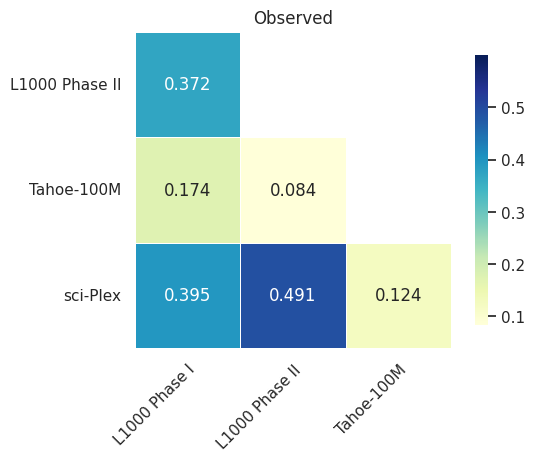

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_mean_observed_deg_lfc_spearman_sym_p05_heatmap.pdf


In [16]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_observed_deg_lfc_spearman_sym_p05",
    title="Observed",
    cmap="YlGnBu",
    output_path=DEG_HEATMAP_OUTPUT_PATHS["mean_observed_deg_lfc_spearman_sym_p05"],
    dataset_order=heatmap_dataset_order,
    vmin=lfc_vmin,
    vmax=lfc_vmax,
    cbar_label="Mean observed DEG logFC Spearman",
)


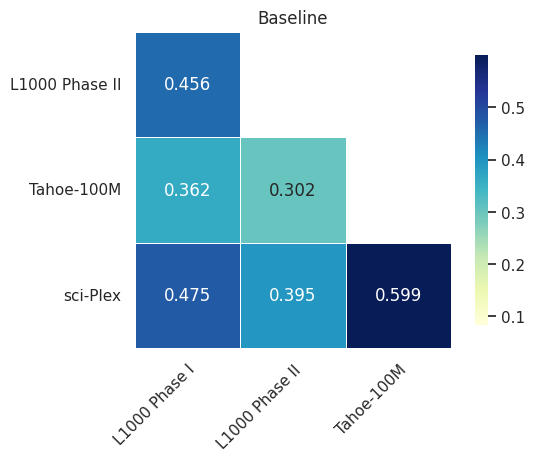

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_mean_baseline_pair_deg_lfc_spearman_p05_heatmap.pdf


In [17]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_baseline_pair_deg_lfc_spearman_p05",
    title="Baseline",
    cmap="YlGnBu",
    output_path=DEG_HEATMAP_OUTPUT_PATHS["mean_baseline_pair_deg_lfc_spearman_p05"],
    dataset_order=heatmap_dataset_order,
    vmin=lfc_vmin,
    vmax=lfc_vmax,
    cbar_label="Mean baseline pair DEG logFC Spearman",
)


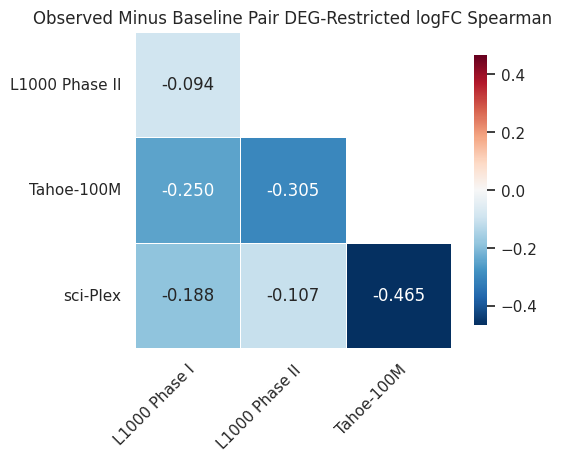

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_mean_delta_vs_baseline_pair_deg_lfc_spearman_p05_heatmap.pdf


In [18]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_delta_vs_baseline_pair_deg_lfc_spearman_p05",
    title="Observed Minus Baseline Pair DEG-Restricted logFC Spearman",
    cmap="RdBu_r",
    output_path=DEG_HEATMAP_OUTPUT_PATHS["mean_delta_vs_baseline_pair_deg_lfc_spearman_p05"],
    dataset_order=heatmap_dataset_order,
    vmin=None if lfc_delta_abs_max is None else -lfc_delta_abs_max,
    vmax=None if lfc_delta_abs_max is None else lfc_delta_abs_max,
    center=0.0,
    cbar_label="Mean delta DEG logFC Spearman",
)


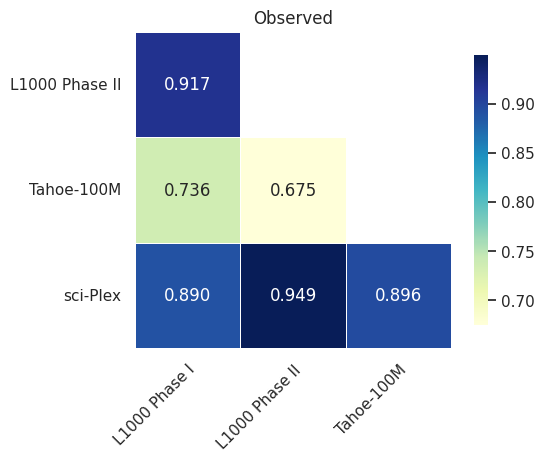

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_mean_observed_direction_agreement_p05_heatmap.pdf


In [19]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_observed_direction_agreement_p05",
    title="Observed",
    cmap="YlGnBu",
    output_path=DEG_HEATMAP_OUTPUT_PATHS["mean_observed_direction_agreement_p05"],
    dataset_order=heatmap_dataset_order,
    vmin=dir_vmin,
    vmax=dir_vmax,
    cbar_label="Mean observed direction agreement",
)


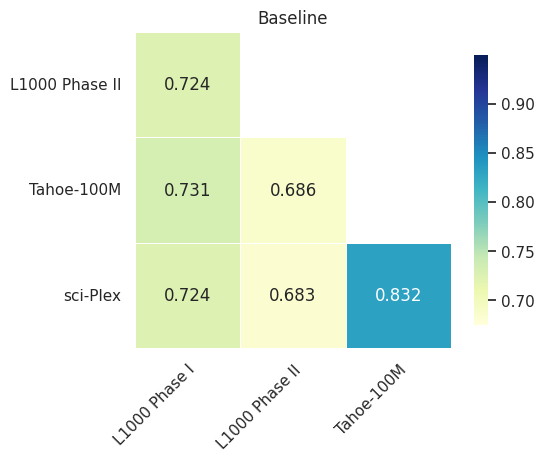

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_mean_baseline_pair_direction_agreement_p05_heatmap.pdf


In [20]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_baseline_pair_direction_agreement_p05",
    title="Baseline",
    cmap="YlGnBu",
    output_path=DEG_HEATMAP_OUTPUT_PATHS["mean_baseline_pair_direction_agreement_p05"],
    dataset_order=heatmap_dataset_order,
    vmin=dir_vmin,
    vmax=dir_vmax,
    cbar_label="Mean baseline pair direction agreement",
)


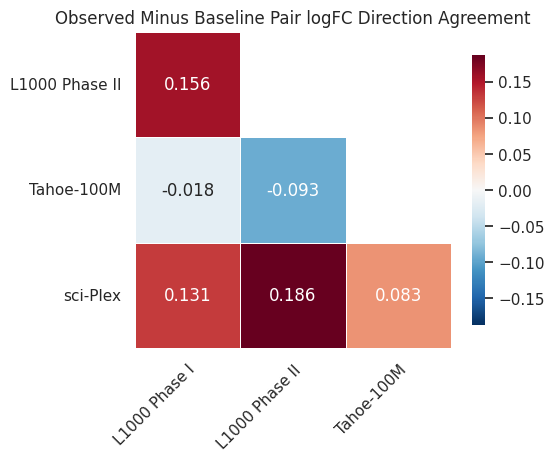

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_mean_delta_vs_baseline_pair_direction_agreement_p05_heatmap.pdf


In [21]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_delta_vs_baseline_pair_direction_agreement_p05",
    title="Observed Minus Baseline Pair logFC Direction Agreement",
    cmap="RdBu_r",
    output_path=DEG_HEATMAP_OUTPUT_PATHS["mean_delta_vs_baseline_pair_direction_agreement_p05"],
    dataset_order=heatmap_dataset_order,
    vmin=None if dir_delta_abs_max is None else -dir_delta_abs_max,
    vmax=None if dir_delta_abs_max is None else dir_delta_abs_max,
    center=0.0,
    cbar_label="Mean delta direction agreement",
)


## Dose-threshold sensitivity: exact, 2×, and 3×

The primary analysis above retains the original inclusive 10-fold dose window. This sensitivity analysis tightens that same mutual-nearest-neighbor match set to exact dose equality, inclusive 2-fold, and inclusive 3-fold windows, with 10-fold retained as the parity reference.

For every threshold, the `cell_type + time_key` eligibility rule is recomputed and still requires at least `MIN_CONTEXT_SHARED_DRUGS` shared compounds. The metric hierarchy is unchanged: matched dose pairs are averaged within `drug + line + time`, followed by dataset-pair and dataset-pair-line summaries.

The focused outputs report the primary `adj.P.Value < 0.05` DEG-restricted logFC Spearman and direction-agreement metrics, including the original centroid baseline and observed-minus-baseline delta.


In [22]:
DOSE_THRESHOLD_SPECS = [
    {
        "dose_threshold": "exact",
        "threshold_order": 0,
        "max_fold_difference": 1.0,
        "max_abs_delta_log10_dose": 0.0,
        "is_reference": False,
    },
    {
        "dose_threshold": "2x",
        "threshold_order": 1,
        "max_fold_difference": 2.0,
        "max_abs_delta_log10_dose": float(np.log10(2.0)),
        "is_reference": False,
    },
    {
        "dose_threshold": "3x",
        "threshold_order": 2,
        "max_fold_difference": 3.0,
        "max_abs_delta_log10_dose": float(np.log10(3.0)),
        "is_reference": False,
    },
    {
        "dose_threshold": "10x_reference",
        "threshold_order": 3,
        "max_fold_difference": 10.0,
        "max_abs_delta_log10_dose": float(np.log10(10.0)),
        "is_reference": True,
    },
]
DOSE_SENSITIVITY_CONTEXT_COLUMNS = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
]
DOSE_SENSITIVITY_PRIMARY_COLUMNS = [
    "observed_deg_lfc_spearman_sym_p05",
    "baseline_pair_deg_lfc_spearman_p05",
    "delta_vs_baseline_pair_deg_lfc_spearman_p05",
    "observed_direction_agreement_p05",
    "baseline_pair_direction_agreement_p05",
    "delta_vs_baseline_pair_direction_agreement_p05",
]


def qualify_pairs_for_dose_threshold(
    pair_frame: pd.DataFrame,
    max_abs_delta_log10_dose: float,
) -> pd.DataFrame:
    candidates = pair_frame.loc[
        pd.to_numeric(pair_frame["abs_delta_log10_dose"], errors="coerce")
        <= float(max_abs_delta_log10_dose) + 1e-12
    ].copy()
    candidates = candidates.drop(columns=["n_context_matching_drugs"], errors="ignore")
    if candidates.empty:
        return candidates

    context_counts = (
        candidates.groupby(DOSE_SENSITIVITY_CONTEXT_COLUMNS, as_index=False)
        .agg(n_context_matching_drugs=("pubchem_cid", "nunique"))
    )
    eligible_contexts = context_counts.loc[
        context_counts["n_context_matching_drugs"] >= int(MIN_CONTEXT_SHARED_DRUGS)
    ].copy()
    if eligible_contexts.empty:
        return candidates.iloc[0:0].copy()
    return candidates.merge(
        eligible_contexts,
        on=DOSE_SENSITIVITY_CONTEXT_COLUMNS,
        how="inner",
        validate="many_to_one",
    )


def dose_threshold_coverage(
    qualified_pairs: pd.DataFrame,
    scored_metrics: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    pair_keys = ["dataset_a", "dataset_b"]
    line_keys = [*pair_keys, "cell_type"]
    if qualified_pairs.empty:
        return pd.DataFrame(columns=pair_keys), pd.DataFrame(columns=line_keys)

    pair_coverage = (
        qualified_pairs.groupby(pair_keys, as_index=False)
        .agg(
            n_matched_sample_pairs=("left_obs_id", "size"),
            n_matching_conditions=("matched_condition_key", "nunique"),
            n_matching_drugs=("pubchem_cid", "nunique"),
            n_matching_lines=("cell_type", "nunique"),
        )
    )
    pair_context_counts = (
        qualified_pairs[DOSE_SENSITIVITY_CONTEXT_COLUMNS]
        .drop_duplicates()
        .groupby(pair_keys, as_index=False)
        .size()
        .rename(columns={"size": "n_eligible_contexts"})
    )
    pair_coverage = pair_coverage.merge(pair_context_counts, on=pair_keys, how="left")

    line_coverage = (
        qualified_pairs.groupby(line_keys, as_index=False)
        .agg(
            n_matched_sample_pairs=("left_obs_id", "size"),
            n_matching_conditions=("matched_condition_key", "nunique"),
            n_matching_drugs=("pubchem_cid", "nunique"),
        )
    )
    line_context_counts = (
        qualified_pairs[DOSE_SENSITIVITY_CONTEXT_COLUMNS]
        .drop_duplicates()
        .groupby(line_keys, as_index=False)
        .size()
        .rename(columns={"size": "n_eligible_contexts"})
    )
    line_coverage = line_coverage.merge(line_context_counts, on=line_keys, how="left")

    if scored_metrics.empty:
        pair_coverage["n_scored_sample_pairs"] = 0
        line_coverage["n_scored_sample_pairs"] = 0
    else:
        pair_scored = (
            scored_metrics.groupby(pair_keys, as_index=False)
            .size()
            .rename(columns={"size": "n_scored_sample_pairs"})
        )
        line_scored = (
            scored_metrics.groupby(line_keys, as_index=False)
            .size()
            .rename(columns={"size": "n_scored_sample_pairs"})
        )
        pair_coverage = pair_coverage.merge(pair_scored, on=pair_keys, how="left")
        line_coverage = line_coverage.merge(line_scored, on=line_keys, how="left")
        pair_coverage["n_scored_sample_pairs"] = pair_coverage["n_scored_sample_pairs"].fillna(0).astype(int)
        line_coverage["n_scored_sample_pairs"] = line_coverage["n_scored_sample_pairs"].fillna(0).astype(int)
    return pair_coverage, line_coverage


def aggregate_primary_dose_metrics(
    scored_metrics: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if scored_metrics.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    drug_agg: dict[str, tuple[str, str]] = {
        "n_scored_sample_pairs": ("left_obs_id", "size"),
        "n_matching_conditions_scored": ("matched_condition_key", "nunique"),
    }
    for column_name in DOSE_SENSITIVITY_PRIMARY_COLUMNS:
        drug_agg[f"mean_{column_name}"] = (column_name, "mean")

    drug_summary = (
        scored_metrics.groupby(drug_line_time_group_columns, as_index=False)
        .agg(**drug_agg)
        .sort_values(drug_line_time_group_columns)
        .reset_index(drop=True)
    )
    mean_columns = [
        column_name
        for column_name in drug_summary.columns
        if column_name.startswith("mean_")
    ]

    pair_agg: dict[str, tuple[str, str]] = {
        "n_scored_sample_pairs": ("n_scored_sample_pairs", "sum"),
        "n_scored_drug_line_times": ("pubchem_cid", "size"),
    }
    line_agg: dict[str, tuple[str, str]] = {
        "n_scored_sample_pairs": ("n_scored_sample_pairs", "sum"),
        "n_scored_drug_line_times": ("pubchem_cid", "size"),
    }
    for column_name in mean_columns:
        pair_agg[column_name] = (column_name, "mean")
        line_agg[column_name] = (column_name, "mean")

    pair_summary = (
        drug_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
        .agg(**pair_agg)
        .sort_values(["dataset_a", "dataset_b"])
        .reset_index(drop=True)
    )
    line_summary = (
        drug_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
        .agg(**line_agg)
        .sort_values(["dataset_a", "dataset_b", "cell_type"])
        .reset_index(drop=True)
    )
    return drug_summary, pair_summary, line_summary


dose_threshold_pair_frames: list[pd.DataFrame] = []
dose_threshold_line_frames: list[pd.DataFrame] = []
dose_threshold_drug_summaries: dict[str, pd.DataFrame] = {}
dose_threshold_qualified_pairs: dict[str, pd.DataFrame] = {}

for threshold_spec in DOSE_THRESHOLD_SPECS:
    threshold_label = str(threshold_spec["dose_threshold"])
    qualified_pairs = qualify_pairs_for_dose_threshold(
        matched_pairs,
        float(threshold_spec["max_abs_delta_log10_dose"]),
    )
    eligible_contexts = qualified_pairs[DOSE_SENSITIVITY_CONTEXT_COLUMNS].drop_duplicates()
    threshold_metrics = matched_pair_metrics.loc[
        pd.to_numeric(matched_pair_metrics["abs_delta_log10_dose"], errors="coerce")
        <= float(threshold_spec["max_abs_delta_log10_dose"]) + 1e-12
    ].copy()
    threshold_metrics = threshold_metrics.drop(columns=["n_context_matching_drugs"], errors="ignore")
    if not eligible_contexts.empty:
        threshold_metrics = threshold_metrics.merge(
            eligible_contexts,
            on=DOSE_SENSITIVITY_CONTEXT_COLUMNS,
            how="inner",
            validate="many_to_one",
        )
    else:
        threshold_metrics = threshold_metrics.iloc[0:0].copy()

    drug_summary, metric_pair_summary, metric_line_summary = aggregate_primary_dose_metrics(threshold_metrics)
    pair_coverage, line_coverage = dose_threshold_coverage(qualified_pairs, threshold_metrics)
    pair_keys = ["dataset_a", "dataset_b"]
    line_keys = [*pair_keys, "cell_type"]
    if metric_pair_summary.empty:
        pair_summary = pair_coverage.copy()
    else:
        pair_summary = pair_coverage.merge(
            metric_pair_summary.drop(columns=["n_scored_sample_pairs"], errors="ignore"),
            on=pair_keys,
            how="left",
            validate="one_to_one",
        )
    if metric_line_summary.empty:
        line_summary = line_coverage.copy()
    else:
        line_summary = line_coverage.merge(
            metric_line_summary.drop(columns=["n_scored_sample_pairs"], errors="ignore"),
            on=line_keys,
            how="left",
            validate="one_to_one",
        )

    for frame in [pair_summary, line_summary, drug_summary]:
        frame.insert(0, "is_reference", bool(threshold_spec["is_reference"]))
        frame.insert(0, "max_abs_delta_log10_dose", float(threshold_spec["max_abs_delta_log10_dose"]))
        frame.insert(0, "max_fold_difference", float(threshold_spec["max_fold_difference"]))
        frame.insert(0, "threshold_order", int(threshold_spec["threshold_order"]))
        frame.insert(0, "dose_threshold", threshold_label)

    dose_threshold_pair_frames.append(pair_summary)
    dose_threshold_line_frames.append(line_summary)
    dose_threshold_drug_summaries[threshold_label] = drug_summary
    dose_threshold_qualified_pairs[threshold_label] = qualified_pairs

dose_threshold_pair_summary = pd.concat(dose_threshold_pair_frames, ignore_index=True)
dose_threshold_line_summary = pd.concat(dose_threshold_line_frames, ignore_index=True)
dose_threshold_pair_summary = dose_threshold_pair_summary.sort_values(
    ["threshold_order", "dataset_a", "dataset_b"]
).reset_index(drop=True)
dose_threshold_line_summary = dose_threshold_line_summary.sort_values(
    ["threshold_order", "dataset_a", "dataset_b", "cell_type"]
).reset_index(drop=True)

dose_threshold_pair_summary_path = OUTPUT_DIR / "dose_threshold_deg_metric_summary.tsv"
dose_threshold_line_summary_path = OUTPUT_DIR / "dose_threshold_deg_metric_line_summary.tsv"
dose_threshold_pair_summary.to_csv(dose_threshold_pair_summary_path, sep="\t", index=False)
dose_threshold_line_summary.to_csv(dose_threshold_line_summary_path, sep="\t", index=False)
print(f"Saved dose-threshold dataset-pair summary to {dose_threshold_pair_summary_path}")
print(f"Saved dose-threshold dataset-pair-line summary to {dose_threshold_line_summary_path}")

dose_mismatch_pairs = matched_pairs.copy()
dose_mismatch_pairs["dose_fold_difference"] = np.power(
    10.0,
    pd.to_numeric(dose_mismatch_pairs["abs_delta_log10_dose"], errors="coerce"),
)
dose_mismatch_conditions = dose_mismatch_pairs.drop_duplicates(
    ["dataset_a", "dataset_b", "matched_condition_key"]
).copy()


def dose_mismatch_quantiles(frame: pd.DataFrame, unit: str) -> pd.DataFrame:
    summary = (
        frame.groupby(["dataset_a", "dataset_b"], as_index=False)
        .agg(
            n=("dose_fold_difference", "size"),
            min_fold_difference=("dose_fold_difference", "min"),
            q25_fold_difference=("dose_fold_difference", lambda values: values.quantile(0.25)),
            median_fold_difference=("dose_fold_difference", "median"),
            q75_fold_difference=("dose_fold_difference", lambda values: values.quantile(0.75)),
            q90_fold_difference=("dose_fold_difference", lambda values: values.quantile(0.90)),
            q95_fold_difference=("dose_fold_difference", lambda values: values.quantile(0.95)),
            max_fold_difference=("dose_fold_difference", "max"),
        )
    )
    summary.insert(0, "unit", unit)
    return summary


dose_mismatch_distribution = pd.concat(
    [
        dose_mismatch_quantiles(dose_mismatch_pairs, "matched_sample_pair"),
        dose_mismatch_quantiles(dose_mismatch_conditions, "unique_matched_condition"),
    ],
    ignore_index=True,
)
dose_mismatch_distribution_path = OUTPUT_DIR / "dose_mismatch_distribution.tsv"
dose_mismatch_distribution.to_csv(dose_mismatch_distribution_path, sep="\t", index=False)
print(f"Saved dose-mismatch distribution summary to {dose_mismatch_distribution_path}")

dose_sensitivity_ci_metrics = {
    column_name: f"mean_{column_name}"
    for column_name in DOSE_SENSITIVITY_PRIMARY_COLUMNS
}
dose_threshold_deg_cluster_bca_ci_path = OUTPUT_DIR / "dose_threshold_deg_cluster_bca_ci.tsv"
DOSE_CI_FINGERPRINT = "dose-ci-v2|exact,2x,3x,10x"
dose_ci_is_cached = is_cached(
    "dose_ci",
    dose_threshold_deg_cluster_bca_ci_path,
    fingerprint=DOSE_CI_FINGERPRINT,
)
dose_threshold_ci_frames: list[pd.DataFrame] = []
for threshold_spec in ([] if dose_ci_is_cached else DOSE_THRESHOLD_SPECS):
    threshold_label = str(threshold_spec["dose_threshold"])
    drug_summary = dose_threshold_drug_summaries[threshold_label]
    if drug_summary.empty:
        continue
    ci_frame = pd.concat(
        [
            cluster_bca_nested_mean_ci_table(
                drug_summary,
                group_cols=["dataset_a", "dataset_b"],
                metric_cols=dose_sensitivity_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dose_threshold_dataset_pair",
            ),
            cluster_bca_nested_mean_ci_table(
                drug_summary,
                group_cols=["dataset_a", "dataset_b", "cell_type"],
                metric_cols=dose_sensitivity_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dose_threshold_dataset_pair_line",
            ),
        ],
        ignore_index=True,
    )
    ci_frame.insert(0, "is_reference", bool(threshold_spec["is_reference"]))
    ci_frame.insert(0, "max_abs_delta_log10_dose", float(threshold_spec["max_abs_delta_log10_dose"]))
    ci_frame.insert(0, "max_fold_difference", float(threshold_spec["max_fold_difference"]))
    ci_frame.insert(0, "threshold_order", int(threshold_spec["threshold_order"]))
    ci_frame.insert(0, "dose_threshold", threshold_label)
    dose_threshold_ci_frames.append(ci_frame)

dose_threshold_deg_cluster_bca_ci = cached_frame(
    "dose_ci",
    dose_threshold_deg_cluster_bca_ci_path,
    lambda: pd.concat(dose_threshold_ci_frames, ignore_index=True),
    fingerprint=DOSE_CI_FINGERPRINT,
    required_columns=["dose_threshold", "metric", "mean", "ci_low", "ci_high"],
)
print(f"Saved dose-threshold cluster-BCa CIs to {dose_threshold_deg_cluster_bca_ci_path}")

coverage_totals_observed = (
    dose_threshold_pair_summary.groupby(
        ["threshold_order", "dose_threshold"],
        as_index=False,
    )["n_matched_sample_pairs"]
    .sum()
    .sort_values("threshold_order")
)
coverage_totals = pd.DataFrame(DOSE_THRESHOLD_SPECS)[
    ["threshold_order", "dose_threshold", "max_fold_difference"]
].merge(
    coverage_totals_observed,
    on=["threshold_order", "dose_threshold"],
    how="left",
    validate="one_to_one",
)
coverage_totals["n_matched_sample_pairs"] = coverage_totals["n_matched_sample_pairs"].fillna(0).astype(int)
coverage_totals_path = OUTPUT_DIR / "dose_threshold_overall_matched_pair_counts.tsv"
coverage_totals.to_csv(coverage_totals_path, sep="\t", index=False)
print(f"Saved exact/2x/3x/reference matched-pair counts to {coverage_totals_path}")
if np.any(np.diff(coverage_totals["n_matched_sample_pairs"].to_numpy(dtype=float)) < 0):
    raise AssertionError("Dose-threshold coverage is not nested: expected exact <= 2x <= 3x <= 10x.")

reference_summary = dose_threshold_pair_summary.loc[
    dose_threshold_pair_summary["dose_threshold"] == "10x_reference"
].copy()
parity_columns = [f"mean_{column_name}" for column_name in DOSE_SENSITIVITY_PRIMARY_COLUMNS]
parity_check = reference_summary.merge(
    pair_metric_summary[["dataset_a", "dataset_b", *parity_columns]],
    on=["dataset_a", "dataset_b"],
    suffixes=("_sensitivity", "_original"),
    how="inner",
    validate="one_to_one",
)
for column_name in parity_columns:
    if not np.allclose(
        parity_check[f"{column_name}_sensitivity"].to_numpy(dtype=float),
        parity_check[f"{column_name}_original"].to_numpy(dtype=float),
        equal_nan=True,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise AssertionError(f"10x reference does not reproduce the original summary for {column_name}.")
print("Dose-threshold checks passed: coverage is nested and the 10x primary metrics reproduce the original summary.")
display(coverage_totals)
display(
    dose_threshold_pair_summary[
        [
            "dose_threshold",
            "dataset_a",
            "dataset_b",
            "n_matched_sample_pairs",
            "n_scored_sample_pairs",
            "n_matching_conditions",
            "n_matching_drugs",
            "n_eligible_contexts",
            "mean_observed_deg_lfc_spearman_sym_p05",
            "mean_baseline_pair_deg_lfc_spearman_p05",
            "mean_delta_vs_baseline_pair_deg_lfc_spearman_p05",
            "mean_observed_direction_agreement_p05",
            "mean_baseline_pair_direction_agreement_p05",
            "mean_delta_vs_baseline_pair_direction_agreement_p05",
        ]
    ]
)

Saved dose-threshold dataset-pair summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dose_threshold_deg_metric_summary.tsv
Saved dose-threshold dataset-pair-line summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dose_threshold_deg_metric_line_summary.tsv
Saved dose-mismatch distribution summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dose_mismatch_distribution.tsv
[dose_ci] reloaded 690 rows from dose_threshold_deg_cluster_bca_ci.tsv
Saved dose-threshold cluster-BCa CIs to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_pha

,threshold_order,dose_threshold,max_fold_difference,n_matched_sample_pairs
0,0,exact,1.0,32315
1,1,2x,2.0,57855
2,2,3x,3.0,57892
3,3,10x_reference,10.0,58835


,dose_threshold,dataset_a,dataset_b,n_matched_sample_pairs,n_scored_sample_pairs,n_matching_conditions,n_matching_drugs,n_eligible_contexts,mean_observed_deg_lfc_spearman_sym_p05,mean_baseline_pair_deg_lfc_spearman_p05,mean_delta_vs_baseline_pair_deg_lfc_spearman_p05,mean_observed_direction_agreement_p05,mean_baseline_pair_direction_agreement_p05,mean_delta_vs_baseline_pair_direction_agreement_p05
0,exact,l1000_phase1,l1000_phase2,29250,29250,972,237,16,0.477700,0.517074,-0.052588,0.928945,0.752434,0.151819
1,exact,l1000_phase1,sciplex,1918,1888,163,90,2,0.428451,0.494429,-0.174389,0.899016,0.729403,0.130089
2,exact,l1000_phase2,sciplex,1147,1118,127,83,2,0.537753,0.533317,-0.115185,0.949405,0.711710,0.183599
3,2x,l1000_phase1,l1000_phase2,49733,49733,2791,246,16,0.373311,0.458761,-0.094893,0.919834,0.725163,0.157682
4,2x,l1000_phase1,sciplex,2689,2647,290,90,2,0.395138,0.476336,-0.188346,0.888200,0.723690,0.129353
5,2x,l1000_phase1,tahoe,600,600,149,86,3,0.174154,0.361242,-0.249997,0.735568,0.729336,-0.017596
6,2x,l1000_phase2,sciplex,3192,3133,381,83,2,0.490837,0.394572,-0.107045,0.949214,0.682605,0.186244
7,2x,l1000_phase2,tahoe,1471,1471,401,110,2,0.084246,0.301614,-0.305352,0.674808,0.686213,-0.093075
8,2x,tahoe,sciplex,170,170,69,23,1,0.123839,0.599337,-0.465489,0.895718,0.831651,0.083215
9,3x,l1000_phase1,l1000_phase2,49768,49768,2795,248,16,0.371758,0.457759,-0.095352,0.918953,0.725110,0.156740


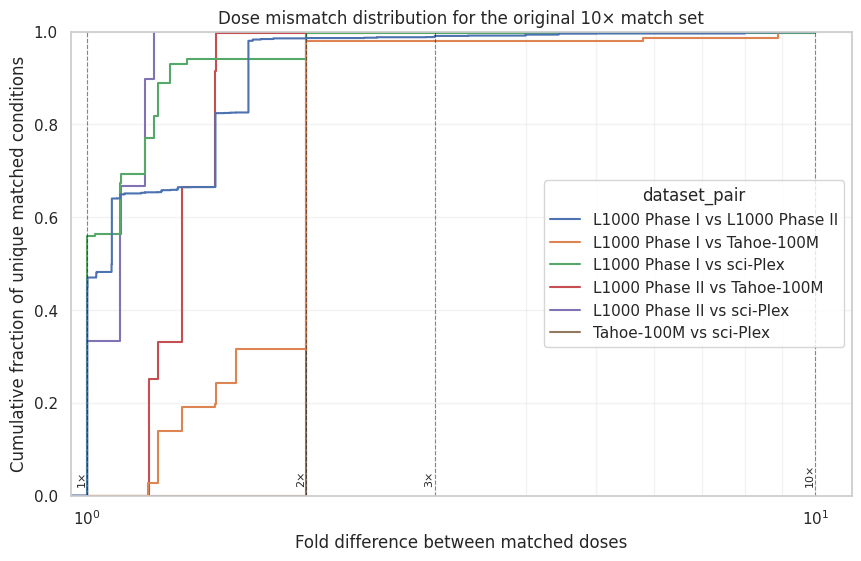

Saved dose-mismatch ECDF to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dose_mismatch_fold_difference_ecdf.pdf


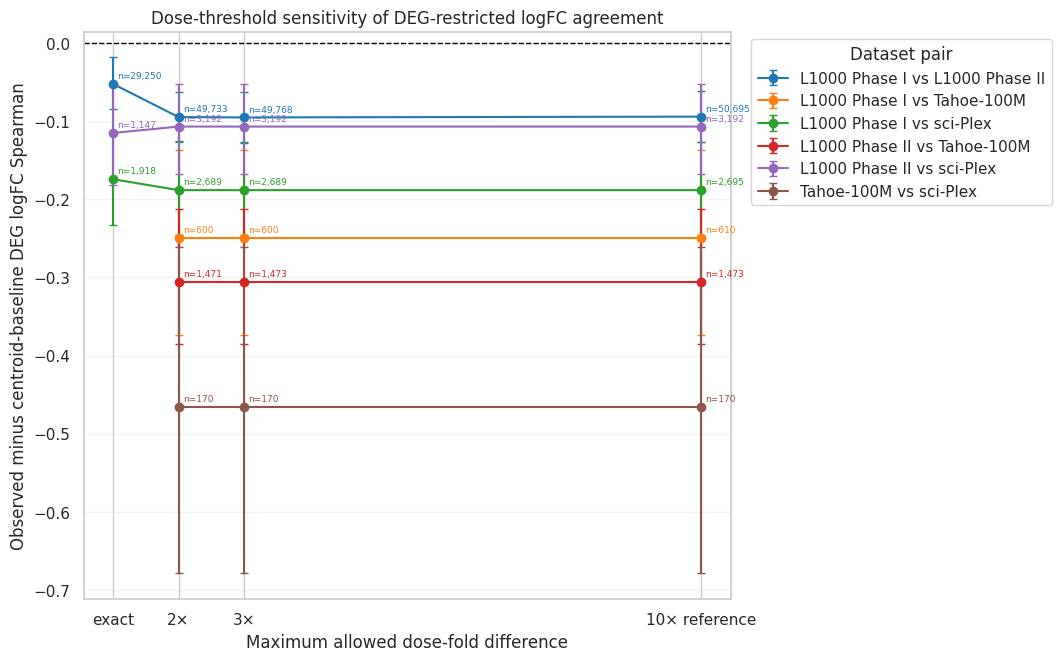

Saved dose-threshold delta plot to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dose_threshold_deg_lfc_spearman_delta.pdf


In [23]:
dose_mismatch_ecdf_path = OUTPUT_DIR / "dose_mismatch_fold_difference_ecdf.pdf"
dose_condition_plot = dose_mismatch_conditions.copy()
dose_condition_plot["dataset_pair"] = (
    dose_condition_plot["dataset_a"].map(pretty_label)
    + " vs "
    + dose_condition_plot["dataset_b"].map(pretty_label)
)
fig, ax = plt.subplots(figsize=(8.5, 5.5), constrained_layout=True)
sns.ecdfplot(
    data=dose_condition_plot,
    x="dose_fold_difference",
    hue="dataset_pair",
    ax=ax,
)
for fold_difference in [1.0, 2.0, 3.0, 10.0]:
    ax.axvline(fold_difference, color="black", linestyle="--", linewidth=0.8, alpha=0.45)
    ax.text(
        fold_difference,
        0.02,
        f"{format_numeric(fold_difference)}×",
        rotation=90,
        ha="right",
        va="bottom",
        fontsize=8,
    )
ax.set_xscale("log")
ax.set_xlim(left=max(0.95, float(dose_condition_plot["dose_fold_difference"].min()) * 0.95))
ax.set_xlabel("Fold difference between matched doses")
ax.set_ylabel("Cumulative fraction of unique matched conditions")
ax.set_title("Dose mismatch distribution for the original 10× match set")
ax.grid(True, which="both", alpha=0.25)
fig.savefig(dose_mismatch_ecdf_path, bbox_inches="tight")
plt.show()
print(f"Saved dose-mismatch ECDF to {dose_mismatch_ecdf_path}")

dose_delta_plot_path = OUTPUT_DIR / "dose_threshold_deg_lfc_spearman_delta.pdf"
dose_delta_ci = dose_threshold_deg_cluster_bca_ci.loc[
    (dose_threshold_deg_cluster_bca_ci["summary_level"] == "dose_threshold_dataset_pair")
    & (
        dose_threshold_deg_cluster_bca_ci["metric"]
        == "delta_vs_baseline_pair_deg_lfc_spearman_p05"
    )
].copy()
dose_delta_ci = dose_delta_ci.merge(
    dose_threshold_pair_summary[
        [
            "dose_threshold",
            "dataset_a",
            "dataset_b",
            "n_matched_sample_pairs",
        ]
    ],
    on=["dose_threshold", "dataset_a", "dataset_b"],
    how="left",
    validate="one_to_one",
)
dose_delta_ci["dataset_pair"] = (
    dose_delta_ci["dataset_a"].map(pretty_label)
    + " vs "
    + dose_delta_ci["dataset_b"].map(pretty_label)
)

fig, ax = plt.subplots(figsize=(10.5, 6.5), constrained_layout=True)
palette = sns.color_palette("tab10", n_colors=max(1, dose_delta_ci["dataset_pair"].nunique()))
for color, (dataset_pair, group) in zip(
    palette,
    dose_delta_ci.groupby("dataset_pair", sort=True),
):
    group = group.sort_values("threshold_order")
    x_values = group["max_fold_difference"].to_numpy(dtype=float)
    mean_values = group["mean"].to_numpy(dtype=float)
    lower_errors = mean_values - group["ci_low"].to_numpy(dtype=float)
    upper_errors = group["ci_high"].to_numpy(dtype=float) - mean_values
    ax.errorbar(
        x_values,
        mean_values,
        yerr=np.vstack([lower_errors, upper_errors]),
        marker="o",
        linewidth=1.5,
        capsize=3,
        color=color,
        label=dataset_pair,
    )
    for x_value, mean_value, n_pairs in zip(
        x_values,
        mean_values,
        group["n_matched_sample_pairs"].to_numpy(dtype=int),
    ):
        ax.annotate(
            f"n={n_pairs:,}",
            (x_value, mean_value),
            xytext=(3, 4),
            textcoords="offset points",
            fontsize=6.5,
            color=color,
        )
ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
ax.set_xticks([1.0, 2.0, 3.0, 10.0], labels=["exact", "2×", "3×", "10× reference"])
ax.set_xlabel("Maximum allowed dose-fold difference")
ax.set_ylabel("Observed minus centroid-baseline DEG logFC Spearman")
ax.set_title("Dose-threshold sensitivity of DEG-restricted logFC agreement")
ax.legend(title="Dataset pair", bbox_to_anchor=(1.02, 1.0), loc="upper left")
ax.grid(True, axis="y", alpha=0.25)
fig.savefig(dose_delta_plot_path, bbox_inches="tight")
plt.show()
print(f"Saved dose-threshold delta plot to {dose_delta_plot_path}")


## Per-peer and target-side baselines for the DEG agreement tables

Reviewer W1 argues that the published baseline -- the gene-wise mean over same-context
different-compound peers -- is an unfairly strong competitor for three reasons: averaging
removes variance (smoothing), the baseline term is computed entirely within the sample's
own dataset while the observed term crosses assays (home-field advantage), and the
common-mode response shared by most compounds survives averaging.

This section leaves every result above unchanged and rescores the same matched sample
pairs against four baselines, which separate those mechanisms:

- `source_centroid`: the published baseline, recomputed here as a parity check.
- `target_centroid`: the same gene-wise mean built from the *other* dataset's peers, so
  the baseline pays the same cross-assay penalty as the observed score.
- `source_peer`: every own-dataset peer scored separately, then summarized. Removes
  smoothing and the common-mode advantage; retains home-field.
- `target_peer`: every other-dataset peer scored separately. Removes all three.

For the per-peer baselines we report the mean and standard deviation of the peer score
distribution, the fraction of peer scores `m(i, x)` below the observed matched score
`m(i, j)`, and the add-one corrected percentile `(1 + #{m(i, x) < m(i, j)}) / (K + 1)`.

Metrics follow the published sample-referenced convention: DEG-restricted logFC Spearman
is evaluated on the sample's own DEG mask, and direction agreement on that mask
intersected with the finite entries of the comparison signature. The peer set is
identical to the one `LineSource.get_baseline_vector` averages, which the parity cell
asserts explicitly.

In [24]:
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.peer_baselines import (
    PEER_SUMMARY_FIELDS,
    direction_agreement_against_peers,
    empty_peer_score_summary,
    select_peer_indices,
    spearman_against_peers,
    summarize_peer_scores,
)

# Tables 4 and 5 report the adj.P.Value < 0.05 definition; add "p05_lfc02" to also cover
# the |logFC| > 0.2 variant at roughly double the peer-scoring cost.
PEER_BASELINE_DEFINITION_KEYS = ("p05",)
PEER_BASELINE_METRICS = ("deg_lfc_spearman", "direction_agreement")
PEER_BASELINE_VARIANTS = (
    "source_centroid",
    "target_centroid",
    "source_peer",
    "target_peer",
)
# Cap individual-peer scoring only; the source/target centroids remain exact and use all
# eligible peers. Sampling is deterministic and recorded in the output configuration.
MAX_BASELINE_PEERS: Optional[int] = 512
PEER_SAMPLING_SEED = 20260505
PEER_STRATUM_CACHE: dict[tuple, tuple[np.ndarray, np.ndarray]] = {}
PEER_STRATUM_CACHE_LIMIT = 4


def baseline_peer_stratum(
    source: LineSource,
    *,
    dose_key: str,
    time_key: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Load one line/dose/time stratum's logFC matrix and compound labels, once.

    A sample's peer set is this stratum minus its own compound, so every query in the
    stratum shares the same underlying matrix. Caching per stratum rather than per query
    turns thousands of reads of the same rows into one.
    """
    cache_key = (source.dataset_name, source.cell_type, str(dose_key), str(time_key))
    if cache_key in PEER_STRATUM_CACHE:
        return PEER_STRATUM_CACHE[cache_key]

    stratum_obs = source.obs.loc[
        (source.obs["dose_key"].astype(str) == str(dose_key))
        & (source.obs["time_key"].astype(str) == str(time_key))
    ]
    stratum_rows = stratum_obs["source_row_pos"].to_numpy(dtype=np.int64)
    compounds = stratum_obs["pubchem_cid"].astype(str).to_numpy(dtype=object)
    if stratum_rows.size == 0:
        matrix = np.empty((0, int(source.unique_gene_keys.size)), dtype=np.float32)
    else:
        raw = np.asarray(source.adata.layers["logFC"][stratum_rows], dtype=np.float32)
        if raw.ndim == 1:
            raw = raw[np.newaxis, :]
        matrix = raw[:, source.unique_gene_positions]

    if len(PEER_STRATUM_CACHE) >= PEER_STRATUM_CACHE_LIMIT:
        PEER_STRATUM_CACHE.pop(next(iter(PEER_STRATUM_CACHE)))
    PEER_STRATUM_CACHE[cache_key] = (compounds, matrix)
    return PEER_STRATUM_CACHE[cache_key]


def baseline_peer_logfc_matrix(
    source: LineSource,
    obs_id: str,
    *,
    pubchem_cid: str,
    dose_key: str,
    time_key: str,
) -> tuple[np.ndarray, int, int]:
    """Return the peer logFC matrix backing this sample's centroid baseline.

    The peer set is identical to the one `LineSource.get_baseline_vector` averages: same
    line file, same dose key, same time key, different `pubchem_cid`. Returns the matrix in
    unique-gene order with the total and retained peer counts, so a capped run records how
    many peers existed as well as how many were scored.

    `MAX_BASELINE_PEERS` is read at call time rather than bound as a default argument, so
    changing the cap and clearing `PEER_STRATUM_CACHE` is enough to rescore.
    """
    row_pos = source.resolve_row_pos(
        obs_id,
        pubchem_cid=pubchem_cid,
        dose_key=dose_key,
        time_key=time_key,
    )
    row = source.obs.loc[row_pos]
    compounds, stratum_matrix = baseline_peer_stratum(
        source,
        dose_key=str(row["dose_key"]),
        time_key=str(row["time_key"]),
    )

    peer_positions = np.flatnonzero(compounds != str(row["pubchem_cid"]))
    n_total_peers = int(peer_positions.size)
    if n_total_peers == 0:
        return np.empty((0, int(source.unique_gene_keys.size)), dtype=np.float32), 0, 0

    selected = select_peer_indices(
        n_total_peers,
        MAX_BASELINE_PEERS,
        "|".join(
            [
                source.dataset_name,
                source.cell_type,
                str(row["dose_key"]),
                str(row["time_key"]),
                str(row["pubchem_cid"]),
            ]
        ),
        sampling_seed=PEER_SAMPLING_SEED,
    )
    chosen = peer_positions[selected]
    return stratum_matrix[chosen], n_total_peers, int(chosen.size)


def peer_scores_for_metric(
    metric_name: str,
    sample_logfc: np.ndarray,
    peer_matrix: np.ndarray,
    sample_mask: np.ndarray,
) -> np.ndarray:
    if peer_matrix.shape[0] == 0:
        return np.empty(0, dtype=np.float64)
    if metric_name == "deg_lfc_spearman":
        return spearman_against_peers(sample_logfc, peer_matrix, sample_mask)
    if metric_name == "direction_agreement":
        return direction_agreement_against_peers(sample_logfc, peer_matrix, sample_mask)
    raise KeyError(f"Unsupported per-peer metric: {metric_name}")


def centroid_score_for_metric(
    metric_name: str,
    sample_logfc: np.ndarray,
    centroid_logfc: Optional[np.ndarray],
    sample_mask: np.ndarray,
) -> float:
    """Score a sample against a centroid using the published sample-referenced convention."""
    if centroid_logfc is None:
        return float("nan")
    if metric_name == "deg_lfc_spearman":
        return deg_restricted_spearman(sample_logfc, centroid_logfc, sample_mask)
    if metric_name == "direction_agreement":
        return direction_agreement_with_masks(
            sample_logfc,
            centroid_logfc,
            sample_mask,
            finite_values_mask(centroid_logfc),
        )
    raise KeyError(f"Unsupported centroid metric: {metric_name}")


def compute_peer_baseline_record(match_row: pd.Series) -> dict[str, object]:
    """Score one matched sample pair against all four baseline constructions.

    Baselines, following the reviewer's W1 decomposition:
      source_centroid -- the published baseline: mean of the sample's own-dataset peers.
      target_centroid -- the same mean built in the *other* dataset, which pays the same
                         cross-assay penalty as the observed score.
      source_peer     -- every own-dataset peer scored separately (removes smoothing,
                         keeps the within-dataset home-field advantage).
      target_peer     -- every other-dataset peer scored separately (removes both).
    """
    dataset_a = str(match_row["dataset_a"])
    dataset_b = str(match_row["dataset_b"])
    cell_type = str(match_row["cell_type"])
    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        raise ValueError(
            f"Fewer than two shared genes for {dataset_a} vs {dataset_b} / {cell_type}"
        )

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])
    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_adj_layer = get_adjusted_pvalue_layer(left_source)
    right_adj_layer = get_adjusted_pvalue_layer(right_source)
    left_logfc = left_source.get_vector(left_obs_id, "logFC", **left_lookup)[left_gene_pos]
    right_logfc = right_source.get_vector(right_obs_id, "logFC", **right_lookup)[right_gene_pos]
    left_adj_p = left_source.get_vector(left_obs_id, left_adj_layer, **left_lookup)[left_gene_pos]
    right_adj_p = right_source.get_vector(right_obs_id, right_adj_layer, **right_lookup)[right_gene_pos]

    left_centroid_full = left_source.get_baseline_vector(left_obs_id, "logFC", **left_lookup)
    right_centroid_full = right_source.get_baseline_vector(right_obs_id, "logFC", **right_lookup)
    left_centroid = None if left_centroid_full is None else np.asarray(left_centroid_full, dtype=np.float32)[left_gene_pos]
    right_centroid = None if right_centroid_full is None else np.asarray(right_centroid_full, dtype=np.float32)[right_gene_pos]

    left_peers_full, left_n_total_peers, left_n_scored_peers = baseline_peer_logfc_matrix(
        left_source,
        left_obs_id,
        **left_lookup,
    )
    right_peers_full, right_n_total_peers, right_n_scored_peers = baseline_peer_logfc_matrix(
        right_source,
        right_obs_id,
        **right_lookup,
    )
    left_peers = left_peers_full[:, left_gene_pos]
    right_peers = right_peers_full[:, right_gene_pos]

    # The peer set must be exactly the set the published centroid averaged. Comparing
    # counts checks that membership without recomputing the centroid mean per pair, and it
    # keeps working when MAX_BASELINE_PEERS caps how many peers are scored.
    for side, source, obs_id, lookup, n_total in (
        ("left", left_source, left_obs_id, left_lookup, left_n_total_peers),
        ("right", right_source, right_obs_id, right_lookup, right_n_total_peers),
    ):
        expected_peers = int(source.baseline_peer_count(obs_id, **lookup))
        if int(n_total) != expected_peers:
            raise AssertionError(
                f"Peer set does not match the published centroid for {side} side of "
                f"{dataset_a} vs {dataset_b} / {cell_type} / {pubchem_cid}: "
                f"{int(n_total)} peers vs {expected_peers} averaged by get_baseline_vector."
            )

    record: dict[str, object] = {
        **match_row.to_dict(),
        "n_common_genes": int(shared_genes.size),
        "left_peer_total_count": left_n_total_peers,
        "right_peer_total_count": right_n_total_peers,
        "left_peer_scored_count": left_n_scored_peers,
        "right_peer_scored_count": right_n_scored_peers,
        "peer_sampling_seed": PEER_SAMPLING_SEED,
        "max_baseline_peers": MAX_BASELINE_PEERS,
    }

    for definition_key in PEER_BASELINE_DEFINITION_KEYS:
        mask_left = deg_mask(left_logfc, left_adj_p, definition_key)
        mask_right = deg_mask(right_logfc, right_adj_p, definition_key)
        record[f"n_deg_left_{definition_key}"] = int(mask_left.sum())
        record[f"n_deg_right_{definition_key}"] = int(mask_right.sum())

        observed_left_ref = deg_restricted_spearman(left_logfc, right_logfc, mask_left)
        observed_right_ref = deg_restricted_spearman(left_logfc, right_logfc, mask_right)
        observed_by_metric_side = {
            ("deg_lfc_spearman", "left"): observed_left_ref,
            ("deg_lfc_spearman", "right"): observed_right_ref,
        }
        observed_by_metric = {
            "deg_lfc_spearman": strict_symmetric_mean(observed_left_ref, observed_right_ref),
            "direction_agreement": direction_agreement_with_masks(
                left_logfc,
                right_logfc,
                mask_left,
                mask_right,
            ),
        }
        # Direction agreement has no side-referenced observed term: the published
        # observed value is computed once on the DEG intersection, so both sides of the
        # peer distribution are compared against it.
        observed_by_metric_side[("direction_agreement", "left")] = observed_by_metric["direction_agreement"]
        observed_by_metric_side[("direction_agreement", "right")] = observed_by_metric["direction_agreement"]

        for metric_name in PEER_BASELINE_METRICS:
            record[f"pb_observed_{metric_name}_{definition_key}"] = observed_by_metric[metric_name]

            side_specs = {
                "left": {
                    "sample_logfc": left_logfc,
                    "sample_mask": mask_left,
                    "source_centroid": left_centroid,
                    "target_centroid": right_centroid,
                    "source_peers": left_peers,
                    "target_peers": right_peers,
                },
                "right": {
                    "sample_logfc": right_logfc,
                    "sample_mask": mask_right,
                    "source_centroid": right_centroid,
                    "target_centroid": left_centroid,
                    "source_peers": right_peers,
                    "target_peers": left_peers,
                },
            }

            for variant in PEER_BASELINE_VARIANTS:
                side_values: list[float] = []
                side_sds: list[float] = []
                side_fractions: list[float] = []
                side_percentiles: list[float] = []
                for side, spec in side_specs.items():
                    column_stem = f"pb_{variant}_{metric_name}_{side}_{definition_key}"
                    if variant.endswith("_centroid"):
                        value = centroid_score_for_metric(
                            metric_name,
                            spec["sample_logfc"],
                            spec[variant],
                            spec["sample_mask"],
                        )
                        record[column_stem] = value
                        side_values.append(value)
                        continue

                    peer_matrix = spec["source_peers" if variant == "source_peer" else "target_peers"]
                    observed_side = observed_by_metric_side[(metric_name, side)]
                    if peer_matrix.shape[0] == 0:
                        record.update(empty_peer_score_summary(column_stem))
                        side_values.append(float("nan"))
                        side_sds.append(float("nan"))
                        side_fractions.append(float("nan"))
                        side_percentiles.append(float("nan"))
                        continue
                    peer_scores = peer_scores_for_metric(
                        metric_name,
                        spec["sample_logfc"],
                        peer_matrix,
                        spec["sample_mask"],
                    )
                    summary = summarize_peer_scores(observed_side, peer_scores, column_stem)
                    record.update(summary)
                    side_values.append(summary[f"{column_stem}_mean_score"])
                    side_sds.append(summary[f"{column_stem}_sd_score"])
                    side_fractions.append(summary[f"{column_stem}_fraction_below_observed"])
                    side_percentiles.append(summary[f"{column_stem}_corrected_percentile"])

                pair_stem = f"pb_{variant}_{metric_name}_pair_{definition_key}"
                pair_value = mean_available(side_values)
                record[pair_stem] = pair_value
                record[f"pb_delta_vs_{variant}_{metric_name}_{definition_key}"] = difference_if_both_defined(
                    observed_by_metric[metric_name],
                    pair_value,
                )
                if not variant.endswith("_centroid"):
                    record[f"{pair_stem}_sd_score"] = mean_available(side_sds)
                    record[f"{pair_stem}_fraction_below_observed"] = mean_available(side_fractions)
                    record[f"{pair_stem}_corrected_percentile"] = mean_available(side_percentiles)

    return record


print(
    f"Per-peer baseline scoring configured for definitions={PEER_BASELINE_DEFINITION_KEYS}, "
    f"metrics={PEER_BASELINE_METRICS}, max_peers={MAX_BASELINE_PEERS}"
)

Per-peer baseline scoring configured for definitions=('p05',), metrics=('deg_lfc_spearman', 'direction_agreement'), max_peers=512


In [25]:
peer_baseline_unresolved: list[dict[str, object]] = []


def build_matched_pair_peer_baselines() -> pd.DataFrame:
    peer_baseline_records: list[dict[str, object]] = []
    for (dataset_a, dataset_b, cell_type, time_key, left_dose_key, right_dose_key), group in matched_pairs.groupby(
        context_join_columns,
        sort=False,
    ):
        print(
            f"Peer baselines for {pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / "
            f"time={time_key} / doses={left_dose_key} vs {right_dose_key}: {len(group)} matched sample pairs"
        )
        for _, match_row in group.iterrows():
            try:
                peer_baseline_records.append(compute_peer_baseline_record(match_row))
            except KeyError as exc:
                peer_baseline_unresolved.append({**match_row.to_dict(), "error": str(exc)})

    frame = pd.DataFrame(peer_baseline_records)
    if frame.empty:
        raise ValueError("No matched sample pairs could be scored against the per-peer baselines.")
    return frame


matched_pair_peer_baselines_path = OUTPUT_DIR / "matched_sample_pair_peer_baselines.tsv"
matched_pair_peer_baselines = cached_frame(
    "peer_baselines",
    matched_pair_peer_baselines_path,
    build_matched_pair_peer_baselines,
    fingerprint=(
        f"peer-v2|definitions={PEER_BASELINE_DEFINITION_KEYS}|metrics={PEER_BASELINE_METRICS}"
        f"|cap={MAX_BASELINE_PEERS}|seed={PEER_SAMPLING_SEED}"
    ),
    required_columns=[
        "pb_source_peer_deg_lfc_spearman_pair_p05",
        "pb_source_peer_deg_lfc_spearman_pair_p05_sd_score",
        "pb_target_peer_deg_lfc_spearman_pair_p05",
        "pb_source_peer_direction_agreement_pair_p05",
        "pb_target_peer_direction_agreement_pair_p05",
    ],
)
print(f"{len(matched_pair_peer_baselines):,} matched sample pairs available")

if peer_baseline_unresolved:
    peer_baseline_unresolved_frame = pd.DataFrame(peer_baseline_unresolved)
    peer_baseline_unresolved_path = OUTPUT_DIR / "unresolved_peer_baseline_pairs.tsv"
    peer_baseline_unresolved_frame.to_csv(peer_baseline_unresolved_path, sep="\t", index=False)
    print(
        f"Skipped {len(peer_baseline_unresolved_frame):,} matched sample pairs; "
        f"saved details to {peer_baseline_unresolved_path}"
    )

# Parity: the recomputed source-centroid baseline and observed scores must reproduce the
# published columns, so any change in the reported deltas comes from the new baselines only.
peer_baseline_join_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_obs_id",
    "right_obs_id",
    "left_dose_key",
    "right_dose_key",
]
parity_column_pairs = [
    ("pb_observed_deg_lfc_spearman_p05", "observed_deg_lfc_spearman_sym_p05"),
    ("pb_observed_direction_agreement_p05", "observed_direction_agreement_p05"),
    ("pb_source_centroid_deg_lfc_spearman_left_p05", "left_baseline_deg_lfc_spearman_p05"),
    ("pb_source_centroid_deg_lfc_spearman_right_p05", "right_baseline_deg_lfc_spearman_p05"),
    ("pb_source_centroid_deg_lfc_spearman_pair_p05", "baseline_pair_deg_lfc_spearman_p05"),
    ("pb_source_centroid_direction_agreement_left_p05", "left_baseline_direction_agreement_p05"),
    ("pb_source_centroid_direction_agreement_right_p05", "right_baseline_direction_agreement_p05"),
    ("pb_source_centroid_direction_agreement_pair_p05", "baseline_pair_direction_agreement_p05"),
    ("pb_delta_vs_source_centroid_deg_lfc_spearman_p05", "delta_vs_baseline_pair_deg_lfc_spearman_p05"),
    ("pb_delta_vs_source_centroid_direction_agreement_p05", "delta_vs_baseline_pair_direction_agreement_p05"),
]
parity_frame = matched_pair_peer_baselines.merge(
    matched_pair_metrics[peer_baseline_join_columns + [published for _, published in parity_column_pairs]],
    on=peer_baseline_join_columns,
    how="inner",
    validate="one_to_one",
)
if len(parity_frame) != len(matched_pair_peer_baselines):
    raise AssertionError(
        f"Parity join matched {len(parity_frame):,} of {len(matched_pair_peer_baselines):,} peer-baseline rows."
    )

parity_rows: list[dict[str, object]] = []
for recomputed_column, published_column in parity_column_pairs:
    recomputed = parity_frame[recomputed_column].to_numpy(dtype=np.float64)
    published = parity_frame[published_column].to_numpy(dtype=np.float64)
    both_finite = np.isfinite(recomputed) & np.isfinite(published)
    max_abs_diff = (
        float(np.max(np.abs(recomputed[both_finite] - published[both_finite])))
        if both_finite.any()
        else float("nan")
    )
    parity_rows.append(
        {
            "recomputed_column": recomputed_column,
            "published_column": published_column,
            "n_both_finite": int(both_finite.sum()),
            "n_finite_mismatch": int(np.sum(np.isfinite(recomputed) != np.isfinite(published))),
            "max_abs_diff": max_abs_diff,
        }
    )
peer_baseline_parity = pd.DataFrame(parity_rows)
display(peer_baseline_parity)

if int(peer_baseline_parity["n_finite_mismatch"].sum()) > 0:
    raise AssertionError("Recomputed and published columns disagree on which rows are defined.")
worst_parity_diff = float(np.nanmax(peer_baseline_parity["max_abs_diff"].to_numpy(dtype=np.float64)))
if worst_parity_diff > 1e-6:
    raise AssertionError(
        f"Recomputed source-centroid parity check failed with max abs diff {worst_parity_diff:.3g}."
    )
print(f"Parity check passed; largest absolute difference {worst_parity_diff:.3g}.")

Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=10 vs 10: 5788 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=10 vs 10: 7803 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=2 vs 3.33: 746 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=0.4 vs 0.37037: 278 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=0.08 vs 0.12: 807 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_0035 / time=24 / doses=10 vs 10: 5660 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / CVCL_U602 / time=24 / doses=10 vs 10: 763 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / NEU / time=24 / doses=10 vs 10: 573 matched sample pairs
Peer baselines for L1000 Phase I vs L1000 Phase II / NPC / time=

,recomputed_column,published_column,n_both_finite,n_finite_mismatch,max_abs_diff
0,pb_observed_deg_lfc_spearman_p05,observed_deg_lfc_spearman_sym_p05,47795,0,1.110223e-16
1,pb_observed_direction_agreement_p05,observed_direction_agreement_p05,39041,0,1.110223e-16
2,pb_source_centroid_deg_lfc_spearman_left_p05,left_baseline_deg_lfc_spearman_p05,53989,0,1.110223e-16
3,pb_source_centroid_deg_lfc_spearman_right_p05,right_baseline_deg_lfc_spearman_p05,50777,0,1.110223e-16
4,pb_source_centroid_deg_lfc_spearman_pair_p05,baseline_pair_deg_lfc_spearman_p05,57131,0,1.110223e-16
5,pb_source_centroid_direction_agreement_left_p05,left_baseline_direction_agreement_p05,56129,0,1.110223e-16
6,pb_source_centroid_direction_agreement_right_p05,right_baseline_direction_agreement_p05,52832,0,1.110223e-16
7,pb_source_centroid_direction_agreement_pair_p05,baseline_pair_direction_agreement_p05,57980,0,1.110223e-16
8,pb_delta_vs_source_centroid_deg_lfc_spearman_p05,delta_vs_baseline_pair_deg_lfc_spearman_p05,47795,0,2.220446e-16
9,pb_delta_vs_source_centroid_direction_agreemen...,delta_vs_baseline_pair_direction_agreement_p05,39041,0,1.110223e-16


Parity check passed; largest absolute difference 2.22e-16.


In [26]:
peer_baseline_value_columns = [
    column_name
    for column_name in matched_pair_peer_baselines.columns
    if column_name.startswith("pb_")
    or column_name.startswith("n_deg_")
    or column_name.endswith("_peer_total_count")
    or column_name.endswith("_peer_scored_count")
    or column_name == "n_common_genes"
]

peer_drug_line_time_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for column_name in peer_baseline_value_columns:
    peer_drug_line_time_agg[f"mean_{column_name}"] = (column_name, "mean")

peer_drug_line_time_summary = (
    matched_pair_peer_baselines.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**peer_drug_line_time_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)

peer_summary_mean_columns = [
    column_name
    for column_name in peer_drug_line_time_summary.columns
    if column_name.startswith("mean_")
]

peer_pair_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in peer_summary_mean_columns:
    peer_pair_agg[column_name] = (column_name, "mean")

peer_pair_summary = (
    peer_drug_line_time_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**peer_pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

peer_line_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in peer_summary_mean_columns:
    peer_line_agg[column_name] = (column_name, "mean")

peer_line_summary = (
    peer_drug_line_time_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**peer_line_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

peer_baseline_output_frames = {
    "matched_drug_line_time_peer_baseline_summary.tsv": peer_drug_line_time_summary,
    "dataset_pair_peer_baseline_summary.tsv": peer_pair_summary,
    "dataset_pair_line_peer_baseline_summary.tsv": peer_line_summary,
}
for filename, frame in peer_baseline_output_frames.items():
    output_path = OUTPUT_DIR / filename
    frame.to_csv(output_path, sep="\t", index=False)
    print(f"Saved peer-baseline summary to {output_path}")

peer_pair_summary_display = peer_pair_summary.copy()
peer_pair_summary_display["dataset_a"] = peer_pair_summary_display["dataset_a"].map(pretty_label)
peer_pair_summary_display["dataset_b"] = peer_pair_summary_display["dataset_b"].map(pretty_label)
display(peer_pair_summary_display)

/tmp/ipykernel_8432/824572392.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matched_pair_peer_baselines.groupby(drug_line_time_group_columns, as_index=False)
/tmp/ipykernel_8432/824572392.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matched_pair_peer_baselines.groupby(drug_line_time_group_columns, as_index=False)
/tmp/ipykernel_8432/824572392.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all

Saved peer-baseline summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/matched_drug_line_time_peer_baseline_summary.tsv
Saved peer-baseline summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_peer_baseline_summary.tsv
Saved peer-baseline summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/dataset_pair_line_peer_baseline_summary.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_n_common_genes,mean_left_peer_total_count,mean_right_peer_total_count,...,mean_pb_target_peer_direction_agreement_right_p05_n_below_observed,mean_pb_target_peer_direction_agreement_right_p05_fraction_below_observed,mean_pb_target_peer_direction_agreement_right_p05_corrected_percentile,mean_pb_target_peer_direction_agreement_right_p05_n_at_least_observed,mean_pb_target_peer_direction_agreement_right_p05_empirical_p_upper,mean_pb_target_peer_direction_agreement_pair_p05,mean_pb_delta_vs_target_peer_direction_agreement_p05,mean_pb_target_peer_direction_agreement_pair_p05_sd_score,mean_pb_target_peer_direction_agreement_pair_p05_fraction_below_observed,mean_pb_target_peer_direction_agreement_pair_p05_corrected_percentile
0,L1000 Phase I,L1000 Phase II,50695,15,257,2836,1060,978.000000,2313.117741,689.235045,...,226.396712,0.944634,0.945946,12.278041,0.061091,0.544475,0.373018,0.130351,0.939057,0.939995
1,L1000 Phase I,sci-Plex,2653,2,90,285,162,776.790123,4272.128825,180.745964,...,130.343746,0.856926,0.858265,19.273733,0.149278,0.535266,0.354628,0.121144,0.902647,0.903458
2,L1000 Phase I,Tahoe-100M,610,3,86,152,114,940.903509,3189.242168,377.705044,...,74.101782,0.774795,0.775473,23.903387,0.229609,0.507687,0.227881,0.097862,0.810586,0.811125
3,L1000 Phase II,sci-Plex,3133,2,83,375,127,809.448819,911.512599,182.581014,...,107.017521,0.883755,0.884047,10.969034,0.118422,0.544724,0.404490,0.128403,0.929887,0.930098
4,L1000 Phase II,Tahoe-100M,1473,2,110,402,134,941.000000,1266.545136,376.639239,...,55.188557,0.703640,0.704398,19.336301,0.298113,0.501582,0.173226,0.103919,0.716820,0.717556
5,Tahoe-100M,sci-Plex,170,1,23,69,23,6742.000000,376.416667,180.463768,...,86.061594,0.954175,0.954296,3.913043,0.048355,0.516572,0.379146,0.080832,0.956547,0.956722


In [27]:
peer_baseline_ci_stems: list[str] = []
for definition_key in PEER_BASELINE_DEFINITION_KEYS:
    for metric_name in PEER_BASELINE_METRICS:
        peer_baseline_ci_stems.append(f"pb_observed_{metric_name}_{definition_key}")
        for variant in PEER_BASELINE_VARIANTS:
            peer_baseline_ci_stems.append(f"pb_{variant}_{metric_name}_pair_{definition_key}")
            peer_baseline_ci_stems.append(f"pb_delta_vs_{variant}_{metric_name}_{definition_key}")
            if not variant.endswith("_centroid"):
                peer_baseline_ci_stems.append(
                    f"pb_{variant}_{metric_name}_pair_{definition_key}_sd_score"
                )
                peer_baseline_ci_stems.append(
                    f"pb_{variant}_{metric_name}_pair_{definition_key}_fraction_below_observed"
                )
                peer_baseline_ci_stems.append(
                    f"pb_{variant}_{metric_name}_pair_{definition_key}_corrected_percentile"
                )

peer_baseline_ci_metrics = {stem: f"mean_{stem}" for stem in peer_baseline_ci_stems}
missing_ci_columns = sorted(
    set(peer_baseline_ci_metrics.values()) - set(peer_drug_line_time_summary.columns)
)
if missing_ci_columns:
    raise KeyError(f"Missing peer-baseline CI columns: {missing_ci_columns}")


def build_peer_ci_frame() -> pd.DataFrame:
    return pd.concat(
        [
            cluster_bca_nested_mean_ci_table(
                peer_drug_line_time_summary,
                group_cols=["dataset_a", "dataset_b"],
                metric_cols=peer_baseline_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="peer_baseline_dataset_pair",
            ),
            cluster_bca_nested_mean_ci_table(
                peer_drug_line_time_summary,
                group_cols=["dataset_a", "dataset_b", "cell_type"],
                metric_cols=peer_baseline_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="peer_baseline_dataset_pair_line",
            ),
        ],
        ignore_index=True,
    )


peer_baseline_cluster_bca_ci_path = OUTPUT_DIR / "peer_baseline_cluster_bca_ci.tsv"
peer_baseline_cluster_bca_ci = cached_frame(
    "peer_ci",
    peer_baseline_cluster_bca_ci_path,
    build_peer_ci_frame,
)

peer_baseline_ci_ranges = summarize_ci_half_width_ranges(peer_baseline_cluster_bca_ci)
peer_baseline_ci_ranges_path = OUTPUT_DIR / "peer_baseline_cluster_bca_ci_ranges.tsv"
peer_baseline_ci_ranges.to_csv(peer_baseline_ci_ranges_path, sep="\t", index=False)
print(f"Saved peer-baseline CI half-width ranges to {peer_baseline_ci_ranges_path}")


def format_ci_cell(row: pd.Series) -> str:
    if not np.isfinite(row["mean"]):
        return ""
    if not (np.isfinite(row["ci_low"]) and np.isfinite(row["ci_high"])):
        return f"{row['mean']:.3f}"
    return f"{row['mean']:.3f} [{row['ci_low']:.3f}, {row['ci_high']:.3f}]"


rebuttal_rows: list[dict[str, object]] = []
pair_level_ci = peer_baseline_cluster_bca_ci.loc[
    peer_baseline_cluster_bca_ci["summary_level"] == "peer_baseline_dataset_pair"
].copy()
pair_level_ci["cell"] = pair_level_ci.apply(format_ci_cell, axis=1)
ci_lookup = {
    (str(row["dataset_a"]), str(row["dataset_b"]), str(row["metric"])): row
    for _, row in pair_level_ci.iterrows()
}
for definition_key in PEER_BASELINE_DEFINITION_KEYS:
    for metric_name in PEER_BASELINE_METRICS:
        for _, pair_row in peer_pair_summary.iterrows():
            dataset_a = str(pair_row["dataset_a"])
            dataset_b = str(pair_row["dataset_b"])

            def cell_for(stem: str) -> str:
                row = ci_lookup.get((dataset_a, dataset_b, stem))
                return "" if row is None else str(row["cell"])

            record: dict[str, object] = {
                "dataset_a": pretty_label(dataset_a),
                "dataset_b": pretty_label(dataset_b),
                "metric": metric_name,
                "deg_definition": definition_key,
                "n_compounds": int(pair_row["n_matching_drugs"]),
                "n_drug_line_times": int(pair_row["n_matching_drug_line_times"]),
                "observed": cell_for(f"pb_observed_{metric_name}_{definition_key}"),
            }
            for variant in PEER_BASELINE_VARIANTS:
                record[variant] = cell_for(f"pb_{variant}_{metric_name}_pair_{definition_key}")
                record[f"delta_vs_{variant}"] = cell_for(
                    f"pb_delta_vs_{variant}_{metric_name}_{definition_key}"
                )
            for variant in ("source_peer", "target_peer"):
                record[f"{variant}_fraction_below_observed"] = cell_for(
                    f"pb_{variant}_{metric_name}_pair_{definition_key}_fraction_below_observed"
                )
                record[f"{variant}_corrected_percentile"] = cell_for(
                    f"pb_{variant}_{metric_name}_pair_{definition_key}_corrected_percentile"
                )
            record["mean_peers_source"] = float(
                np.nanmean(
                    [
                        pair_row.get("mean_left_peer_scored_count", np.nan),
                        pair_row.get("mean_right_peer_scored_count", np.nan),
                    ]
                )
            )
            rebuttal_rows.append(record)

peer_baseline_rebuttal_table = pd.DataFrame(rebuttal_rows)
peer_baseline_rebuttal_table_path = OUTPUT_DIR / "peer_baseline_rebuttal_table.tsv"
peer_baseline_rebuttal_table.to_csv(peer_baseline_rebuttal_table_path, sep="\t", index=False)
print(f"Saved rebuttal-ready peer-baseline table to {peer_baseline_rebuttal_table_path}")
display(peer_baseline_rebuttal_table)

display(cache_summary())

[peer_ci] computed and saved 930 rows to peer_baseline_cluster_bca_ci.tsv
Saved peer-baseline CI half-width ranges to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/peer_baseline_cluster_bca_ci_ranges.tsv
Saved rebuttal-ready peer-baseline table to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_group_rep_deg_metrics/l1000_phase1__l1000_phase2__tahoe__novartis_batch_2500__vcpi_0001__vcpi_0002__sciplex__op3/peer_baseline_rebuttal_table.tsv


,dataset_a,dataset_b,metric,deg_definition,n_compounds,n_drug_line_times,observed,source_centroid,delta_vs_source_centroid,target_centroid,delta_vs_target_centroid,source_peer,delta_vs_source_peer,target_peer,delta_vs_target_peer,source_peer_fraction_below_observed,source_peer_corrected_percentile,target_peer_fraction_below_observed,target_peer_corrected_percentile,mean_peers_source
0,L1000 Phase I,L1000 Phase II,deg_lfc_spearman,p05,257,1060,"0.372 [0.331, 0.413]","0.456 [0.433, 0.478]","-0.094 [-0.125, -0.063]","0.310 [0.286, 0.335]","0.050 [0.021, 0.079]","0.096 [0.086, 0.107]","0.267 [0.231, 0.301]","0.045 [0.036, 0.054]","0.318 [0.282, 0.352]","0.699 [0.673, 0.726]","0.702 [0.676, 0.730]","0.741 [0.715, 0.767]","0.744 [0.715, 0.768]",326.256569
1,L1000 Phase I,sci-Plex,deg_lfc_spearman,p05,90,162,"0.395 [0.331, 0.455]","0.475 [0.414, 0.523]","-0.188 [-0.247, -0.130]","0.261 [0.203, 0.309]","0.047 [-0.029, 0.118]","0.097 [0.078, 0.114]","0.240 [0.181, 0.301]","0.069 [0.055, 0.082]","0.312 [0.250, 0.370]","0.626 [0.586, 0.668]","0.629 [0.589, 0.671]","0.669 [0.615, 0.719]","0.670 [0.618, 0.718]",309.753772
2,L1000 Phase I,Tahoe-100M,deg_lfc_spearman,p05,86,114,"0.174 [0.069, 0.263]","0.362 [0.281, 0.432]","-0.250 [-0.378, -0.134]","-0.012 [-0.077, 0.050]","0.141 [0.016, 0.253]","0.081 [0.056, 0.109]","0.032 [-0.074, 0.126]","-0.001 [-0.019, 0.016]","0.153 [0.037, 0.243]","0.543 [0.480, 0.600]","0.546 [0.489, 0.604]","0.642 [0.580, 0.706]","0.643 [0.576, 0.703]",404.412202
3,L1000 Phase II,sci-Plex,deg_lfc_spearman,p05,83,127,"0.491 [0.423, 0.539]","0.395 [0.323, 0.444]","-0.107 [-0.161, -0.044]","0.229 [0.159, 0.290]","0.097 [0.042, 0.162]","0.038 [0.016, 0.059]","0.332 [0.276, 0.379]","0.048 [0.030, 0.064]","0.397 [0.340, 0.447]","0.623 [0.574, 0.670]","0.624 [0.574, 0.664]","0.650 [0.595, 0.696]","0.652 [0.603, 0.702]",290.368988
4,L1000 Phase II,Tahoe-100M,deg_lfc_spearman,p05,110,134,"0.084 [0.004, 0.165]","0.302 [0.232, 0.363]","-0.305 [-0.390, -0.215]","0.098 [0.038, 0.161]","0.018 [-0.088, 0.106]","0.006 [-0.024, 0.036]","-0.033 [-0.122, 0.051]","0.025 [0.006, 0.045]","0.070 [-0.009, 0.152]","0.576 [0.532, 0.619]","0.577 [0.531, 0.621]","0.581 [0.536, 0.622]","0.582 [0.541, 0.626]",419.723450
5,Tahoe-100M,sci-Plex,deg_lfc_spearman,p05,23,23,"0.124 [-0.059, 0.286]","0.599 [0.494, 0.679]","-0.465 [-0.688, -0.239]","0.085 [-0.054, 0.245]","0.013 [-0.243, 0.206]","0.260 [0.212, 0.315]","-0.143 [-0.346, 0.046]","0.039 [-0.006, 0.091]","0.089 [-0.112, 0.262]","0.396 [0.283, 0.521]","0.398 [0.280, 0.518]","0.587 [0.476, 0.688]","0.589 [0.488, 0.695]",278.440217
6,L1000 Phase I,L1000 Phase II,direction_agreement,p05,257,1060,"0.917 [0.902, 0.931]","0.724 [0.712, 0.737]","0.156 [0.140, 0.173]","0.641 [0.629, 0.652]","0.233 [0.218, 0.247]","0.570 [0.565, 0.576]","0.347 [0.333, 0.360]","0.544 [0.539, 0.550]","0.373 [0.361, 0.386]","0.927 [0.911, 0.941]","0.928 [0.912, 0.941]","0.939 [0.923, 0.952]","0.940 [0.924, 0.952]",326.256569
7,L1000 Phase I,sci-Plex,direction_agreement,p05,90,162,"0.890 [0.846, 0.923]","0.724 [0.695, 0.751]","0.131 [0.079, 0.178]","0.629 [0.604, 0.651]","0.223 [0.180, 0.262]","0.570 [0.561, 0.579]","0.320 [0.276, 0.355]","0.535 [0.529, 0.546]","0.355 [0.310, 0.388]","0.871 [0.808, 0.911]","0.872 [0.810, 0.913]","0.903 [0.844, 0.938]","0.903 [0.840, 0.940]",309.753772
8,L1000 Phase I,Tahoe-100M,direction_agreement,p05,86,114,"0.736 [0.607, 0.828]","0.731 [0.692, 0.763]","-0.018 [-0.155, 0.081]","0.495 [0.462, 0.529]","0.226 [0.091, 0.326]","0.588 [0.573, 0.600]","0.148 [0.007, 0.246]","0.508 [0.503, 0.514]","0.228 [0.106, 0.326]","0.742 [0.589, 0.852]","0.742 [0.593, 0.853]","0.811 [0.652, 0.911]","0.811 [0.648, 0.915]",404.412202
9,L1000 Phase II,sci-Plex,direction_agreement,p05,83,127,"0.949 [0.914, 0.968]","0.683 [0.650, 0.710]","0.186 [0.152, 0.225]","0.587 [0.554, 0.613]","0.270 [0.238, 0.297]","0.574 [0.566, 0.583]","0.376 [0.343, 0.397]","0.545 [0.539, 0.552]","0.404 [0.371, 0.423]","0.912 [0.857, 

,stage,status
0,deg_ci,reloaded
1,deg_metrics,reloaded
2,dose_ci,reloaded
3,matched_pairs,reloaded
4,peer_baselines,computed
5,peer_ci,computed


## W4: per-gene population-standardized Table 4

This appended sensitivity analysis leaves every raw Table 4 result untouched. For each
dataset and cell type it fits a population mean and population SD (`ddof=0`) for every
gene over all eligible grouped-condition logFC signatures, then applies those fixed
statistics to matched signatures and their source/target baselines.

The `adj.P.Value < 0.05` DEG masks are computed from the original adjusted p-values and
are held fixed. Only the logFC values entering DEG-restricted Spearman are standardized;
DEG overlap and biological direction are intentionally not reinterpreted on z-scores.


In [28]:
import hashlib
import json
import importlib

import scripts.population_zscore as population_zscore_module
importlib.reload(population_zscore_module)

from scripts.population_zscore import (
    ENGINE_VERSION as W4_ENGINE_VERSION,
    load_or_fit_population_stats,
    standardize_matrix,
    standardize_vector,
    stats_qc_record,
)

W4_SCALE_VARIANT = "per_gene_population_zscore"
W4_STATS_CACHE_ROOT = REPO_ROOT / "results" / "w4_population_zscore_stats"
W4_STATS_BY_SOURCE: dict[tuple[str, str], object] = {}


def get_w4_population_stats(source: LineSource):
    key = (source.dataset_name, source.cell_type)
    if key not in W4_STATS_BY_SOURCE:
        stats = load_or_fit_population_stats(
            source_path=source.path,
            dataset_name=source.dataset_name,
            cell_type=source.cell_type,
            cache_root=W4_STATS_CACHE_ROOT,
        )
        if not np.array_equal(
            stats.gene_keys,
            np.asarray(source.unique_gene_keys).astype(str),
        ):
            raise AssertionError(
                f"W4 gene order disagrees with LineSource for {key}"
            )
        W4_STATS_BY_SOURCE[key] = stats
    return W4_STATS_BY_SOURCE[key]


def w4_standardize_vector(source: LineSource, values: np.ndarray) -> np.ndarray:
    return standardize_vector(
        values,
        gene_keys=source.unique_gene_keys,
        stats=get_w4_population_stats(source),
    )


def w4_standardize_matrix(source: LineSource, values: np.ndarray) -> np.ndarray:
    return standardize_matrix(
        values,
        gene_keys=source.unique_gene_keys,
        stats=get_w4_population_stats(source),
    )



W4_ASSERTED_CENTROID_STRATA: set[tuple[str, str, str, str]] = set()


def assert_w4_centroid_equivalence(
    source: LineSource,
    obs_id: str,
    centroid_raw: Optional[np.ndarray],
    lookup: dict[str, str],
) -> None:
    """Check affine equivalence once per source/cell/time/dose stratum."""
    if centroid_raw is None:
        return
    key = (
        source.dataset_name,
        source.cell_type,
        str(lookup["time_key"]),
        str(lookup["dose_key"]),
    )
    if key in W4_ASSERTED_CENTROID_STRATA:
        return
    row_pos = source.resolve_row_pos(obs_id, **lookup)
    row = source.obs.loc[row_pos]
    compounds, stratum_matrix = baseline_peer_stratum(
        source,
        dose_key=str(row["dose_key"]),
        time_key=str(row["time_key"]),
    )
    peer_matrix = stratum_matrix[
        compounds.astype(str) != str(row["pubchem_cid"])
    ]
    if peer_matrix.shape[0] == 0:
        return
    standardized_peer_centroid = w4_standardize_matrix(
        source,
        peer_matrix,
    ).mean(axis=0, dtype=np.float64)
    standardized_raw_centroid = w4_standardize_vector(
        source,
        centroid_raw,
    )
    if not np.allclose(
        standardized_peer_centroid,
        standardized_raw_centroid,
        rtol=1e-6,
        atol=1e-6,
        equal_nan=True,
    ):
        raise AssertionError(
            f"W4 centroid affine-equivalence check failed for {key}"
        )
    W4_ASSERTED_CENTROID_STRATA.add(key)

def w4_source_inventory_fingerprint() -> str:
    inventory: list[dict[str, object]] = []
    for dataset_name in active_datasets:
        for cell_type in retained_lines.get(dataset_name, []):
            source_path = resolve_line_path(dataset_name, cell_type)
            source_stat = source_path.stat()
            inventory.append(
                {
                    "dataset": dataset_name,
                    "cell_type": cell_type,
                    "name": source_path.name,
                    "path": str(source_path.resolve()),
                    "size": int(source_stat.st_size),
                    "mtime_ns": int(source_stat.st_mtime_ns),
                }
            )
    payload = {
        "w4_engine": W4_ENGINE_VERSION,
        "datasets": list(active_datasets),
        "sources": inventory,
        "max_baseline_peers": MAX_BASELINE_PEERS,
        "peer_sampling_seed": PEER_SAMPLING_SEED,
        "metric": "table4_deg_restricted_spearman_p05",
    }
    return hashlib.sha256(
        json.dumps(payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
    ).hexdigest()


W4_DEG_FINGERPRINT = w4_source_inventory_fingerprint()
print(f"W4 DEG fingerprint: {W4_DEG_FINGERPRINT[:12]}")


W4 DEG fingerprint: 0dc547e4aadd


In [29]:
W4_DEG_DEFINITION = "p05"


def compute_w4_deg_record(match_row: pd.Series) -> dict[str, object]:
    dataset_a = str(match_row["dataset_a"])
    dataset_b = str(match_row["dataset_b"])
    cell_type = str(match_row["cell_type"])
    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(
        left_source,
        right_source,
    )

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])
    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_stats = get_w4_population_stats(left_source)
    right_stats = get_w4_population_stats(right_source)
    left_raw = left_source.get_vector(left_obs_id, "logFC", **left_lookup)
    right_raw = right_source.get_vector(right_obs_id, "logFC", **right_lookup)
    left_z = w4_standardize_vector(left_source, left_raw)[left_gene_pos]
    right_z = w4_standardize_vector(right_source, right_raw)[right_gene_pos]

    left_adj_layer = get_adjusted_pvalue_layer(left_source)
    right_adj_layer = get_adjusted_pvalue_layer(right_source)
    left_adj = left_source.get_vector(
        left_obs_id,
        left_adj_layer,
        **left_lookup,
    )[left_gene_pos]
    right_adj = right_source.get_vector(
        right_obs_id,
        right_adj_layer,
        **right_lookup,
    )[right_gene_pos]

    # Deliberately derive membership from raw logFC + raw adjusted p-values. The p05
    # definition does not require an effect-size cutoff, but passing raw values makes the
    # invariance explicit and protects this section if definitions are extended later.
    left_mask = deg_mask(
        np.asarray(left_raw)[left_gene_pos],
        left_adj,
        W4_DEG_DEFINITION,
    )
    right_mask = deg_mask(
        np.asarray(right_raw)[right_gene_pos],
        right_adj,
        W4_DEG_DEFINITION,
    )
    observed_left = deg_restricted_spearman(left_z, right_z, left_mask)
    observed_right = deg_restricted_spearman(left_z, right_z, right_mask)
    observed = strict_symmetric_mean(observed_left, observed_right)

    left_centroid_raw = left_source.get_baseline_vector(
        left_obs_id,
        "logFC",
        **left_lookup,
    )
    right_centroid_raw = right_source.get_baseline_vector(
        right_obs_id,
        "logFC",
        **right_lookup,
    )
    left_centroid = (
        None
        if left_centroid_raw is None
        else w4_standardize_vector(left_source, left_centroid_raw)[left_gene_pos]
    )
    right_centroid = (
        None
        if right_centroid_raw is None
        else w4_standardize_vector(right_source, right_centroid_raw)[right_gene_pos]
    )

    assert_w4_centroid_equivalence(
        left_source,
        left_obs_id,
        left_centroid_raw,
        left_lookup,
    )
    assert_w4_centroid_equivalence(
        right_source,
        right_obs_id,
        right_centroid_raw,
        right_lookup,
    )

    left_peers_raw, left_n_total, left_n_scored = baseline_peer_logfc_matrix(
        left_source,
        left_obs_id,
        **left_lookup,
    )
    right_peers_raw, right_n_total, right_n_scored = baseline_peer_logfc_matrix(
        right_source,
        right_obs_id,
        **right_lookup,
    )
    left_peers = w4_standardize_matrix(
        left_source,
        left_peers_raw,
    )[:, left_gene_pos]
    right_peers = w4_standardize_matrix(
        right_source,
        right_peers_raw,
    )[:, right_gene_pos]

    for side, source, obs_id, lookup, n_total in (
        ("left", left_source, left_obs_id, left_lookup, left_n_total),
        ("right", right_source, right_obs_id, right_lookup, right_n_total),
    ):
        expected = int(source.baseline_peer_count(obs_id, **lookup))
        if int(n_total) != expected:
            raise AssertionError(
                f"W4 DEG peer membership differs from the raw centroid on {side}: "
                f"{n_total} vs {expected}"
            )

    record: dict[str, object] = {
        **match_row.to_dict(),
        "scale_variant": W4_SCALE_VARIANT,
        "n_common_genes": int(shared_genes.size),
        "n_w4_common_genes": int(
            np.sum(np.isfinite(left_z) & np.isfinite(right_z))
        ),
        "left_population_row_count": left_stats.population_row_count,
        "right_population_row_count": right_stats.population_row_count,
        "left_population_valid_genes": left_stats.n_valid_genes,
        "right_population_valid_genes": right_stats.n_valid_genes,
        "left_peer_total_count": left_n_total,
        "right_peer_total_count": right_n_total,
        "left_peer_scored_count": left_n_scored,
        "right_peer_scored_count": right_n_scored,
        "peer_sampling_seed": PEER_SAMPLING_SEED,
        "max_baseline_peers": MAX_BASELINE_PEERS,
        "n_deg_left_p05": int(left_mask.sum()),
        "n_deg_right_p05": int(right_mask.sum()),
        "w4_observed_deg_lfc_spearman_left_ref_p05": observed_left,
        "w4_observed_deg_lfc_spearman_right_ref_p05": observed_right,
        "w4_observed_deg_lfc_spearman_sym_p05": observed,
    }

    side_specs = {
        "left": {
            "sample": left_z,
            "mask": left_mask,
            "observed": observed_left,
            "source_centroid": left_centroid,
            "target_centroid": right_centroid,
            "source_peer": left_peers,
            "target_peer": right_peers,
        },
        "right": {
            "sample": right_z,
            "mask": right_mask,
            "observed": observed_right,
            "source_centroid": right_centroid,
            "target_centroid": left_centroid,
            "source_peer": right_peers,
            "target_peer": left_peers,
        },
    }
    for variant in PEER_BASELINE_VARIANTS:
        side_means: list[float] = []
        side_sds: list[float] = []
        side_fractions: list[float] = []
        side_percentiles: list[float] = []
        for side, spec in side_specs.items():
            stem = f"w4_{variant}_deg_lfc_spearman_{side}_p05"
            if variant.endswith("_centroid"):
                value = centroid_score_for_metric(
                    "deg_lfc_spearman",
                    spec["sample"],
                    spec[variant],
                    spec["mask"],
                )
                record[stem] = value
                side_means.append(value)
                continue

            peer_matrix = spec[variant]
            if peer_matrix.shape[0] == 0:
                record.update(empty_peer_score_summary(stem))
                summary = {
                    f"{stem}_mean_score": float("nan"),
                    f"{stem}_sd_score": float("nan"),
                    f"{stem}_fraction_below_observed": float("nan"),
                    f"{stem}_corrected_percentile": float("nan"),
                }
            else:
                peer_scores = peer_scores_for_metric(
                    "deg_lfc_spearman",
                    spec["sample"],
                    peer_matrix,
                    spec["mask"],
                )
                summary = summarize_peer_scores(
                    spec["observed"],
                    peer_scores,
                    stem,
                )
                record.update(summary)
            side_means.append(summary[f"{stem}_mean_score"])
            side_sds.append(summary[f"{stem}_sd_score"])
            side_fractions.append(summary[f"{stem}_fraction_below_observed"])
            side_percentiles.append(summary[f"{stem}_corrected_percentile"])

        pair_stem = f"w4_{variant}_deg_lfc_spearman_pair_p05"
        pair_mean = mean_available(side_means)
        record[pair_stem] = pair_mean
        record[f"w4_delta_vs_{variant}_deg_lfc_spearman_p05"] = (
            float("nan")
            if pd.isna(observed) or pd.isna(pair_mean)
            else float(observed - pair_mean)
        )
        if not variant.endswith("_centroid"):
            record[f"{pair_stem}_sd_score"] = mean_available(side_sds)
            record[f"{pair_stem}_fraction_below_observed"] = mean_available(
                side_fractions
            )
            record[f"{pair_stem}_corrected_percentile"] = mean_available(
                side_percentiles
            )
    return record


def build_w4_deg_metrics() -> pd.DataFrame:
    records: list[dict[str, object]] = []
    for context_key, group in matched_pairs.groupby(
        context_join_columns,
        sort=False,
    ):
        dataset_a, dataset_b, cell_type, time_key, left_dose, right_dose = context_key
        print(
            f"W4 Table 4 for {pretty_label(dataset_a)} vs "
            f"{pretty_label(dataset_b)} / {cell_type} / time={time_key} / "
            f"doses={left_dose} vs {right_dose}: {len(group)} pairs"
        )
        for _, match_row in group.iterrows():
            records.append(compute_w4_deg_record(match_row))
    return pd.DataFrame(records)


w4_deg_metrics_path = OUTPUT_DIR / "w4_matched_sample_pair_deg_metrics.tsv"
w4_deg_metrics = cached_frame(
    "w4_deg_metrics",
    w4_deg_metrics_path,
    build_w4_deg_metrics,
    fingerprint=(
        f"w4-deg-v1|source={W4_DEG_FINGERPRINT}"
        f"|cap={MAX_BASELINE_PEERS}|seed={PEER_SAMPLING_SEED}"
    ),
    required_columns=[
        "scale_variant",
        "w4_observed_deg_lfc_spearman_sym_p05",
        "w4_source_centroid_deg_lfc_spearman_pair_p05",
        "w4_target_centroid_deg_lfc_spearman_pair_p05",
        "w4_source_peer_deg_lfc_spearman_pair_p05",
        "w4_target_peer_deg_lfc_spearman_pair_p05",
    ],
)

w4_identity_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_obs_id",
    "right_obs_id",
    "left_dose_key",
    "right_dose_key",
]
expected_w4_keys = set(map(tuple, matched_pairs[w4_identity_columns].astype(str).to_numpy()))
observed_w4_keys = set(
    map(tuple, w4_deg_metrics[w4_identity_columns].astype(str).to_numpy())
)
if expected_w4_keys != observed_w4_keys or len(w4_deg_metrics) != len(matched_pairs):
    raise AssertionError("W4 Table 4 did not preserve the raw matched-pair population")

# Verify the fixed raw p05 masks row-for-row when the raw matched-pair table is available.
raw_mask_columns = [
    *w4_identity_columns,
    "n_deg_left_p05",
    "n_deg_right_p05",
]
raw_mask_frame = matched_pair_metrics[raw_mask_columns].copy()
w4_mask_frame = w4_deg_metrics[raw_mask_columns].copy()
w4_mask_check = w4_mask_frame.merge(
    raw_mask_frame,
    on=w4_identity_columns,
    suffixes=("_w4", "_raw"),
    validate="one_to_one",
)
for side in ("left", "right"):
    if not np.array_equal(
        w4_mask_check[f"n_deg_{side}_p05_w4"].to_numpy(),
        w4_mask_check[f"n_deg_{side}_p05_raw"].to_numpy(),
    ):
        raise AssertionError(f"W4 changed the raw p05 DEG membership on the {side}")

print(f"W4 Table 4 scored {len(w4_deg_metrics):,} matched pairs")


W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=10 vs 10: 5788 pairs


/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[w4_stats] computed l1000_phase1/CVCL_0023: 20,414 rows, 978/978 valid genes


/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[w4_stats] computed l1000_phase2/CVCL_0023: 2,050 rows, 978/978 valid genes
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24 / doses=10 vs 10: 7803 pairs


...

/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[w4_stats] computed l1000_phase1/CVCL_VU89: 8,580 rows, 978/978 valid genes


/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/cirro/Chem-PerturBridge_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[w4_stats] computed l1000_phase2/CVCL_VU89: 11,128 rows, 978/978 valid genes
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_0598 / time=24 / doses=2 vs 1.11: 12 pairs
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=9.1 vs 10: 9 pairs
W4 Table 4 for L1000 Phase I vs L1000 Phase II / NEU / time=24 / doses=10 vs 1.11: 6 pairs
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_0132 / time=24 / doses=10 vs 10: 1475 pairs
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_0320 / time=24 / doses=10 vs 10: 1147 pairs
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_5136 / time=24 / doses=10 vs 10: 627 pairs
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_VU89 / time=24 / doses=10 vs 10: 1020 pairs
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24 / doses=11.1 vs 10: 36 pairs
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVCL_0035 / time=24 / doses=11.1 vs 10: 84 pairs
W4 Table 4 for L1000 Phase I vs L1000 Phase II / CVC

KeyError: "Could not resolve obs_id='plate34_plate4_A9_Danusertib_CVCL_0023' in /home/cirro/Chem-PerturBridge_analysis/data/theislab_temp/sciplex/group_rep/CVCL_0023_de.h5ad. Tried ['plate34_plate4_A9_Danusertib_CVCL_0023', '11442891|10|24|CVCL_0023']. Available lookup keys: 2,742"

In [30]:
w4_deg_value_columns = [
    column
    for column in w4_deg_metrics.columns
    if column.startswith("w4_")
    or column.endswith("_peer_total_count")
    or column.endswith("_peer_scored_count")
    or column
    in {
        "n_common_genes",
        "n_w4_common_genes",
        "n_deg_left_p05",
        "n_deg_right_p05",
        "left_population_row_count",
        "right_population_row_count",
        "left_population_valid_genes",
        "right_population_valid_genes",
    }
]
w4_deg_drug_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for column in w4_deg_value_columns:
    w4_deg_drug_agg[f"mean_{column}"] = (column, "mean")

w4_deg_drug_summary = (
    w4_deg_metrics.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**w4_deg_drug_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
w4_deg_mean_columns = [
    column for column in w4_deg_drug_summary.columns if column.startswith("mean_")
]
w4_deg_pair_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column in w4_deg_mean_columns:
    w4_deg_pair_agg[column] = (column, "mean")
w4_deg_pair_summary = (
    w4_deg_drug_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**w4_deg_pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)
w4_deg_pair_summary.to_csv(
    OUTPUT_DIR / "w4_deg_dataset_pair_summary.tsv",
    sep="\t",
    index=False,
)

w4_deg_ci_stems = ["w4_observed_deg_lfc_spearman_sym_p05"]
for variant in PEER_BASELINE_VARIANTS:
    w4_deg_ci_stems.extend(
        [
            f"w4_{variant}_deg_lfc_spearman_pair_p05",
            f"w4_delta_vs_{variant}_deg_lfc_spearman_p05",
        ]
    )
    if not variant.endswith("_centroid"):
        w4_deg_ci_stems.extend(
            [
                f"w4_{variant}_deg_lfc_spearman_pair_p05_sd_score",
                f"w4_{variant}_deg_lfc_spearman_pair_p05_fraction_below_observed",
                f"w4_{variant}_deg_lfc_spearman_pair_p05_corrected_percentile",
            ]
        )
w4_deg_ci_metrics = {stem: f"mean_{stem}" for stem in w4_deg_ci_stems}


def build_w4_deg_ci() -> pd.DataFrame:
    return cluster_bca_nested_mean_ci_table(
        w4_deg_drug_summary,
        group_cols=["dataset_a", "dataset_b"],
        metric_cols=w4_deg_ci_metrics,
        cluster_col="pubchem_cid",
        n_boot=BOOTSTRAP_ITERATIONS,
        seed=BOOTSTRAP_RANDOM_SEED,
        summary_level="w4_deg_dataset_pair",
    )


w4_deg_ci_path = OUTPUT_DIR / "w4_deg_cluster_bca_ci.tsv"
w4_deg_ci = cached_frame(
    "w4_deg_ci",
    w4_deg_ci_path,
    build_w4_deg_ci,
    fingerprint=(
        f"w4-deg-ci-v1|source={W4_DEG_FINGERPRINT}"
        f"|boot={BOOTSTRAP_ITERATIONS}|seed={BOOTSTRAP_RANDOM_SEED}"
    ),
)
w4_deg_ci_frame = w4_deg_ci.copy()
w4_deg_ci_frame["cell"] = w4_deg_ci_frame.apply(format_ci_cell, axis=1)
w4_deg_lookup = {
    (str(row["dataset_a"]), str(row["dataset_b"]), str(row["metric"])): str(
        row["cell"]
    )
    for _, row in w4_deg_ci_frame.iterrows()
}

w4_standardized_rows: list[dict[str, object]] = []
for _, pair_row in w4_deg_pair_summary.iterrows():
    dataset_a = str(pair_row["dataset_a"])
    dataset_b = str(pair_row["dataset_b"])
    row: dict[str, object] = {
        "dataset_a": pretty_label(dataset_a),
        "dataset_b": pretty_label(dataset_b),
        "metric": "deg_lfc_spearman",
        "deg_definition": W4_DEG_DEFINITION,
        "scale_variant": W4_SCALE_VARIANT,
        "n_compounds": int(pair_row["n_matching_drugs"]),
        "n_drug_line_times": int(pair_row["n_matching_drug_line_times"]),
        "observed": w4_deg_lookup.get(
            (dataset_a, dataset_b, "w4_observed_deg_lfc_spearman_sym_p05"),
            "",
        ),
    }
    for variant in PEER_BASELINE_VARIANTS:
        row[variant] = w4_deg_lookup.get(
            (
                dataset_a,
                dataset_b,
                f"w4_{variant}_deg_lfc_spearman_pair_p05",
            ),
            "",
        )
        row[f"delta_vs_{variant}"] = w4_deg_lookup.get(
            (
                dataset_a,
                dataset_b,
                f"w4_delta_vs_{variant}_deg_lfc_spearman_p05",
            ),
            "",
        )
    for variant in ("source_peer", "target_peer"):
        row[f"{variant}_fraction_below_observed"] = w4_deg_lookup.get(
            (
                dataset_a,
                dataset_b,
                f"w4_{variant}_deg_lfc_spearman_pair_p05_fraction_below_observed",
            ),
            "",
        )
        row[f"{variant}_corrected_percentile"] = w4_deg_lookup.get(
            (
                dataset_a,
                dataset_b,
                f"w4_{variant}_deg_lfc_spearman_pair_p05_corrected_percentile",
            ),
            "",
        )
    w4_standardized_rows.append(row)

w4_raw_table4 = peer_baseline_rebuttal_table.loc[
    (peer_baseline_rebuttal_table["metric"] == "deg_lfc_spearman")
    & (peer_baseline_rebuttal_table["deg_definition"] == W4_DEG_DEFINITION)
].copy()
w4_raw_table4["scale_variant"] = "raw_logfc"
w4_table4 = pd.concat(
    [w4_raw_table4, pd.DataFrame(w4_standardized_rows)],
    ignore_index=True,
    sort=False,
)
w4_table4_path = OUTPUT_DIR / "w4_table_4_standardization.tsv"
w4_table4.to_csv(w4_table4_path, sep="\t", index=False)

for dataset_name in active_datasets:
    for cell_type in retained_lines.get(dataset_name, []):
        get_w4_population_stats(get_line_source(dataset_name, cell_type))
w4_stats_qc = pd.DataFrame(
    [
        stats_qc_record(stats)
        for _, stats in sorted(W4_STATS_BY_SOURCE.items())
    ]
)
w4_stats_qc.to_csv(
    OUTPUT_DIR / "w4_population_stats_qc.tsv",
    sep="\t",
    index=False,
)

print(f"Saved raw-versus-standardized Table 4 to {w4_table4_path}")
display(w4_table4)
display(cache_summary())


NameError: name 'w4_deg_metrics' is not defined